# Mouse QC remediation comparison

This notebook is the final comparison notebook for the mouse remediation pilot.

It answers the four questions that drove this whole exercise:
1. What problem remained after the first trim?
2. What does each solution do to the data?
3. How do all solutions compare against the current FASTX-trimmed baseline?
4. Which tool do we choose, and why?


## How to read this notebook

Read it top to bottom.

- **Step 1** shows the original problem: what `FASTX` changed and what it did **not** change.
- **Step 2** shows the tools we tested and what success means.
- **Step 3** shows `fastp` against `raw` and the current `FASTX` baseline.
- **Step 4** shows `cutadapt` against `raw` and the current `FASTX` baseline.
- **Step 5** puts **all stages on the same page** and makes the final decision.

The main metric is **`adapter_max`**:
- lower is better
- near zero is best
- if it stays high, the technical signal is still there

The second metric is **retention**:
- higher is better
- but only after the main technical signal is actually reduced


In [1]:
import re
import shutil
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.image as mpimg
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Ellipse
from IPython.display import Image, Markdown, display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120

BASE = Path("/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse")
ANALYSIS_DIR = BASE / "qc_analysis_remediation"
FULL_COMPARE_DIR = ANALYSIS_DIR / "full_fastx_vs_fastp_full"
RAW_DIR = BASE / "qc_bundle_raw"
FASTX_DIR = BASE / "qc_bundle_trimmed"
FASTP_PILOT_DIR = ANALYSIS_DIR / "fastqc_fastp_pilot"
CUTADAPT_PILOT_DIR = ANALYSIS_DIR / "fastqc_cutadapt_pilot"
FASTP_MIX_DIR = ANALYSIS_DIR / "fastqc_fastp_mix_all_srrs"
CUTADAPT_MIX_DIR = ANALYSIS_DIR / "fastqc_cutadapt_mix_all_srrs"

wide = pd.read_csv(ANALYSIS_DIR / "pilot_srr_comparison_wide.csv")
stage_metrics = pd.read_csv(ANALYSIS_DIR / "pilot_read_stage_metrics.csv")
fastp_metrics = pd.read_csv(ANALYSIS_DIR / "pilot_fastp_run_metrics.csv")
cutadapt_metrics = pd.read_csv(ANALYSIS_DIR / "pilot_cutadapt_run_metrics.csv")
full_read_metrics = pd.read_csv(FULL_COMPARE_DIR / "full_fastx_vs_fastp_read_metrics.csv")
full_status_counts = pd.read_csv(FULL_COMPARE_DIR / "full_fastx_vs_fastp_status_counts.csv")
full_fastp_run_metrics = pd.read_csv(FULL_COMPARE_DIR / "full_fastp_run_metrics.csv")
full_summary_path = FULL_COMPARE_DIR / "full_fastx_vs_fastp_summary.md"

stage_order = ["raw", "fastx", "fastp", "cutadapt"]
stage_label_map = {
    "raw": "Raw",
    "fastx": "Current FASTX",
    "fastp": "fastp",
    "cutadapt": "cutadapt",
}
composite_stage_labels = {
    "raw": "Raw",
    "fastx": "Current FASTX",
    "fastp_mix": "FASTX + fastp pilot replacements",
    "cutadapt_mix": "FASTX + cutadapt pilot replacements",
}
composite_stage_colors = {
    "raw": "#6b7280",
    "fastx": "#dc2626",
    "fastp_mix": "#059669",
    "cutadapt_mix": "#7c3aed",
}
composite_stage_color_names = {
    "raw": "gray",
    "fastx": "red",
    "fastp_mix": "green",
    "cutadapt_mix": "purple",
}
composite_stage_linestyles = {
    "raw": "--",
    "fastx": "-",
    "fastp_mix": "-",
    "cutadapt_mix": "-.",
}
composite_stage_linestyle_names = {
    "raw": "dashed",
    "fastx": "solid",
    "fastp_mix": "solid",
    "cutadapt_mix": "dash-dot",
}
decision_stage_colors = {
    "Current FASTX": "#dc2626",
    "fastp": "#059669",
    "cutadapt": "#7c3aed",
}
status_level_map = {"pass": 0, "warn": 1, "fail": 2}
status_palette = ["#16a34a", "#f59e0b", "#dc2626"]

focus_order = wide["focus_read"].tolist()
focus_markers = {
    focus: marker for focus, marker in zip(focus_order, ["o", "s", "D"])
}

stage_metrics = stage_metrics.merge(
    wide[["focus_read", "srr"]],
    on="focus_read",
    how="left",
)

raw_totals = (
    stage_metrics.loc[stage_metrics["stage"] == "raw", ["focus_read", "total_sequences"]]
    .rename(columns={"total_sequences": "raw_total_sequences"})
)
stage_metrics = stage_metrics.merge(raw_totals, on=["focus_read"], how="left")
stage_metrics["retained_vs_raw_pct"] = (
    100 * stage_metrics["total_sequences"] / stage_metrics["raw_total_sequences"]
).round(4)
stage_metrics["stage"] = pd.Categorical(stage_metrics["stage"], categories=stage_order, ordered=True)
stage_metrics["stage_label"] = stage_metrics["stage"].map(stage_label_map)
stage_metrics["focus_read"] = pd.Categorical(stage_metrics["focus_read"], categories=focus_order, ordered=True)

wide = wide.merge(
    fastp_metrics[["srr", "retained_pct"]].rename(columns={"retained_pct": "fastp_retained_pct"}),
    on="srr",
    how="left",
).merge(
    cutadapt_metrics[["srr", "retained_pct"]].rename(columns={"retained_pct": "cutadapt_retained_pct"}),
    on="srr",
    how="left",
)

def parse_length_min(value):
    text = str(value)
    if "-" in text:
        return int(text.split("-")[0])
    return int(float(text))

stage_metrics["length_min"] = stage_metrics["sequence_length"].map(parse_length_min)

def plot_stage_compare(stages, title, outfile):
    subset = stage_metrics.loc[stage_metrics["stage"].isin(stages)].copy()
    subset["stage"] = pd.Categorical(subset["stage"], categories=stages, ordered=True)
    subset["stage_label"] = pd.Categorical(
        subset["stage"].map(stage_label_map),
        categories=[stage_label_map[stage] for stage in stages],
        ordered=True,
    )
    subset = subset.sort_values(["focus_read", "stage"])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

    sns.barplot(
        data=subset,
        x="focus_read",
        y="adapter_max",
        hue="stage_label",
        hue_order=[stage_label_map[stage] for stage in stages],
        ax=axes[0],
    )
    axes[0].set_title(title + " — adapter signal")
    axes[0].set_xlabel("Focus read")
    axes[0].set_ylabel("Adapter content max (%)")
    axes[0].tick_params(axis="x", rotation=0)

    sns.barplot(
        data=subset,
        x="focus_read",
        y="retained_vs_raw_pct",
        hue="stage_label",
        hue_order=[stage_label_map[stage] for stage in stages],
        ax=axes[1],
    )
    axes[1].set_title(title + " — reads kept")
    axes[1].set_xlabel("Focus read")
    axes[1].set_ylabel("Reads retained vs raw (%)")
    axes[1].set_ylim(94, 101)
    axes[1].tick_params(axis="x", rotation=0)

    for ax in axes:
        ax.legend(title="Stage", loc="best")

    out = ANALYSIS_DIR / outfile
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    return out

def save_adapter_delta_plot(out_path: Path):
    plot_df = wide[
        [
            "focus_read",
            "fastp_adapter_delta_vs_fastx",
            "cutadapt_adapter_delta_vs_fastx",
        ]
    ].melt(
        id_vars=["focus_read"],
        var_name="tool",
        value_name="adapter_delta_vs_fastx",
    )
    plot_df["tool"] = plot_df["tool"].map(
        {
            "fastp_adapter_delta_vs_fastx": "fastp",
            "cutadapt_adapter_delta_vs_fastx": "cutadapt",
        }
    )
    plot_df["focus_read"] = pd.Categorical(plot_df["focus_read"], categories=focus_order, ordered=True)
    plot_df = plot_df.sort_values(["focus_read", "tool"]).reset_index(drop=True)

    y_base = np.arange(len(focus_order))
    offsets = {"fastp": -0.14, "cutadapt": 0.14}

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.axvline(0, color="#6b7280", linestyle="--", linewidth=1.5, label="Current FASTX baseline")

    for focus_idx, focus_read in enumerate(focus_order):
        focus_subset = plot_df.loc[plot_df["focus_read"] == focus_read]
        for row in focus_subset.itertuples():
            y = y_base[focus_idx] + offsets[row.tool]
            color = decision_stage_colors[row.tool]
            ax.hlines(y, 0, row.adapter_delta_vs_fastx, color=color, linewidth=3, alpha=0.9)
            ax.scatter(
                row.adapter_delta_vs_fastx,
                y,
                s=130,
                color=color,
                edgecolor="white",
                linewidth=1.2,
                label=row.tool if focus_idx == 0 else None,
                zorder=3,
            )

    ax.set_yticks(y_base)
    ax.set_yticklabels(focus_order)
    ax.set_xlabel("Δ adapter_max vs Current FASTX (%) — more negative is better")
    ax.set_ylabel("Focus read")
    ax.set_title("Decision plot: improvement relative to the trimmed baseline")
    ax.legend(title="Tool", loc="lower left", bbox_to_anchor=(0.01, 0.07))
    ax.grid(axis="x", alpha=0.25)
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return out_path

def save_retention_tradeoff_plot(out_path: Path):
    rows = []
    for row in wide.itertuples():
        rows.extend(
            [
                {
                    "focus_read": row.focus_read,
                    "tool": "Current FASTX",
                    "retained_pct": 100.0,
                    "adapter_max": row.fastx_adapter_max,
                },
                {
                    "focus_read": row.focus_read,
                    "tool": "fastp",
                    "retained_pct": row.fastp_retained_pct,
                    "adapter_max": row.fastp_adapter_max,
                },
                {
                    "focus_read": row.focus_read,
                    "tool": "cutadapt",
                    "retained_pct": row.cutadapt_retained_pct,
                    "adapter_max": row.cutadapt_adapter_max,
                },
            ]
        )

    plot_df = pd.DataFrame(rows)
    tool_order = ["Current FASTX", "fastp", "cutadapt"]
    plot_df["tool"] = pd.Categorical(plot_df["tool"], categories=tool_order, ordered=True)

    fig, ax = plt.subplots(figsize=(11, 6.5))

    for focus_read in focus_order:
        focus_subset = plot_df.loc[plot_df["focus_read"] == focus_read].sort_values("tool")
        baseline = focus_subset.loc[focus_subset["tool"] == "Current FASTX"].iloc[0]
        for tool in ["fastp", "cutadapt"]:
            target = focus_subset.loc[focus_subset["tool"] == tool].iloc[0]
            ax.plot(
                [baseline["retained_pct"], target["retained_pct"]],
                [baseline["adapter_max"], target["adapter_max"]],
                color=decision_stage_colors[tool],
                alpha=0.35,
                linestyle="--",
                linewidth=1.6,
            )

        for point in focus_subset.itertuples():
            ax.scatter(
                point.retained_pct,
                point.adapter_max,
                s=150,
                color=decision_stage_colors.get(point.tool, "#dc2626"),
                marker=focus_markers[point.focus_read],
                edgecolor="white",
                linewidth=1.1,
                alpha=0.95,
                zorder=3,
            )

    tool_handles = [
        plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=color, markeredgecolor="white", markersize=10, label=label)
        for label, color in decision_stage_colors.items()
    ]
    focus_handles = [
        plt.Line2D([0], [0], marker=marker, color="#374151", linestyle="none", markersize=8, label=focus)
        for focus, marker in focus_markers.items()
    ]
    legend1 = ax.legend(handles=tool_handles, title="Tool", loc="upper left", bbox_to_anchor=(0.01, 0.99))
    ax.add_artist(legend1)
    ax.legend(handles=focus_handles, title="Focus read", loc="lower left", bbox_to_anchor=(0.01, 0.18))

    ax.set_xlabel("Reads retained vs raw (%) — higher is better")
    ax.set_ylabel("Adapter content max (%) — lower is better")
    ax.set_title("Decision plot: cleanup vs read retention tradeoff")
    ax.grid(alpha=0.25)
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return out_path

def save_status_heatmap(out_path: Path):
    modules = [
        ("status_adapter_content", "Adapter Content"),
        ("status_overrepresented_sequences", "Overrepresented Sequences"),
        ("status_per_base_sequence_content", "Per Base Sequence Content"),
        ("status_sequence_length_distribution", "Sequence Length Distribution"),
    ]
    stage_labels = [stage_label_map[stage] for stage in stage_order]
    fig, axes = plt.subplots(2, 2, figsize=(16.4, 9.0))
    fig.subplots_adjust(top=0.76, bottom=0.08, hspace=0.50, wspace=0.34)

    for ax, (column, title) in zip(axes.flatten(), modules):
        subset = stage_metrics[["focus_read", "stage_label", column]].copy()
        subset["score"] = subset[column].map(status_level_map)
        value_matrix = (
            subset.pivot(index="focus_read", columns="stage_label", values="score")
            .reindex(index=focus_order, columns=stage_labels)
        )
        annot_matrix = (
            subset.pivot(index="focus_read", columns="stage_label", values=column)
            .reindex(index=focus_order, columns=stage_labels)
            .apply(lambda col: col.map(lambda value: str(value).upper()))
        )

        sns.heatmap(
            value_matrix,
            annot=annot_matrix,
            fmt="",
            cmap=ListedColormap(status_palette),
            vmin=0,
            vmax=2,
            linewidths=1,
            linecolor="white",
            cbar=False,
            ax=ax,
        )
        ax.set_title(title)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=20)
        ax.tick_params(axis="y", labelsize=11)

    fig.suptitle("Decision plot: module status changes across stages", y=0.97, fontsize=18, fontweight="bold")
    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=color, label=label.upper())
        for label, color in zip(["pass", "warn", "fail"], status_palette)
    ]
    fig.legend(
        handles=legend_handles,
        title="Status",
        loc="upper center",
        bbox_to_anchor=(0.5, 0.90),
        ncol=3,
        frameon=False,
    )
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return out_path

def save_full_adapter_comparison_plot(out_path: Path):
    plot_df = full_read_metrics.copy()
    plot_df["mate"] = plot_df["read_id"].str.extract(r"_(\d)$")[0].map({"1": "Read 1", "2": "Read 2"})

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

    max_value = float(
        max(plot_df["fastx_adapter_max"].max(), plot_df["fastp_adapter_max"].max())
    )

    fastx_low = float(plot_df["fastx_adapter_max"].quantile(0.10))
    fastx_high = float(plot_df["fastx_adapter_max"].quantile(0.90))
    fastp_low = float(plot_df["fastp_adapter_max"].quantile(0.10))
    fastp_high = float(plot_df["fastp_adapter_max"].quantile(0.90))
    fastp_median = float(plot_df["fastp_adapter_max"].median())
    axes[0].axvspan(fastx_low, fastx_high, color="#dc2626", alpha=0.10, zorder=0)
    axes[0].axhspan(fastp_low, fastp_high, color="#059669", alpha=0.10, zorder=0)
    axes[0].axhline(fastp_median, color="#059669", linewidth=2.6, alpha=0.95, zorder=1)

    sns.scatterplot(
        data=plot_df,
        x="fastx_adapter_max",
        y="fastp_adapter_max",
        hue="mate",
        style="mate",
        palette={"Read 1": "#2563eb", "Read 2": "#f59e0b"},
        s=90,
        alpha=0.85,
        ax=axes[0],
    )
    axes[0].plot([0, max_value], [0, max_value], linestyle="--", color="#6b7280", linewidth=1.5)
    axes[0].text(0.02, 0.94, "Current FASTX", transform=axes[0].transAxes, color="#dc2626", fontweight="bold", fontsize=13)
    axes[0].text(0.06, 0.14, "fastp", transform=axes[0].transAxes, color="#059669", fontweight="bold", fontsize=13)
    axes[0].set_title("Full dataset: adapter signal after fastp vs FASTX")
    axes[0].set_xlabel("Current FASTX adapter_max (%)")
    axes[0].set_ylabel("fastp adapter_max (%)")
    axes[0].grid(alpha=0.25)

    dist_df = plot_df.melt(
        id_vars=["read_id", "mate"],
        value_vars=["fastx_adapter_max", "fastp_adapter_max"],
        var_name="stage",
        value_name="adapter_max",
    )
    dist_df["stage"] = dist_df["stage"].map(
        {"fastx_adapter_max": "Current FASTX", "fastp_adapter_max": "fastp"}
    )

    sns.boxplot(
        data=dist_df,
        x="stage",
        y="adapter_max",
        order=["Current FASTX", "fastp"],
        palette={"Current FASTX": "#dc2626", "fastp": "#059669"},
        showfliers=False,
        ax=axes[1],
    )
    sns.stripplot(
        data=dist_df,
        x="stage",
        y="adapter_max",
        order=["Current FASTX", "fastp"],
        hue="mate",
        palette={"Read 1": "#2563eb", "Read 2": "#f59e0b"},
        dodge=False,
        jitter=0.18,
        alpha=0.55,
        size=5,
        ax=axes[1],
    )
    if axes[1].legend_ is not None:
        axes[1].legend_.set_title("Mate")
    axes[1].set_title("Full dataset: adapter_max distribution by stage")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("adapter_max (%)")
    axes[1].grid(axis="y", alpha=0.25)

    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return out_path

def save_full_retention_tradeoff_plot(out_path: Path):
    base_df = full_read_metrics[
        ["read_id", "srr", "adapter_max_delta_fastp_minus_fastx", "fastp_retained_pct"]
    ].copy()
    base_df["mate"] = base_df["read_id"].str.extract(r"_(\d)$")[0].map({"1": "Read 1", "2": "Read 2"})
    base_df = base_df.sort_values(["srr", "read_id"]).reset_index(drop=True)

    fastx_df = base_df[["read_id", "srr", "mate"]].copy()
    fastx_df["stage"] = "Current FASTX"
    fastx_df["retained_pct"] = 100.0
    fastx_df["adapter_delta"] = np.linspace(-0.18, 0.18, len(fastx_df))

    fastp_df = base_df[["read_id", "srr", "mate"]].copy()
    fastp_df["stage"] = "fastp"
    fastp_df["retained_pct"] = base_df["fastp_retained_pct"]
    fastp_df["adapter_delta"] = base_df["adapter_max_delta_fastp_minus_fastx"]

    plot_df = pd.concat([fastx_df, fastp_df], ignore_index=True)
    stage_colors = {"Current FASTX": "#dc2626", "fastp": "#059669"}
    mate_markers = {"Read 1": "o", "Read 2": "s"}

    fig, ax = plt.subplots(figsize=(11.2, 6.4))
    fig.subplots_adjust(top=0.84)

    paired_df = fastx_df.merge(
        fastp_df[["read_id", "retained_pct", "adapter_delta"]],
        on="read_id",
        suffixes=("_fastx", "_fastp"),
    )
    for row in paired_df.itertuples():
        ax.plot(
            [row.retained_pct_fastx, row.retained_pct_fastp],
            [row.adapter_delta_fastx, row.adapter_delta_fastp],
            color="#9ca3af",
            alpha=0.28,
            linewidth=1.0,
            zorder=1,
        )

    def add_cluster(stage_name: str, color: str, min_width: float, min_height: float):
        subset = plot_df.loc[plot_df["stage"] == stage_name]
        x_center = float(subset["retained_pct"].median())
        y_center = float(subset["adapter_delta"].median())
        x_span = float(subset["retained_pct"].quantile(0.90) - subset["retained_pct"].quantile(0.10))
        y_span = float(subset["adapter_delta"].quantile(0.90) - subset["adapter_delta"].quantile(0.10))
        cluster_patch = Ellipse(
            (x_center, y_center),
            width=max(min_width, x_span + min_width),
            height=max(min_height, y_span + min_height),
            facecolor=color,
            edgecolor=color,
            linewidth=1.6,
            alpha=0.11,
            zorder=0,
        )
        ax.add_patch(cluster_patch)

    add_cluster("Current FASTX", stage_colors["Current FASTX"], min_width=0.9, min_height=0.65)
    add_cluster("fastp", stage_colors["fastp"], min_width=1.1, min_height=3.5)

    sns.scatterplot(
        data=plot_df,
        x="retained_pct",
        y="adapter_delta",
        hue="stage",
        style="mate",
        markers=mate_markers,
        palette=stage_colors,
        s=95,
        alpha=0.88,
        ax=ax,
        zorder=3,
    )
    ax.axhline(0, linestyle="--", color="#6b7280", linewidth=1.5)
    ax.axvline(100, linestyle=":", color=stage_colors["Current FASTX"], linewidth=1.4, alpha=0.8)
    ax.axvline(float(fastp_df["retained_pct"].median()), linestyle=":", color=stage_colors["fastp"], linewidth=1.5)
    ax.text(0.02, 1.04, "Current FASTX", transform=ax.transAxes, color=stage_colors["Current FASTX"], fontweight="bold", fontsize=14)
    ax.text(0.25, 1.04, "vs", transform=ax.transAxes, color="#111827", fontweight="bold", fontsize=13)
    ax.text(0.30, 1.04, "fastp", transform=ax.transAxes, color=stage_colors["fastp"], fontweight="bold", fontsize=14)
    ax.text(0.39, 1.04, "— cleanup gain vs read retention", transform=ax.transAxes, color="#111827", fontsize=13)
    ax.set_xlabel("fastp retained reads vs pre-fastp (%) — higher is better")
    ax.set_ylabel("Δ adapter_max vs\nCurrent FASTX (%)\nmore negative is better", fontsize=12)
    ax.grid(alpha=0.25)
    ax.legend(
        title="Stage / mate",
        loc="upper left",
        bbox_to_anchor=(0.01, 0.995),
        ncol=1,
        frameon=True,
        fontsize=9,
        title_fontsize=10,
        markerscale=0.85,
    )
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return out_path

def save_full_status_counts_plot(out_path: Path):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True, constrained_layout=True)

    stage_specs = [
        ("fastx", "Current FASTX"),
        ("fastp", "fastp"),
    ]
    status_colors = {"pass": "#16a34a", "warn": "#f59e0b", "fail": "#dc2626"}

    for ax, (stage_key, title) in zip(axes, stage_specs):
        subset = full_status_counts[["module", f"{stage_key}_pass", f"{stage_key}_warn", f"{stage_key}_fail"]].copy()
        subset = subset.rename(
            columns={
                f"{stage_key}_pass": "pass",
                f"{stage_key}_warn": "warn",
                f"{stage_key}_fail": "fail",
            }
        ).set_index("module")
        subset = subset.loc[
            [
                "Adapter Content",
                "Overrepresented sequences",
                "Per base sequence content",
                "Sequence Length Distribution",
            ]
        ]
        subset.plot(
            kind="bar",
            stacked=True,
            color=[status_colors["pass"], status_colors["warn"], status_colors["fail"]],
            ax=ax,
            width=0.72,
        )
        ax.set_title(title)
        ax.set_xlabel("")
        ax.set_ylabel("Read-level FastQC report count")
        ax.tick_params(axis="x", rotation=25)
        ax.legend(title="Status", loc="upper right")
        ax.grid(axis="y", alpha=0.25)

    fig.suptitle("Full dataset: module status counts before vs after fastp", y=1.02, fontsize=18, fontweight="bold")
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return out_path

def save_full_summary_dashboard_plot(out_path: Path):
    fig, axes = plt.subplots(1, 3, figsize=(17, 5.8), constrained_layout=True)

    counts_df = pd.DataFrame(
        [
            {"module": "Adapter Content FAIL", "stage": "Current FASTX", "count": int(full_status_counts.loc[full_status_counts["module"] == "Adapter Content", "fastx_fail"].iloc[0])},
            {"module": "Adapter Content FAIL", "stage": "fastp", "count": int(full_status_counts.loc[full_status_counts["module"] == "Adapter Content", "fastp_fail"].iloc[0])},
            {"module": "Overrepresented FAIL", "stage": "Current FASTX", "count": int(full_status_counts.loc[full_status_counts["module"] == "Overrepresented sequences", "fastx_fail"].iloc[0])},
            {"module": "Overrepresented FAIL", "stage": "fastp", "count": int(full_status_counts.loc[full_status_counts["module"] == "Overrepresented sequences", "fastp_fail"].iloc[0])},
        ]
    )
    sns.barplot(
        data=counts_df,
        x="module",
        y="count",
        hue="stage",
        palette={"Current FASTX": "#dc2626", "fastp": "#059669"},
        ax=axes[0],
    )
    axes[0].set_title("Key FAIL counts")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Read-report count")
    axes[0].tick_params(axis="x", rotation=15)
    axes[0].legend(title="Stage", loc="upper right")
    axes[0].grid(axis="y", alpha=0.25)

    adapter_df = pd.DataFrame(
        [
            {"stage": "Current FASTX", "median_adapter_max": float(full_read_metrics["fastx_adapter_max"].median())},
            {"stage": "fastp", "median_adapter_max": float(full_read_metrics["fastp_adapter_max"].median())},
        ]
    )
    sns.barplot(
        data=adapter_df,
        x="stage",
        y="median_adapter_max",
        palette={"Current FASTX": "#dc2626", "fastp": "#059669"},
        ax=axes[1],
    )
    axes[1].set_yscale("log")
    axes[1].set_title("Median adapter_max (log scale)")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Median adapter_max (%)")
    axes[1].grid(axis="y", alpha=0.25)
    for patch, value in zip(axes[1].patches, adapter_df["median_adapter_max"]):
        axes[1].annotate(
            f"{value:.4f}",
            (patch.get_x() + patch.get_width() / 2, patch.get_height()),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 4),
            textcoords="offset points",
        )

    sns.boxplot(
        data=full_fastp_run_metrics,
        y="retained_pct",
        color="#86efac",
        showfliers=False,
        ax=axes[2],
    )
    sns.stripplot(
        data=full_fastp_run_metrics,
        y="retained_pct",
        color="#059669",
        alpha=0.75,
        size=5,
        ax=axes[2],
    )
    axes[2].axhline(100, linestyle="--", color="#6b7280", linewidth=1.2)
    axes[2].set_title("fastp retained reads across SRRs")
    axes[2].set_xlabel("")
    axes[2].set_ylabel("Retained reads (%)")
    axes[2].grid(axis="y", alpha=0.25)

    fig.suptitle("Full dataset: summary view of the FASTX vs fastp comparison", y=1.03, fontsize=18, fontweight="bold")
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return out_path

def save_full_status_table_heatmap(out_path: Path):
    heatmap_df = full_status_counts[
        [
            "module",
            "fastx_pass",
            "fastx_warn",
            "fastx_fail",
            "fastp_pass",
            "fastp_warn",
            "fastp_fail",
        ]
    ].copy()
    heatmap_df = heatmap_df.rename(
        columns={
            "module": "Module",
            "fastx_pass": "FASTX PASS",
            "fastx_warn": "FASTX WARN",
            "fastx_fail": "FASTX FAIL",
            "fastp_pass": "fastp PASS",
            "fastp_warn": "fastp WARN",
            "fastp_fail": "fastp FAIL",
        }
    ).set_index("Module")

    fig, ax = plt.subplots(figsize=(11.5, 4.8))
    vmax = max(1.0, float(heatmap_df.to_numpy().max()))

    def draw_status_group(columns: list[str], color: str):
        if not columns:
            return
        mask = pd.DataFrame(True, index=heatmap_df.index, columns=heatmap_df.columns)
        mask.loc[:, columns] = False
        sns.heatmap(
            heatmap_df,
            mask=mask,
            annot=True,
            fmt=".0f",
            cmap=sns.light_palette(color, as_cmap=True),
            vmin=0,
            vmax=vmax,
            cbar=False,
            linewidths=0.8,
            linecolor="white",
            annot_kws={"fontsize": 11, "fontweight": "bold", "color": "#111827"},
            ax=ax,
        )

    draw_status_group([col for col in heatmap_df.columns if col.endswith("PASS")], "#16a34a")
    draw_status_group([col for col in heatmap_df.columns if col.endswith("WARN")], "#f59e0b")
    draw_status_group([col for col in heatmap_df.columns if col.endswith("FAIL")], "#dc2626")

    ax.set_title("Plotted version of the status-count table")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=25)
    for label in ax.get_xticklabels():
        text = label.get_text()
        if text.endswith("PASS"):
            label.set_color("#15803d")
        elif text.endswith("WARN"):
            label.set_color("#b45309")
        elif text.endswith("FAIL"):
            label.set_color("#b91c1c")
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return out_path

def save_full_summary_cards_plot(out_path: Path):
    cards = [
        ("Reports compared", f"{int(len(full_read_metrics))}", "#dbeafe"),
        ("FASTX Adapter FAIL", f"{int(full_status_counts.loc[full_status_counts['module'] == 'Adapter Content', 'fastx_fail'].iloc[0])}", "#fecaca"),
        ("fastp Adapter FAIL", f"{int(full_status_counts.loc[full_status_counts['module'] == 'Adapter Content', 'fastp_fail'].iloc[0])}", "#bbf7d0"),
        ("FASTX Overrep FAIL", f"{int(full_status_counts.loc[full_status_counts['module'] == 'Overrepresented sequences', 'fastx_fail'].iloc[0])}", "#fee2e2"),
        ("fastp Overrep FAIL", f"{int(full_status_counts.loc[full_status_counts['module'] == 'Overrepresented sequences', 'fastp_fail'].iloc[0])}", "#dcfce7"),
        ("Median FASTX adapter_max", f"{float(full_read_metrics['fastx_adapter_max'].median()):.4f}", "#fee2e2"),
        ("Median fastp adapter_max", f"{float(full_read_metrics['fastp_adapter_max'].median()):.4f}", "#dcfce7"),
        ("Median fastp retained %", f"{float(full_fastp_run_metrics['retained_pct'].median()):.2f}%", "#ecfccb"),
    ]

    fig, axes = plt.subplots(2, 4, figsize=(15.5, 6.5), constrained_layout=True)
    for ax, (title, value, color) in zip(axes.flatten(), cards):
        ax.set_facecolor(color)
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.5, 0.66, value, ha="center", va="center", fontsize=22, fontweight="bold")
        ax.text(0.5, 0.30, title, ha="center", va="center", fontsize=11, wrap=True)
    fig.suptitle("Plotted version of the full summary table", y=1.02, fontsize=18, fontweight="bold")
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return out_path

def parse_report_id_from_zip(zip_path: Path):
    name = zip_path.name
    patterns = [
        r"^(SRR\d+_[12])_fastqc\.zip$",
        r"^(SRR\d+_[12])\.trim_fastqc\.zip$",
        r"^(SRR\d+_[12])\.fastp_fastqc\.zip$",
        r"^(SRR\d+_[12])\.cutadapt_fastqc\.zip$",
    ]
    for pattern in patterns:
        m = re.match(pattern, name)
        if m:
            return m.group(1)
    raise ValueError(f"Unrecognized FastQC zip name: {name}")

def zip_map_from_dir(path: Path, pattern: str):
    return {parse_report_id_from_zip(p): p for p in sorted(path.glob(pattern))}

raw_zip_map = zip_map_from_dir(RAW_DIR, "SRR*_fastqc.zip")
fastx_zip_map = zip_map_from_dir(FASTX_DIR, "SRR*.trim_fastqc.zip")
fastp_pilot_zip_map = zip_map_from_dir(FASTP_PILOT_DIR, "SRR*.fastp_fastqc.zip")
cutadapt_pilot_zip_map = zip_map_from_dir(CUTADAPT_PILOT_DIR, "SRR*.cutadapt_fastqc.zip")

def materialize_mix_bundle(destination_dir: Path, base_zip_map, replacement_zip_map):
    destination_dir.mkdir(parents=True, exist_ok=True)
    for existing_zip in destination_dir.glob("SRR*.zip"):
        existing_zip.unlink()
    for report_id, src in sorted(base_zip_map.items()):
        shutil.copy2(src, destination_dir / src.name)
    destination_report_map = zip_map_from_dir(destination_dir, "SRR*.zip")
    for report_id, src in sorted(replacement_zip_map.items()):
        if report_id in destination_report_map:
            destination_report_map[report_id].unlink()
        shutil.copy2(src, destination_dir / src.name)
    return zip_map_from_dir(destination_dir, "SRR*.zip")

fastp_mixed_zip_map = materialize_mix_bundle(
    FASTP_MIX_DIR,
    fastx_zip_map,
    fastp_pilot_zip_map,
)

cutadapt_mixed_zip_map = materialize_mix_bundle(
    CUTADAPT_MIX_DIR,
    fastx_zip_map,
    cutadapt_pilot_zip_map,
)

def read_zip_text(z, suffix):
    for member in z.namelist():
        if member.endswith(suffix):
            return z.read(member).decode("utf-8", errors="replace")
    raise FileNotFoundError(suffix)

def parse_fastqc_data(text):
    modules = {}
    current = None
    current_status = None
    buffer = []
    for line in text.splitlines():
        if line.startswith(">>END_MODULE"):
            if current is not None:
                modules[current] = {"status": current_status, "lines": buffer}
            current = None
            current_status = None
            buffer = []
            continue
        if line.startswith(">>"):
            header = line[2:]
            parts = header.split("\t")
            current = parts[0].strip()
            current_status = parts[1].strip().lower() if len(parts) > 1 else None
            buffer = []
            continue
        if current is not None:
            buffer.append(line)
    return modules

def table_from_module_lines(lines):
    lines = [ln for ln in lines if ln]
    if not lines:
        return []
    header_i = None
    for i, ln in enumerate(lines):
        if "\t" not in ln:
            continue
        if ln.startswith("#Total"):
            continue
        header_i = i
        break
    if header_i is None:
        return []
    header = lines[header_i].lstrip("#").split("\t")
    out = []
    for ln in lines[header_i + 1 :]:
        if not ln or ln.startswith("#"):
            continue
        parts = ln.split("\t")
        if len(parts) != len(header):
            continue
        out.append(dict(zip(header, parts)))
    return out

def to_float(value):
    try:
        return float(value)
    except Exception:
        return np.nan

def read_module_table_from_zip(zip_path: Path, module_name: str):
    with zipfile.ZipFile(zip_path, "r") as z:
        data = parse_fastqc_data(read_zip_text(z, "fastqc_data.txt"))
    module = data.get(module_name)
    if not module:
        return None
    rows = table_from_module_lines(module["lines"])
    if not rows:
        return None
    return pd.DataFrame(rows)

def numeric_col(df, col):
    if col not in df.columns:
        return df
    df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def build_matrix(stage_specs, module_name: str, x_col_guess, y_col_guess, x_bins):
    mats = []
    meta = []
    for stage_key, zip_map in stage_specs:
        for report_id in sorted(zip_map):
            df = read_module_table_from_zip(zip_map[report_id], module_name)
            if df is None:
                continue
            x_col = next((c for c in x_col_guess if c in df.columns), None)
            y_col = next((c for c in y_col_guess if c in df.columns), None)
            if not x_col or not y_col:
                continue
            df = numeric_col(df, x_col)
            df = numeric_col(df, y_col)
            df = df[[x_col, y_col]].dropna()
            if df.empty:
                continue
            series = df.groupby(x_col)[y_col].sum()
            vec = np.array([float(series.get(b, 0.0)) for b in x_bins], dtype=float)
            total = vec.sum()
            if total > 0:
                vec = vec / total
            mats.append(vec)
            meta.append(
                {
                    "report_id": report_id,
                    "stage": stage_key,
                    "stage_label": composite_stage_labels[stage_key],
                }
            )
    if not mats:
        return None, None
    return np.vstack(mats), pd.DataFrame(meta)

def summarize_peaks(matrix, x_bins):
    peak_idx = np.argmax(matrix, axis=1)
    return np.array([x_bins[i] for i in peak_idx])

def save_composite_signal(stage_keys, title, out_path: Path):
    x_bins = list(range(0, 101))
    stage_specs = []
    stage_lookup = {
        "raw": raw_zip_map,
        "fastx": fastx_zip_map,
        "fastp_mix": fastp_mixed_zip_map,
        "cutadapt_mix": cutadapt_mixed_zip_map,
    }
    for key in stage_keys:
        stage_specs.append((key, stage_lookup[key]))

    matrix, meta_df = build_matrix(
        stage_specs,
        module_name="Per sequence GC content",
        x_col_guess=["GC Content", "%GC", "GC"],
        y_col_guess=["Count"],
        x_bins=x_bins,
    )
    if matrix is None:
        raise RuntimeError("No GC content matrices could be built")

    order = meta_df.sort_values(["stage", "report_id"]).index.to_numpy()
    matrix = matrix[order, :]
    meta_df = meta_df.loc[order].reset_index(drop=True)
    meta_df["peak_gc"] = summarize_peaks(matrix, x_bins)
    meta_df["stage"] = pd.Categorical(meta_df["stage"], categories=stage_keys, ordered=True)

    stage_summaries = {}
    for key in stage_keys:
        stage_mask = (meta_df["stage"] == key).to_numpy()
        stage_matrix = matrix[stage_mask, :]
        stage_median_curve = np.median(stage_matrix, axis=0)
        stage_q25_curve = np.percentile(stage_matrix, 25, axis=0)
        stage_q75_curve = np.percentile(stage_matrix, 75, axis=0)
        peak_idx = int(np.argmax(stage_median_curve))
        stage_summaries[key] = {
            "matrix": stage_matrix,
            "median": stage_median_curve,
            "q25": stage_q25_curve,
            "q75": stage_q75_curve,
            "peak_idx": peak_idx,
            "peak_gc": x_bins[peak_idx],
            "peak_height": stage_median_curve[peak_idx],
        }

    fig = plt.figure(figsize=(18, 6.5))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1], wspace=0.18)

    ax_overlay = fig.add_subplot(gs[0, 0])
    ax_summary = fig.add_subplot(gs[0, 1])

    for key in stage_keys:
        color = composite_stage_colors.get(key, "#111111")
        stage_matrix = stage_summaries[key]["matrix"]
        for row in stage_matrix:
            ax_overlay.plot(
                x_bins,
                row,
                color=color,
                alpha=0.03,
                linewidth=0.8,
                zorder=1,
            )
        ax_overlay.fill_between(
            x_bins,
            stage_summaries[key]["q25"],
            stage_summaries[key]["q75"],
            color=color,
            alpha=0.12,
            zorder=2,
        )
        ax_overlay.plot(
            x_bins,
            stage_summaries[key]["median"],
            color=color,
            linestyle=composite_stage_linestyles[key],
            linewidth=3.0,
            zorder=3,
        )

    handles = []
    labels = []
    for key in stage_keys:
        handles.append(
            plt.Line2D(
                [0],
                [0],
                color=composite_stage_colors[key],
                lw=4,
                linestyle=composite_stage_linestyles[key],
            )
        )
        labels.append(composite_stage_labels[key])
    ax_overlay.legend(
        handles,
        labels,
        title="Stage / color / line",
        loc="upper left",
        bbox_to_anchor=(-0.28, 1.0),
        frameon=True,
    )
    ax_overlay.set_title(title + " — all reports faint, stage medians bold")
    ax_overlay.set_xlabel("%GC")
    ax_overlay.set_ylabel("Fraction of reads")
    ax_overlay.set_xlim(0, 100)

    peak_height_max = max(stage_summaries[key]["peak_height"] for key in stage_keys)
    ax_overlay.set_ylim(0, peak_height_max * 1.18)

    peak_height_max = max(stage_summaries[key]["peak_height"] for key in stage_keys)
    ax_overlay.set_ylim(0, peak_height_max * 1.18)

    for key in stage_keys:
        color = composite_stage_colors.get(key, "#111111")
        summary = stage_summaries[key]
        ax_summary.fill_between(
            x_bins,
            summary["q25"],
            summary["q75"],
            color=color,
            alpha=0.16,
            zorder=1,
        )
        ax_summary.plot(
            x_bins,
            summary["median"],
            color=color,
            linestyle=composite_stage_linestyles[key],
            linewidth=4.0,
            label=f"{composite_stage_labels[key]}",
            zorder=2,
        )
        ax_summary.scatter(
            [summary["peak_gc"]],
            [summary["peak_height"]],
            color=color,
            s=45,
            zorder=3,
        )

    peak_positions = [stage_summaries[key]["peak_gc"] for key in stage_keys]
    zoom_left = max(0, min(peak_positions) - 8)
    zoom_right = min(100, max(peak_positions) + 8)

    ax_summary.set_title("Close-up around the main GC peak")
    ax_summary.set_xlabel("%GC")
    ax_summary.set_ylabel("Fraction of reads")
    ax_summary.set_xlim(zoom_left, zoom_right)
    ax_summary.set_ylim(0, peak_height_max * 1.12)
    bell_lines = [
        "### Composite plot notes",
        "- Left panel: all report-level GC curves are shown faintly, with each stage median overlaid in bold.",
        "- Right panel: close-up of the same stage medians around the main GC peak for easier comparison.",
    ]

    for key in stage_keys:
        summary = stage_summaries[key]
        bell_lines.append(
            f"- `{composite_stage_labels[key]}` ({composite_stage_color_names[key]}, "
            f"{composite_stage_linestyle_names[key]}) peaks near `{summary['peak_gc']}%GC` "
            f"with median height `{summary['peak_height']:.4f}`."
        )

    fig.suptitle(f"FastQC composite: {title}", y=0.98, fontsize=18, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(out_path, dpi=200)
    plt.close(fig)
    return out_path, bell_lines

def build_bell_gallery(image_specs, out_path: Path):
    def crop_light_border(image):
        image_rgb = image[..., :3]
        mask = np.any(image_rgb < 0.98, axis=2)
        if not mask.any():
            return image
        row_idx = np.where(mask.any(axis=1))[0]
        col_idx = np.where(mask.any(axis=0))[0]
        top = max(0, row_idx[0] - 6)
        bottom = min(image.shape[0], row_idx[-1] + 7)
        left = max(0, col_idx[0] - 6)
        right = min(image.shape[1], col_idx[-1] + 7)
        return image[top:bottom, left:right]

    fig, axes = plt.subplots(2, 2, figsize=(22, 8))
    fig.subplots_adjust(left=0.02, right=0.995, top=0.96, bottom=0.03, wspace=0.03, hspace=0.04)
    flat_axes = axes.flatten()
    for ax, (title, image_path) in zip(flat_axes, image_specs):
        ax.imshow(crop_light_border(mpimg.imread(image_path)), aspect="auto")
        ax.set_title(title)
        ax.axis("off")
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return out_path

def display_findings(lines):
    display(Markdown("\n".join(lines)))

print("Loaded final remediation outputs from:", ANALYSIS_DIR)
print("Rows in wide comparison:", len(wide))
print("Rows in stage metrics:", len(stage_metrics))
print("Raw FastQC zips:", len(raw_zip_map))
print("Current FASTX FastQC zips:", len(fastx_zip_map))
print("Pilot fastp FastQC zips:", len(fastp_pilot_zip_map))
print("Pilot cutadapt FastQC zips:", len(cutadapt_pilot_zip_map))
print("Materialized fastp mix FastQC zips:", len(fastp_mixed_zip_map), "->", FASTP_MIX_DIR)
print("Materialized cutadapt mix FastQC zips:", len(cutadapt_mixed_zip_map), "->", CUTADAPT_MIX_DIR)


Loaded final remediation outputs from: /Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/qc_analysis_remediation
Rows in wide comparison: 3
Rows in stage metrics: 12
Raw FastQC zips: 52
Current FASTX FastQC zips: 52
Pilot fastp FastQC zips: 6
Pilot cutadapt FastQC zips: 6
Materialized fastp mix FastQC zips: 52 -> /Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/qc_analysis_remediation/fastqc_fastp_mix_all_srrs
Materialized cutadapt mix FastQC zips: 52 -> /Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/qc_analysis_remediation/fastqc_cutadapt_mix_all_srrs


## Step 1. What problem remained after the first trim?

This section is here for one reason:
to show why the first `FASTX` trim was **not enough**.

If `FASTX` had already solved the problem, there would be no reason to test `fastp` or `cutadapt`.


In [2]:
baseline_table = wide[
    [
        "srr",
        "focus_read",
        "issue_type",
        "raw_sequence_length",
        "fastx_sequence_length",
        "raw_adapter_max",
        "fastx_adapter_max",
        "raw_dominant_signal_label",
        "fastx_dominant_signal_label",
        "raw_dominant_overrep_pct",
        "fastx_dominant_overrep_pct",
    ]
].copy()

baseline_table = baseline_table.rename(
    columns={
        "srr": "SRR",
        "focus_read": "Focus read",
        "issue_type": "Problem",
        "raw_sequence_length": "Raw length",
        "fastx_sequence_length": "FASTX length",
        "raw_adapter_max": "Raw adapter_max",
        "fastx_adapter_max": "FASTX adapter_max",
        "raw_dominant_signal_label": "Raw dominant signal",
        "fastx_dominant_signal_label": "FASTX dominant signal",
        "raw_dominant_overrep_pct": "Raw dominant %",
        "fastx_dominant_overrep_pct": "FASTX dominant %",
    }
)

display(baseline_table.round(4))


,SRR,Focus read,Problem,Raw length,FASTX length,Raw adapter_max,FASTX adapter_max,Raw dominant signal,FASTX dominant signal,Raw dominant %,FASTX dominant %
0,SRR30333754,SRR30333754_2,poly-G dominated read 2,151,75-151,45.1251,45.0897,poly-G artifact,poly-G artifact,1.1193,1.1193
1,SRR30333756,SRR30333756_2,poly-G dominated read 2,151,84-151,32.5277,32.4893,poly-G artifact,poly-G artifact,1.0565,1.0565
2,SRR30333743,SRR30333743_1,explicit TruSeq adapter in read 1,151,118-151,49.2101,49.1768,TruSeq adapter,TruSeq adapter,0.1040,0.1040


/var/folders/7y/f7_vwbw16slft31cvcc6xkk40000gn/T/ipykernel_71575/1435894605.py:124: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  subset["stage"] = pd.Categorical(subset["stage"], categories=stages, ordered=True)


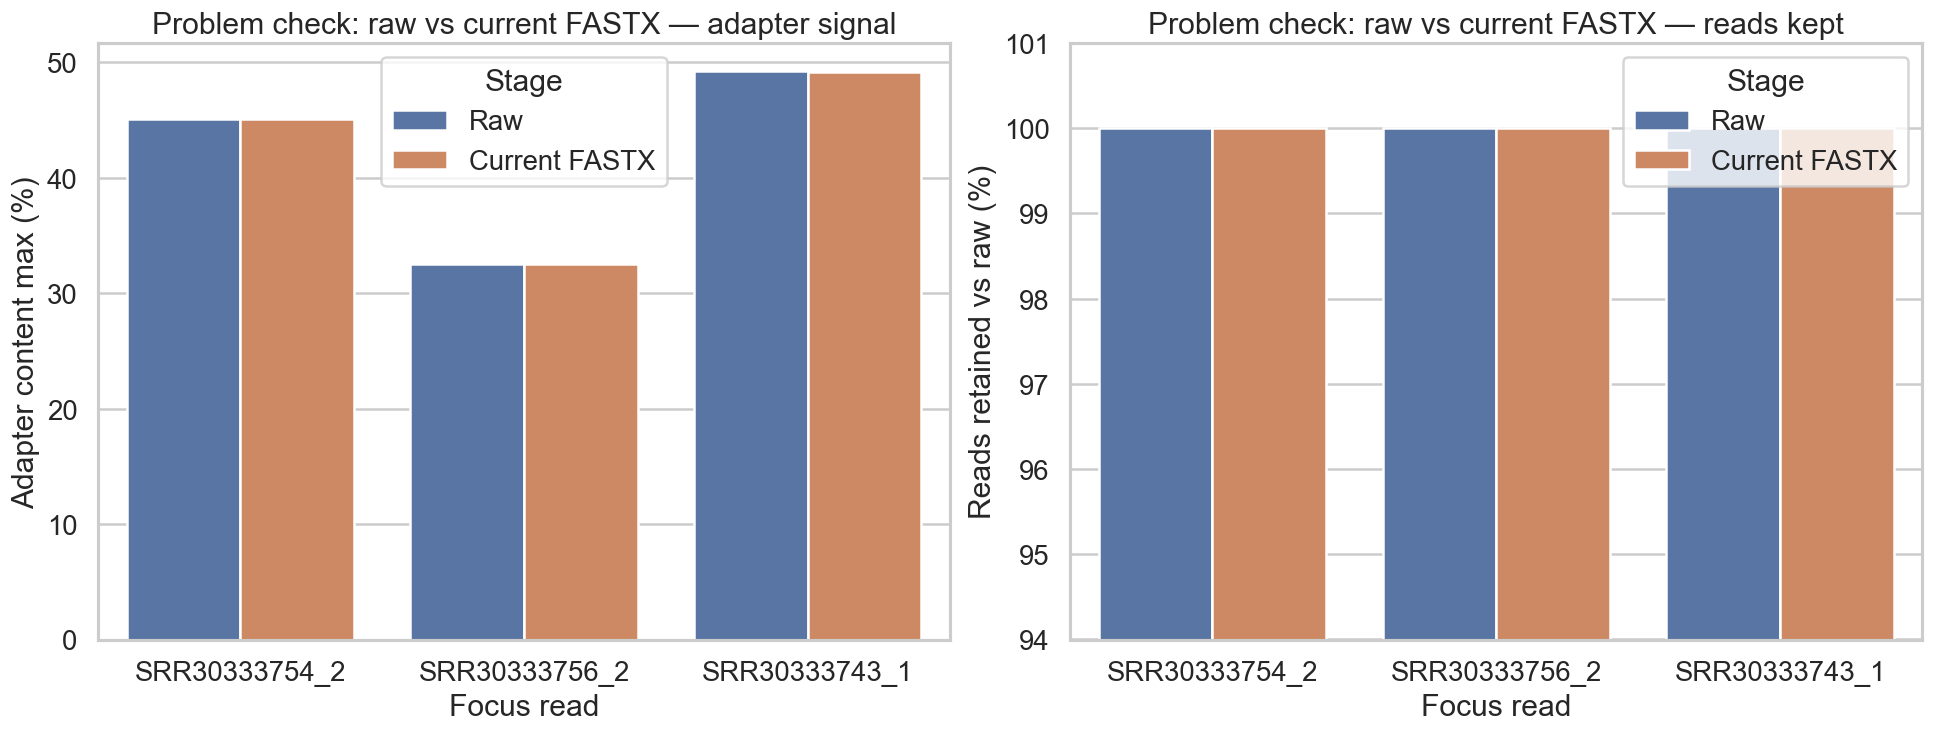

PosixPath('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/qc_analysis_remediation/final_problem_raw_vs_fastx.png')

In [3]:
plot_stage_compare(
    stages=["raw", "fastx"],
    title="Problem check: raw vs current FASTX",
    outfile="final_problem_raw_vs_fastx.png",
)


/var/folders/7y/f7_vwbw16slft31cvcc6xkk40000gn/T/ipykernel_71575/1435894605.py:1087: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


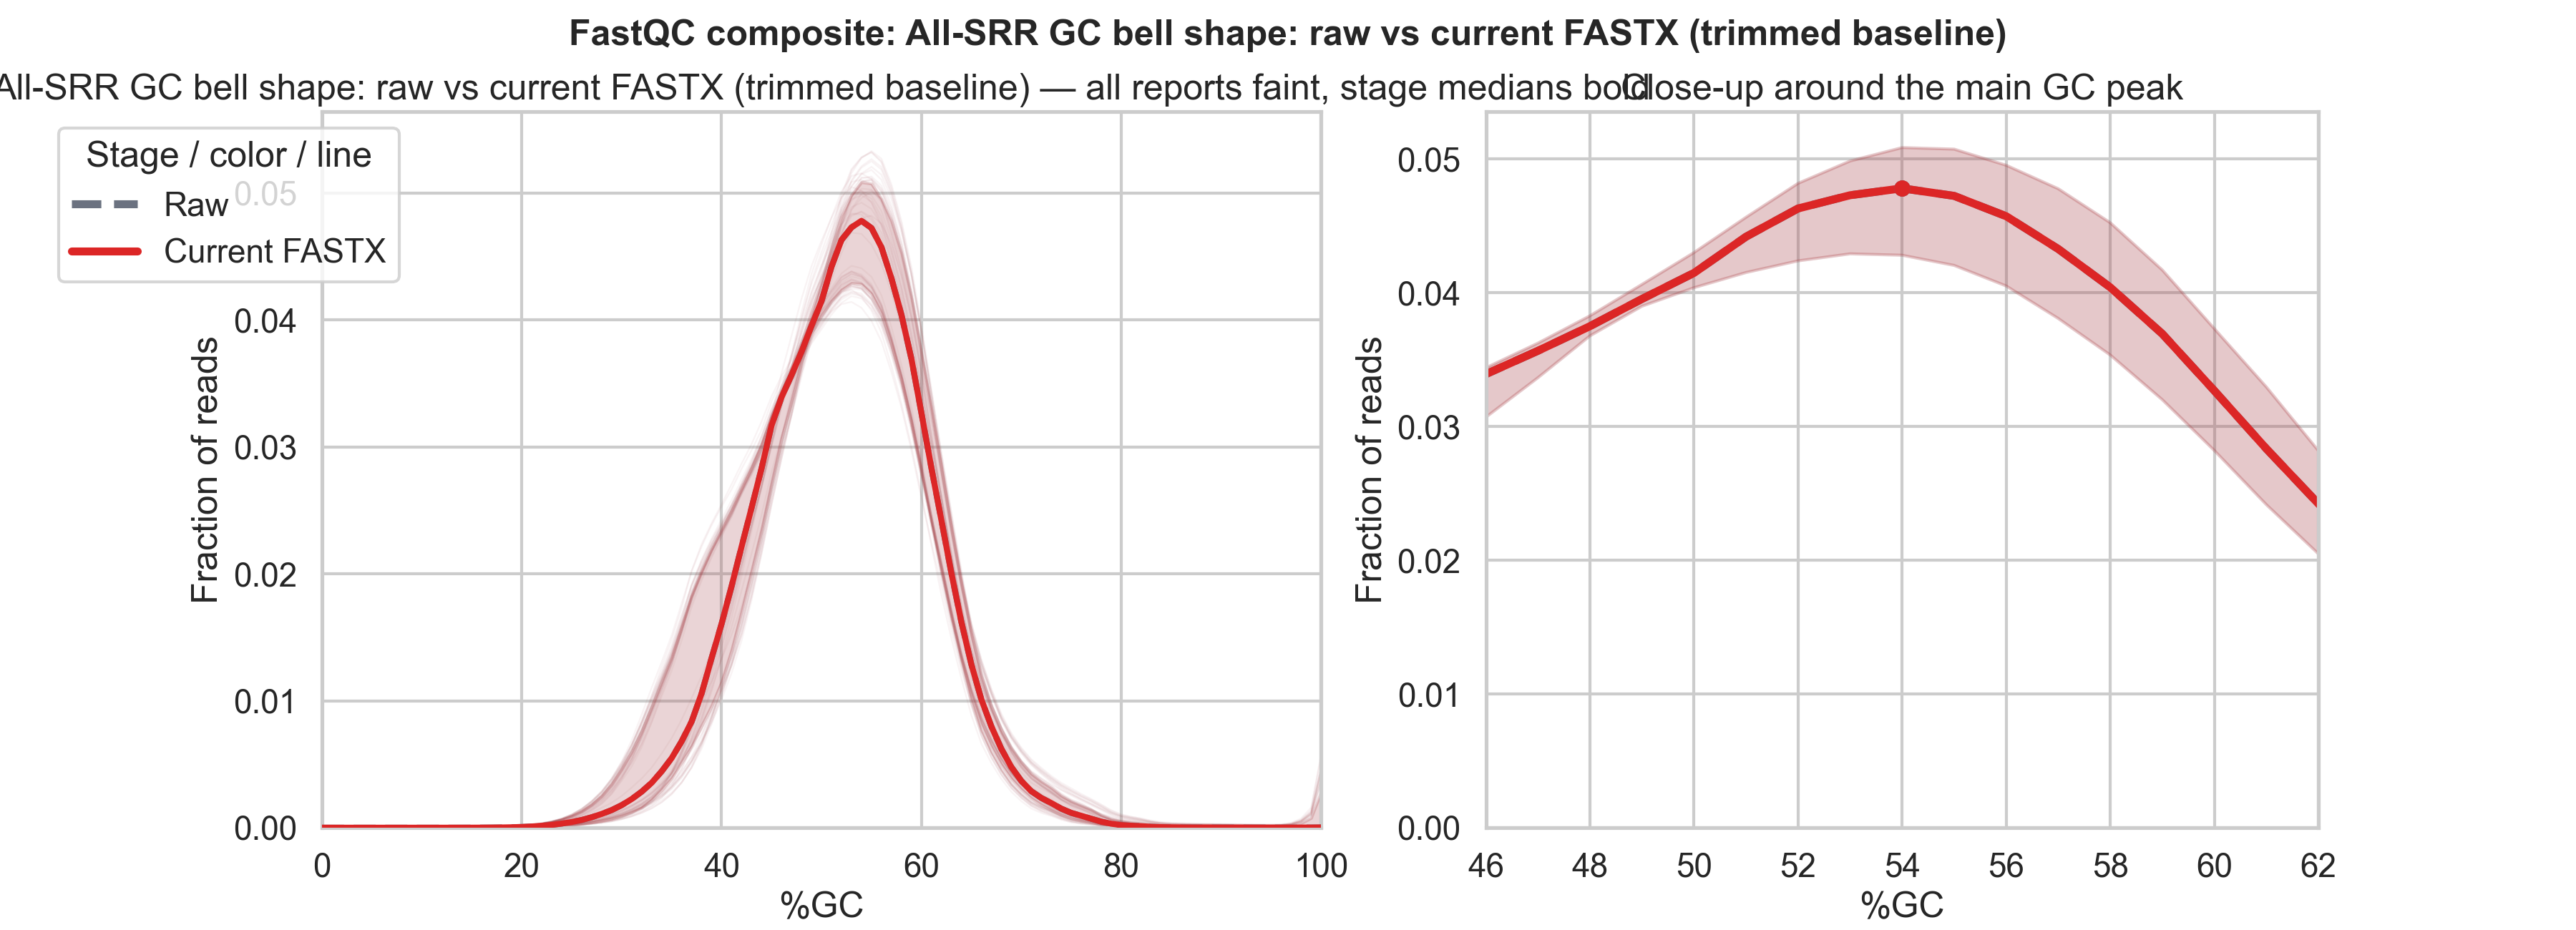

### Composite plot notes
- Left panel: all report-level GC curves are shown faintly, with each stage median overlaid in bold.
- Right panel: close-up of the same stage medians around the main GC peak for easier comparison.
- `Raw` (gray, dashed) peaks near `54%GC` with median height `0.0478`.
- `Current FASTX` (red, solid) peaks near `54%GC` with median height `0.0478`.

In [4]:
bell_path, bell_lines = save_composite_signal(
    stage_keys=["raw", "fastx"],
    title="All-SRR GC bell shape: raw vs current FASTX (trimmed baseline)",
    out_path=ANALYSIS_DIR / "final_baseline_raw_vs_fastx_gc_bellshape.png",
)
display(Image(filename=str(bell_path)))
display_findings(bell_lines)


In [5]:
lines = [
    "### How to read the bell plots",
    "- The shaded band is the **25th to 75th percentile** range at each `%GC` value, so it shows how much the reports vary within that stage.",
    "- The bold line is the **median** curve for that stage.",
    "- We use the **median** instead of the mean because it is less sensitive to a few unusual SRRs and gives a more stable stage summary.",
    "- In every later bell plot, `Current FASTX` is the **trimmed baseline**. That is the red solid line you compare against.",
    "- A bell plot does **not** choose the tool by itself. It is a dataset-level sanity check. The actual tool decision comes from the per-read remediation metrics (`adapter_max`, status changes, and retained reads).",
]

display_findings(lines)


### How to read the bell plots
- The shaded band is the **25th to 75th percentile** range at each `%GC` value, so it shows how much the reports vary within that stage.
- The bold line is the **median** curve for that stage.
- We use the **median** instead of the mean because it is less sensitive to a few unusual SRRs and gives a more stable stage summary.
- In every later bell plot, `Current FASTX` is the **trimmed baseline**. That is the red solid line you compare against.
- A bell plot does **not** choose the tool by itself. It is a dataset-level sanity check. The actual tool decision comes from the per-read remediation metrics (`adapter_max`, status changes, and retained reads).

In [6]:
lines = [
    "### What Step 1 shows",
    "- `FASTX` clearly changed read length, so the trim did something real.",
    "- But the main technical signal stayed almost unchanged after `FASTX`.",
]

for row in wide.itertuples():
    lines.append(
        f"- `{row.focus_read}`: adapter_max only moved from `{row.raw_adapter_max:.4f}` to "
        f"`{row.fastx_adapter_max:.4f}`, while the dominant signal stayed `{row.fastx_dominant_signal_label}`."
    )

lines.extend(
    [
        "- Interpretation: the first trim shortened reads, but it did **not** solve the adapter/poly-G problem.",
        "- That is why we tested new tools instead of doing more of the same trim.",
    ]
)

display_findings(lines)


### What Step 1 shows
- `FASTX` clearly changed read length, so the trim did something real.
- But the main technical signal stayed almost unchanged after `FASTX`.
- `SRR30333754_2`: adapter_max only moved from `45.1251` to `45.0897`, while the dominant signal stayed `poly-G artifact`.
- `SRR30333756_2`: adapter_max only moved from `32.5277` to `32.4893`, while the dominant signal stayed `poly-G artifact`.
- `SRR30333743_1`: adapter_max only moved from `49.2101` to `49.1768`, while the dominant signal stayed `TruSeq adapter`.
- Interpretation: the first trim shortened reads, but it did **not** solve the adapter/poly-G problem.
- That is why we tested new tools instead of doing more of the same trim.

## Step 2. What solutions are we comparing?

This section names the tools and the purpose of each one, so the later plots have a clear reason to exist.


In [7]:
tool_table = pd.DataFrame(
    [
        {
            "Tool": "Current FASTX",
            "Role in this notebook": "Current baseline after the first QC-driven trim",
            "What it mainly does": "Quality-tail trimming and length shortening",
            "What success would look like": "Lower adapter signal than raw",
        },
        {
            "Tool": "fastp",
            "Role in this notebook": "Main remediation candidate",
            "What it mainly does": "Paired-end adapter detection + poly-G cleanup + quality trimming",
            "What success would look like": "Much lower adapter signal than FASTX without excessive read loss",
        },
        {
            "Tool": "cutadapt",
            "Role in this notebook": "Targeted explicit-sequence comparison",
            "What it mainly does": "Sequence-directed trimming + NextSeq/NovaSeq style trimming",
            "What success would look like": "Signal reduction comparable to or better than fastp",
        },
    ]
)

display(tool_table)


,Tool,Role in this notebook,What it mainly does,What success would look like
0,Current FASTX,Current baseline after the first QC-driven trim,Quality-tail trimming and length shortening,Lower adapter signal than raw
1,fastp,Main remediation candidate,Paired-end adapter detection + poly-G cleanup ...,Much lower adapter signal than FASTX without e...
2,cutadapt,Targeted explicit-sequence comparison,Sequence-directed trimming + NextSeq/NovaSeq s...,Signal reduction comparable to or better than ...


## Step 3. What did `fastp` do to the data?

This is the first real remediation test.

The question here is:
**Is `fastp` better than the current `FASTX`-trimmed baseline, and by how much?**


In [8]:
fastp_table = wide[
    [
        "srr",
        "focus_read",
        "issue_type",
        "raw_adapter_max",
        "fastx_adapter_max",
        "fastp_adapter_max",
        "fastp_retained_pct",
        "raw_dominant_signal_label",
        "fastx_dominant_signal_label",
        "fastp_dominant_signal_label",
        "raw_sequence_length",
        "fastx_sequence_length",
        "fastp_sequence_length",
    ]
].copy()

fastp_table = fastp_table.rename(
    columns={
        "srr": "SRR",
        "focus_read": "Focus read",
        "issue_type": "Problem",
        "raw_adapter_max": "Raw adapter_max",
        "fastx_adapter_max": "FASTX adapter_max",
        "fastp_adapter_max": "fastp adapter_max",
        "fastp_retained_pct": "fastp retained %",
        "raw_dominant_signal_label": "Raw signal",
        "fastx_dominant_signal_label": "FASTX signal",
        "fastp_dominant_signal_label": "fastp signal",
        "raw_sequence_length": "Raw length",
        "fastx_sequence_length": "FASTX length",
        "fastp_sequence_length": "fastp length",
    }
)

display(fastp_table.round(4))


,SRR,Focus read,Problem,Raw adapter_max,FASTX adapter_max,fastp adapter_max,fastp retained %,Raw signal,FASTX signal,fastp signal,Raw length,FASTX length,fastp length
0,SRR30333754,SRR30333754_2,poly-G dominated read 2,45.1251,45.0897,0.0589,95.5758,poly-G artifact,poly-G artifact,not detected,151,75-151,30-151
1,SRR30333756,SRR30333756_2,poly-G dominated read 2,32.5277,32.4893,0.0434,95.7836,poly-G artifact,poly-G artifact,not detected,151,84-151,30-151
2,SRR30333743,SRR30333743_1,explicit TruSeq adapter in read 1,49.2101,49.1768,0.0054,96.7674,TruSeq adapter,TruSeq adapter,not detected,151,118-151,30-151


/var/folders/7y/f7_vwbw16slft31cvcc6xkk40000gn/T/ipykernel_71575/1435894605.py:124: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  subset["stage"] = pd.Categorical(subset["stage"], categories=stages, ordered=True)


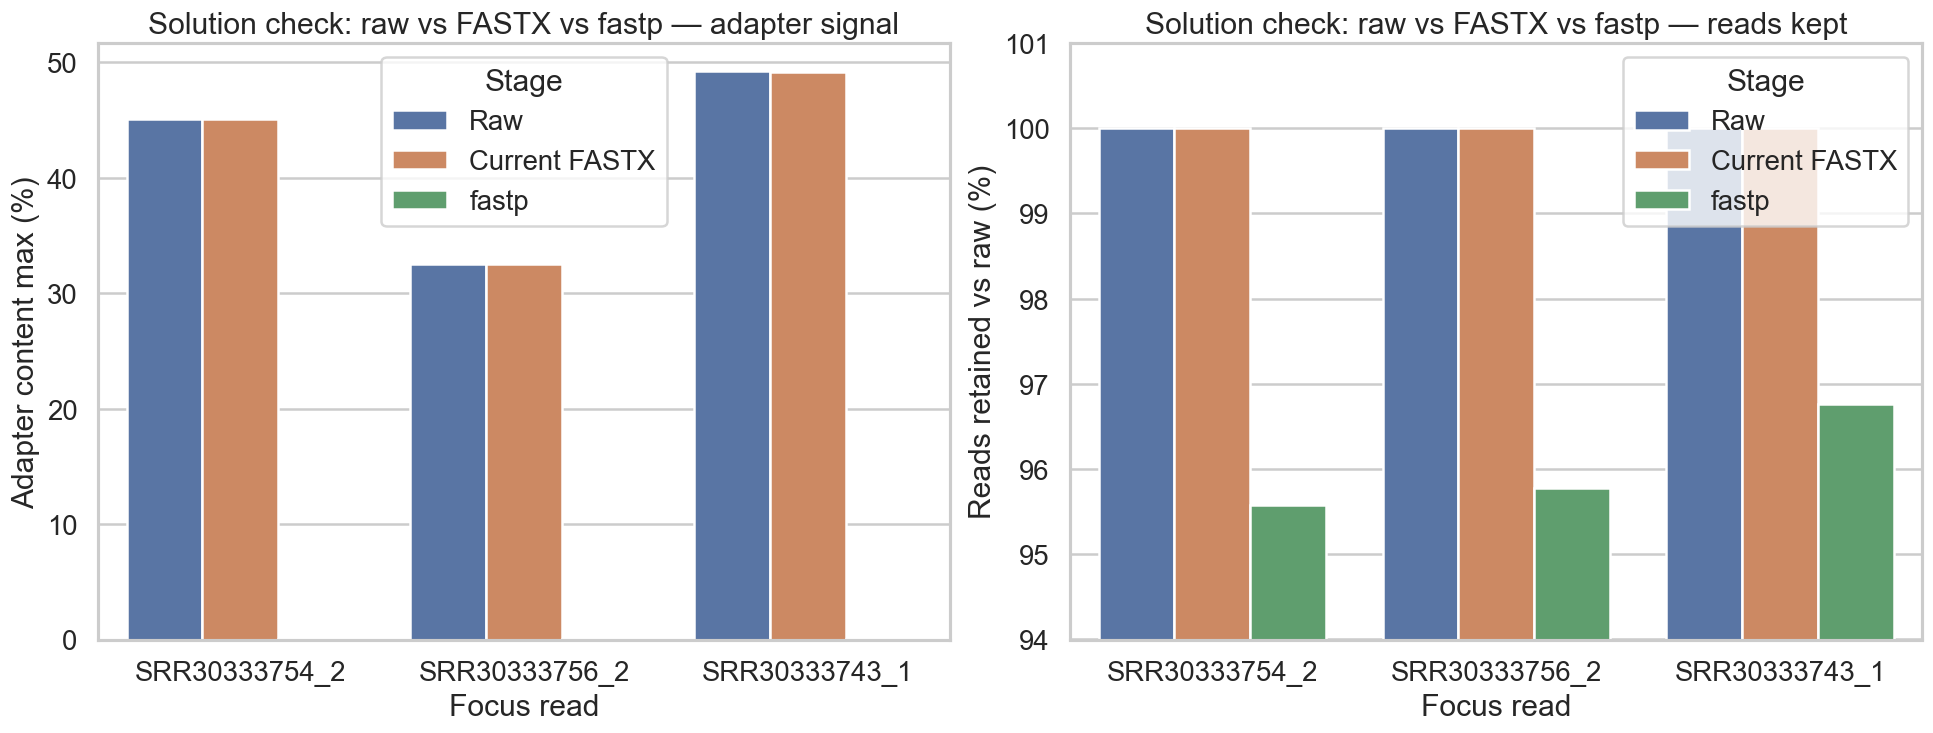

PosixPath('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/qc_analysis_remediation/final_fastp_vs_baseline.png')

In [9]:
plot_stage_compare(
    stages=["raw", "fastx", "fastp"],
    title="Solution check: raw vs FASTX vs fastp",
    outfile="final_fastp_vs_baseline.png",
)


/var/folders/7y/f7_vwbw16slft31cvcc6xkk40000gn/T/ipykernel_71575/1435894605.py:1087: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


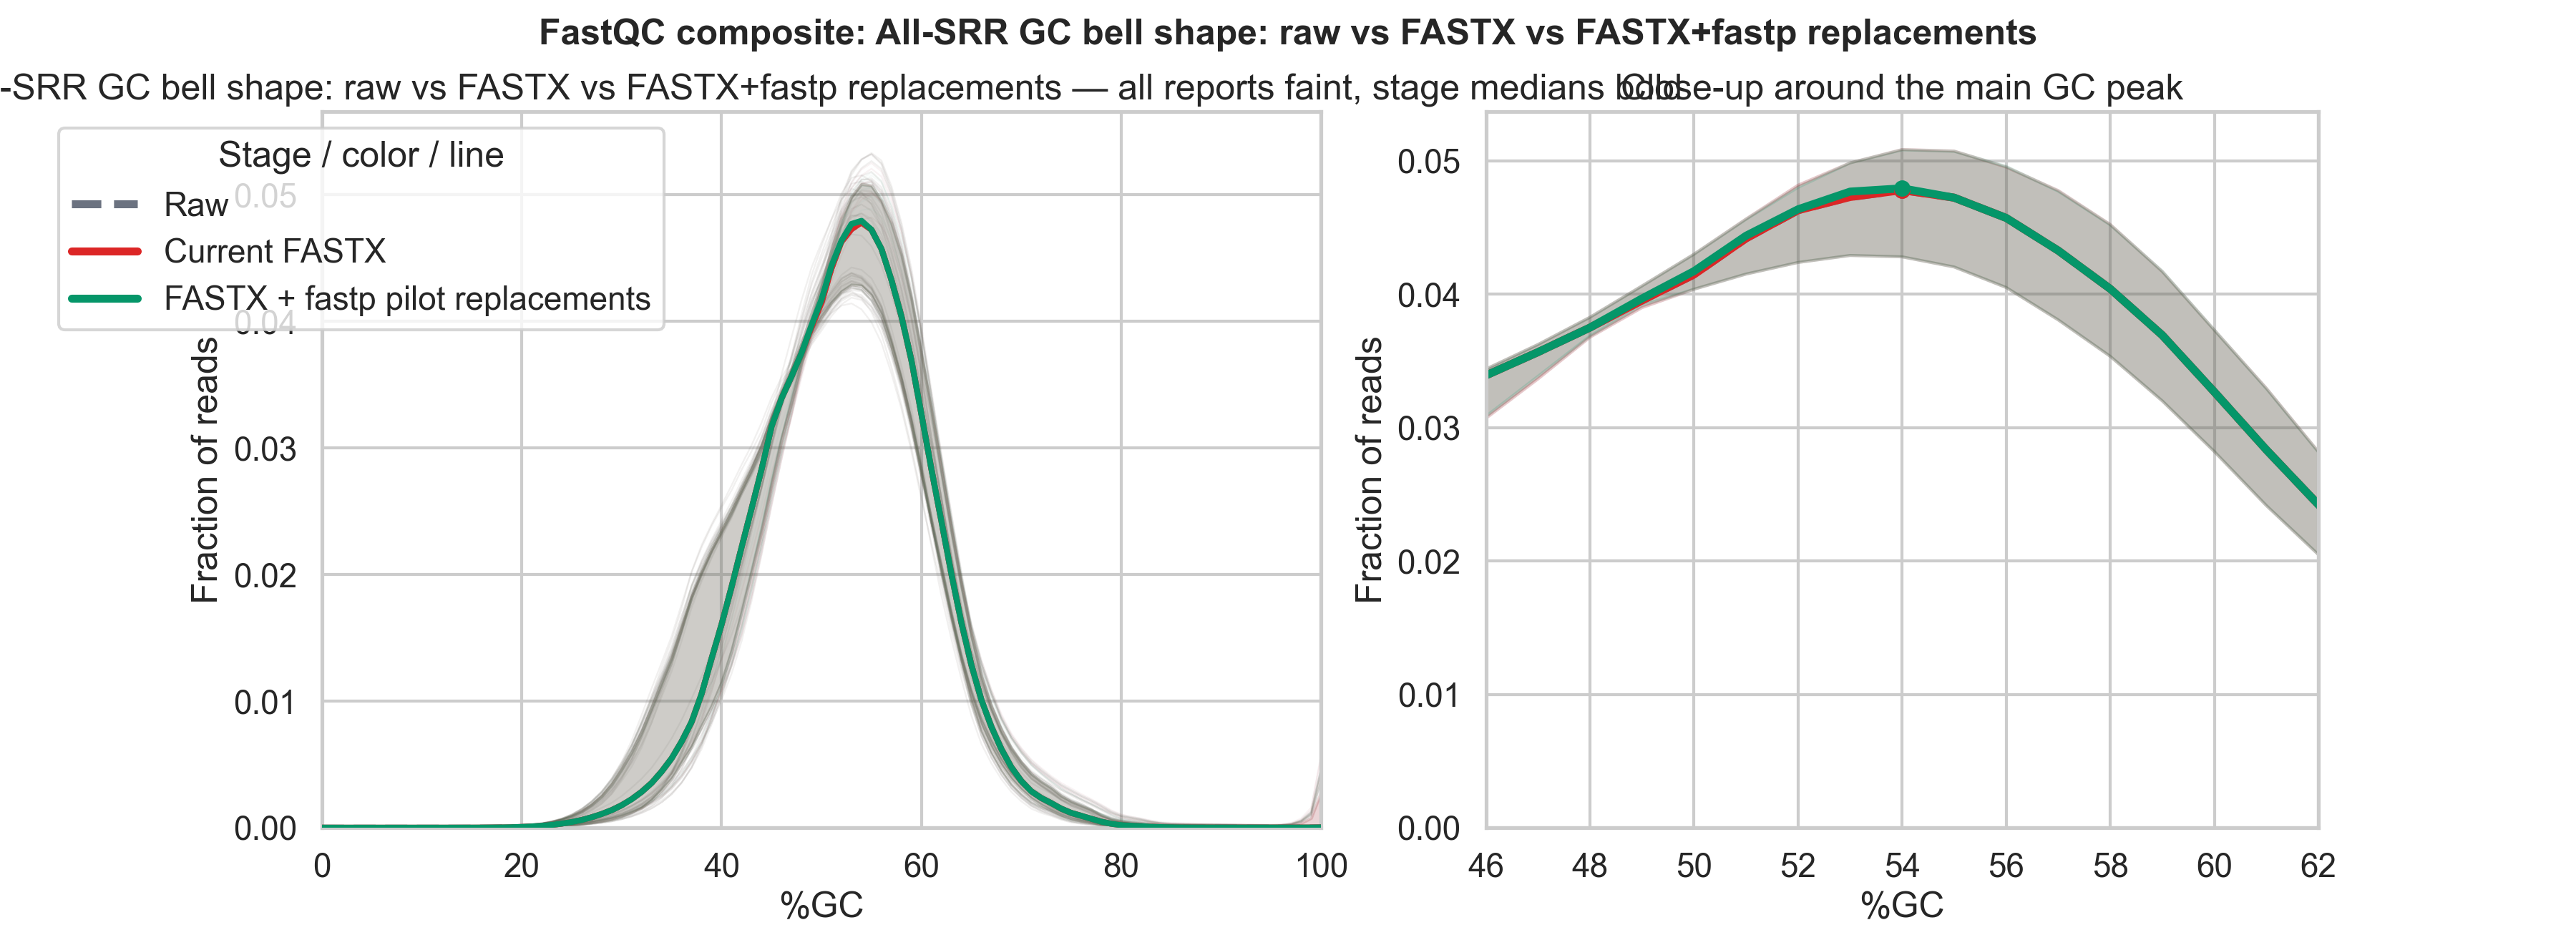

### Composite plot notes
- Left panel: all report-level GC curves are shown faintly, with each stage median overlaid in bold.
- Right panel: close-up of the same stage medians around the main GC peak for easier comparison.
- `Raw` (gray, dashed) peaks near `54%GC` with median height `0.0478`.
- `Current FASTX` (red, solid) peaks near `54%GC` with median height `0.0478`.
- `FASTX + fastp pilot replacements` (green, solid) peaks near `54%GC` with median height `0.0479`.

In [10]:
bell_path, bell_lines = save_composite_signal(
    stage_keys=["raw", "fastx", "fastp_mix"],
    title="All-SRR GC bell shape: raw vs FASTX vs FASTX+fastp replacements",
    out_path=ANALYSIS_DIR / "final_fastp_gc_bellshape_all_srrs.png",
)
display(Image(filename=str(bell_path)))
display_findings(bell_lines)


In [11]:
lines = [
    "### What Step 3 shows",
    "- `fastp` is the first tool that clearly changes the actual problem, not just the read length.",
    "- In the bell plot above, the red solid line is the current FASTX-trimmed baseline and the green line is `FASTX + fastp` pilot replacements.",
    "- The all-SRR GC bell-shape plot answers the dataset-level question: what happens if we replace the pilot SRRs with their `fastp` versions and leave the other SRRs at the current FASTX baseline?",
]

for row in wide.itertuples():
    lines.append(
        f"- `{row.focus_read}`: adapter_max dropped from `{row.fastx_adapter_max:.4f}` after FASTX "
        f"to `{row.fastp_adapter_max:.4f}` after `fastp`, while reads retained were `{row.fastp_retained_pct:.4f}%`."
    )

lines.extend(
    [
        "- For all three focus reads, the dominant technical signal becomes `not detected` after `fastp`.",
        "- Interpretation: `fastp` does what we wanted the remediation step to do.",
    ]
)

display_findings(lines)


### What Step 3 shows
- `fastp` is the first tool that clearly changes the actual problem, not just the read length.
- In the bell plot above, the red solid line is the current FASTX-trimmed baseline and the green line is `FASTX + fastp` pilot replacements.
- The all-SRR GC bell-shape plot answers the dataset-level question: what happens if we replace the pilot SRRs with their `fastp` versions and leave the other SRRs at the current FASTX baseline?
- `SRR30333754_2`: adapter_max dropped from `45.0897` after FASTX to `0.0589` after `fastp`, while reads retained were `95.5758%`.
- `SRR30333756_2`: adapter_max dropped from `32.4893` after FASTX to `0.0434` after `fastp`, while reads retained were `95.7836%`.
- `SRR30333743_1`: adapter_max dropped from `49.1768` after FASTX to `0.0054` after `fastp`, while reads retained were `96.7674%`.
- For all three focus reads, the dominant technical signal becomes `not detected` after `fastp`.
- Interpretation: `fastp` does what we wanted the remediation step to do.

## Step 4. What did `cutadapt` do to the data?

This section asks the same question for `cutadapt`:
**Is it better than the current `FASTX` baseline, and is it better than `fastp`?**


In [12]:
cutadapt_table = wide[
    [
        "srr",
        "focus_read",
        "issue_type",
        "raw_adapter_max",
        "fastx_adapter_max",
        "cutadapt_adapter_max",
        "cutadapt_retained_pct",
        "raw_dominant_signal_label",
        "fastx_dominant_signal_label",
        "cutadapt_dominant_signal_label",
        "raw_sequence_length",
        "fastx_sequence_length",
        "cutadapt_sequence_length",
    ]
].copy()

cutadapt_table = cutadapt_table.rename(
    columns={
        "srr": "SRR",
        "focus_read": "Focus read",
        "issue_type": "Problem",
        "raw_adapter_max": "Raw adapter_max",
        "fastx_adapter_max": "FASTX adapter_max",
        "cutadapt_adapter_max": "cutadapt adapter_max",
        "cutadapt_retained_pct": "cutadapt retained %",
        "raw_dominant_signal_label": "Raw signal",
        "fastx_dominant_signal_label": "FASTX signal",
        "cutadapt_dominant_signal_label": "cutadapt signal",
        "raw_sequence_length": "Raw length",
        "fastx_sequence_length": "FASTX length",
        "cutadapt_sequence_length": "cutadapt length",
    }
)

display(cutadapt_table.round(4))


,SRR,Focus read,Problem,Raw adapter_max,FASTX adapter_max,cutadapt adapter_max,cutadapt retained %,Raw signal,FASTX signal,cutadapt signal,Raw length,FASTX length,cutadapt length
0,SRR30333754,SRR30333754_2,poly-G dominated read 2,45.1251,45.0897,45.0601,97.5,poly-G artifact,poly-G artifact,not detected,151,75-151,30-151
1,SRR30333756,SRR30333756_2,poly-G dominated read 2,32.5277,32.4893,31.8831,97.7,poly-G artifact,poly-G artifact,not detected,151,84-151,30-151
2,SRR30333743,SRR30333743_1,explicit TruSeq adapter in read 1,49.2101,49.1768,0.0338,98.2,TruSeq adapter,TruSeq adapter,not detected,151,118-151,30-151


/var/folders/7y/f7_vwbw16slft31cvcc6xkk40000gn/T/ipykernel_71575/1435894605.py:124: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  subset["stage"] = pd.Categorical(subset["stage"], categories=stages, ordered=True)


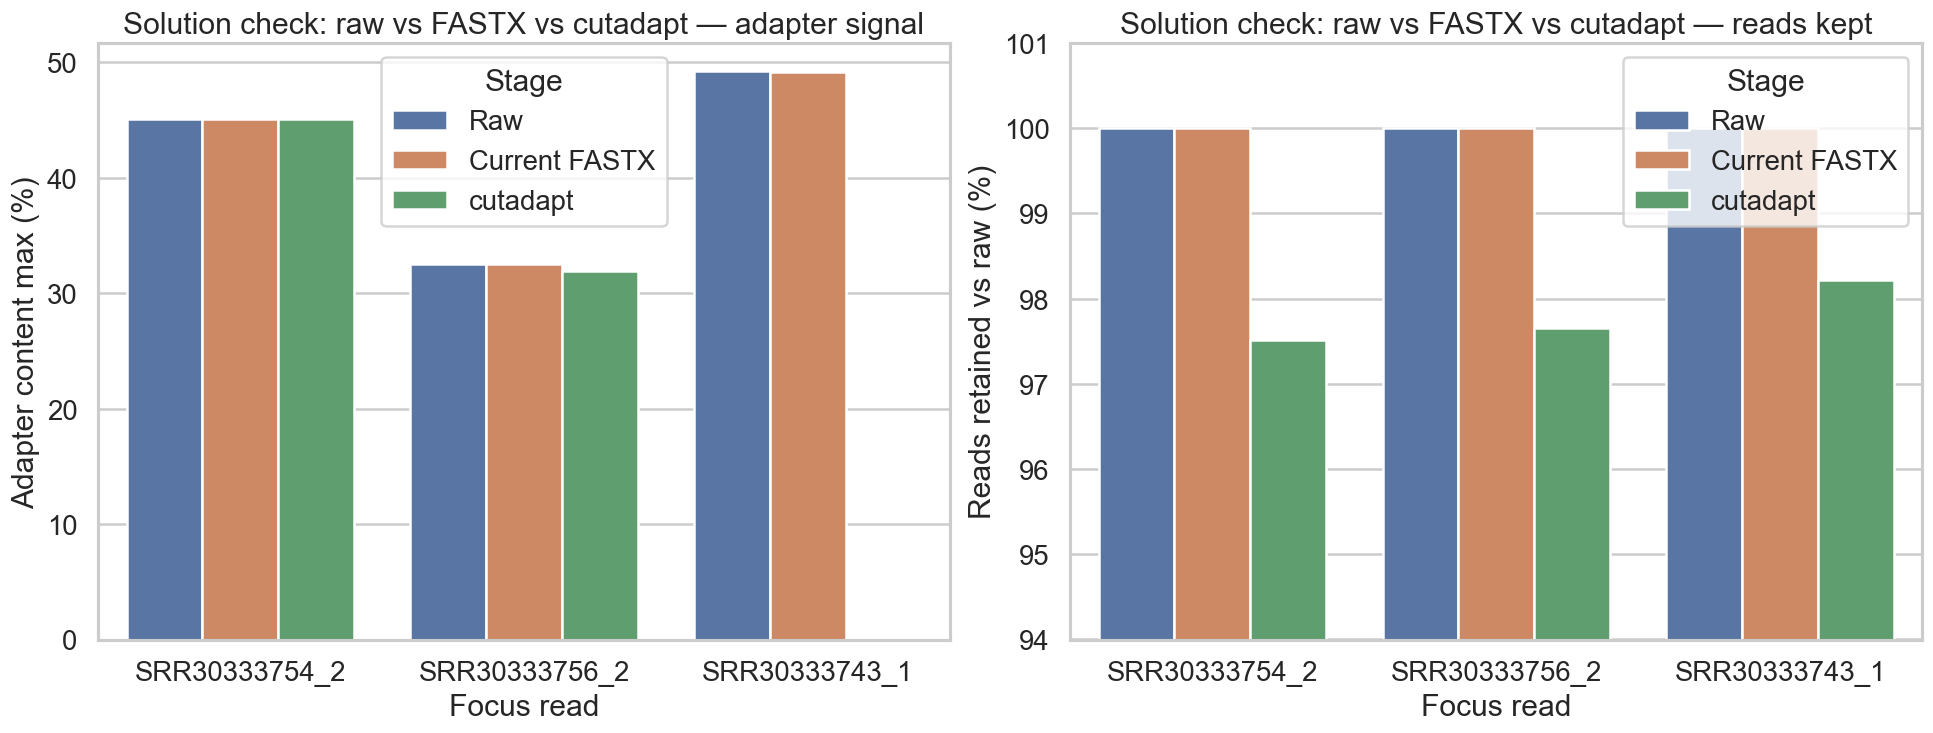

PosixPath('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/qc_analysis_remediation/final_cutadapt_vs_baseline.png')

In [13]:
plot_stage_compare(
    stages=["raw", "fastx", "cutadapt"],
    title="Solution check: raw vs FASTX vs cutadapt",
    outfile="final_cutadapt_vs_baseline.png",
)


/var/folders/7y/f7_vwbw16slft31cvcc6xkk40000gn/T/ipykernel_71575/1435894605.py:1087: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


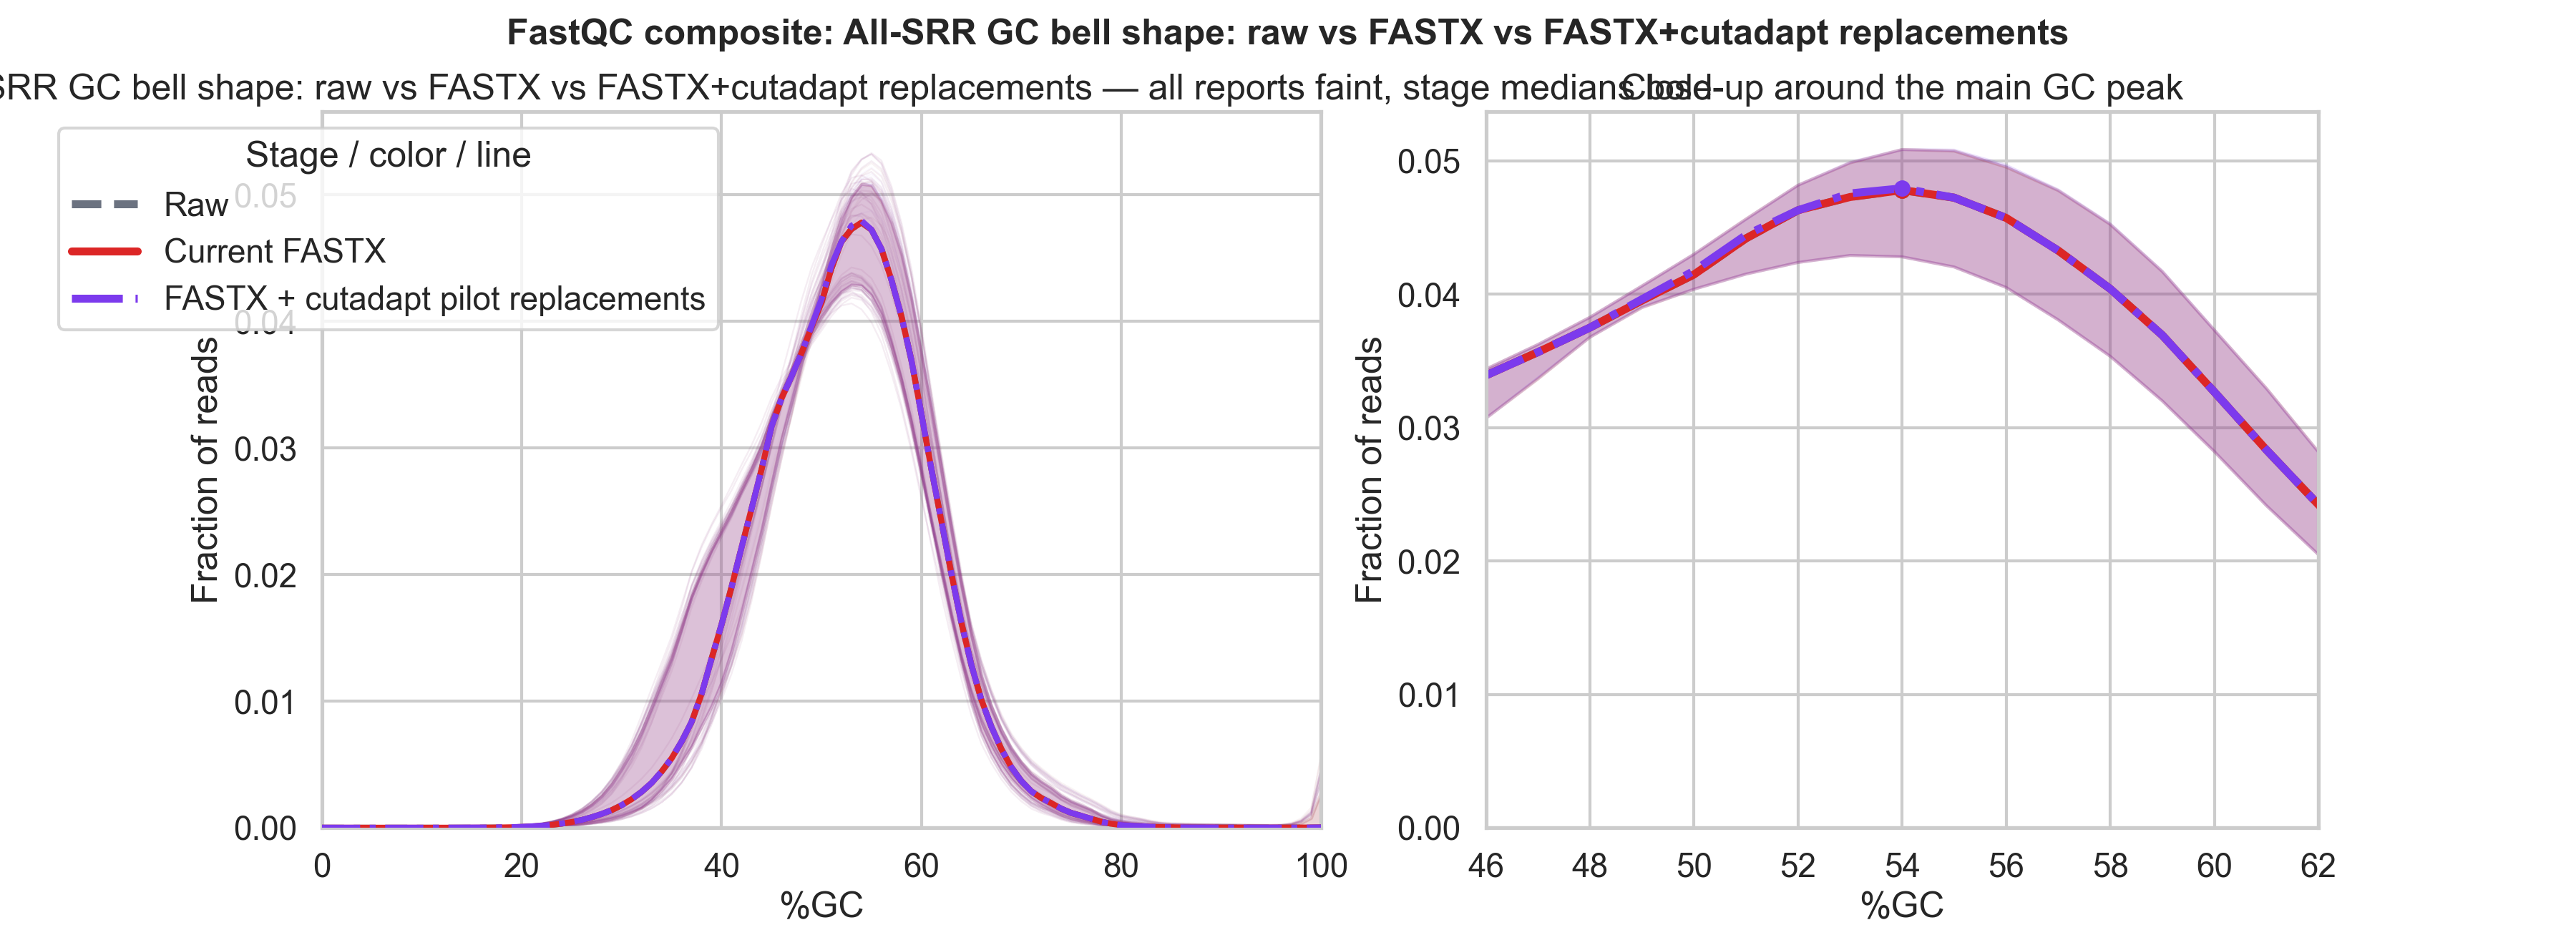

### Composite plot notes
- Left panel: all report-level GC curves are shown faintly, with each stage median overlaid in bold.
- Right panel: close-up of the same stage medians around the main GC peak for easier comparison.
- `Raw` (gray, dashed) peaks near `54%GC` with median height `0.0478`.
- `Current FASTX` (red, solid) peaks near `54%GC` with median height `0.0478`.
- `FASTX + cutadapt pilot replacements` (purple, dash-dot) peaks near `54%GC` with median height `0.0479`.

In [14]:
bell_path, bell_lines = save_composite_signal(
    stage_keys=["raw", "fastx", "cutadapt_mix"],
    title="All-SRR GC bell shape: raw vs FASTX vs FASTX+cutadapt replacements",
    out_path=ANALYSIS_DIR / "final_cutadapt_gc_bellshape_all_srrs.png",
)
display(Image(filename=str(bell_path)))
display_findings(bell_lines)


In [15]:
lines = [
    "### What Step 4 shows",
    "- `cutadapt` keeps slightly more reads than `fastp`, but the key question is whether it removes the technical signal well enough.",
    "- In the bell plot above, the red solid line is the current FASTX-trimmed baseline and the purple dash-dot line is `FASTX + cutadapt` pilot replacements.",
    "- The all-SRR GC bell-shape plot shows the dataset-level effect of replacing only the 3 pilot SRRs with their `cutadapt` versions.",
]

for row in wide.itertuples():
    lines.append(
        f"- `{row.focus_read}`: adapter_max moved from `{row.fastx_adapter_max:.4f}` after FASTX "
        f"to `{row.cutadapt_adapter_max:.4f}` after `cutadapt`, with `{row.cutadapt_retained_pct:.4f}%` reads retained."
    )

lines.extend(
    [
        "- `cutadapt` removes the dominant overrepresented-sequence call, but in the two poly-G cases the adapter_max stays very high.",
        "- Interpretation: `cutadapt` helps, but it does not solve the poly-G dominated cases nearly as well as `fastp`.",
    ]
)

display_findings(lines)


### What Step 4 shows
- `cutadapt` keeps slightly more reads than `fastp`, but the key question is whether it removes the technical signal well enough.
- In the bell plot above, the red solid line is the current FASTX-trimmed baseline and the purple dash-dot line is `FASTX + cutadapt` pilot replacements.
- The all-SRR GC bell-shape plot shows the dataset-level effect of replacing only the 3 pilot SRRs with their `cutadapt` versions.
- `SRR30333754_2`: adapter_max moved from `45.0897` after FASTX to `45.0601` after `cutadapt`, with `97.5000%` reads retained.
- `SRR30333756_2`: adapter_max moved from `32.4893` after FASTX to `31.8831` after `cutadapt`, with `97.7000%` reads retained.
- `SRR30333743_1`: adapter_max moved from `49.1768` after FASTX to `0.0338` after `cutadapt`, with `98.2000%` reads retained.
- `cutadapt` removes the dominant overrepresented-sequence call, but in the two poly-G cases the adapter_max stays very high.
- Interpretation: `cutadapt` helps, but it does not solve the poly-G dominated cases nearly as well as `fastp`.

## Step 5. Put all solutions on the same page

This is the decision section.

The only question now is:
**When all stages are shown together, which tool is best against the current `FASTX` baseline?**


In [16]:
decision_table = wide[
    [
        "srr",
        "focus_read",
        "issue_type",
        "raw_adapter_max",
        "fastx_adapter_max",
        "fastp_adapter_max",
        "cutadapt_adapter_max",
        "fastp_retained_pct",
        "cutadapt_retained_pct",
    ]
].copy()

decision_table["best_tool"] = np.where(
    decision_table["fastp_adapter_max"] <= decision_table["cutadapt_adapter_max"],
    "fastp",
    "cutadapt",
)

decision_table = decision_table.rename(
    columns={
        "srr": "SRR",
        "focus_read": "Focus read",
        "issue_type": "Problem",
        "raw_adapter_max": "Raw",
        "fastx_adapter_max": "FASTX",
        "fastp_adapter_max": "fastp",
        "cutadapt_adapter_max": "cutadapt",
        "fastp_retained_pct": "fastp retained %",
        "cutadapt_retained_pct": "cutadapt retained %",
        "best_tool": "Best tool",
    }
)

display(decision_table.round(4))


,SRR,Focus read,Problem,Raw,FASTX,fastp,cutadapt,fastp retained %,cutadapt retained %,Best tool
0,SRR30333754,SRR30333754_2,poly-G dominated read 2,45.1251,45.0897,0.0589,45.0601,95.5758,97.5,fastp
1,SRR30333756,SRR30333756_2,poly-G dominated read 2,32.5277,32.4893,0.0434,31.8831,95.7836,97.7,fastp
2,SRR30333743,SRR30333743_1,explicit TruSeq adapter in read 1,49.2101,49.1768,0.0054,0.0338,96.7674,98.2,fastp


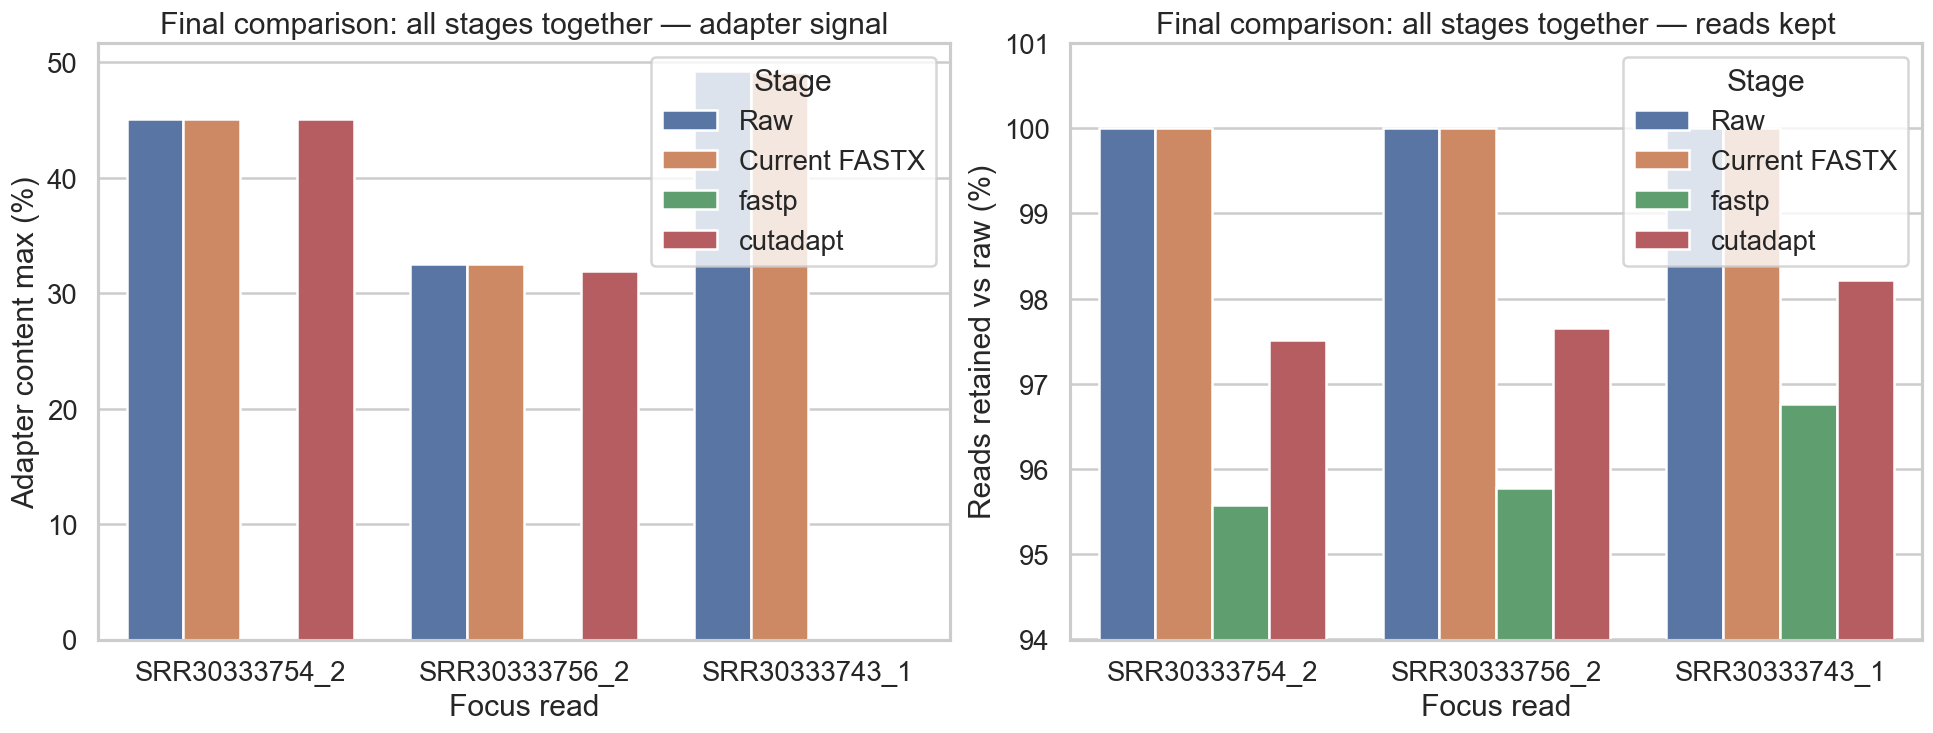

PosixPath('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/qc_analysis_remediation/final_all_tools_comparison.png')

In [17]:
plot_stage_compare(
    stages=["raw", "fastx", "fastp", "cutadapt"],
    title="Final comparison: all stages together",
    outfile="final_all_tools_comparison.png",
)


### Step 5A. Use the ranking plots that answer the decision question directly

The bar chart above is still useful as a quick stage overview, but it is **not** the strongest plot for the final choice.

Based on the official plotting docs we reviewed:
- point / slope-style comparisons are better than plain bars when the goal is direct category-to-category change
- heatmaps are the compact way to summarize status changes across many sample-stage combinations
- GC bell plots are best used as sanity checks, not as the primary ranking plot

So the next three figures are the ones that should drive the decision:
1. **delta vs `Current FASTX`** — did each tool improve the trimmed baseline?
2. **cleanup vs retention** — what was the tradeoff?
3. **status heatmap** — which FastQC module states actually changed?


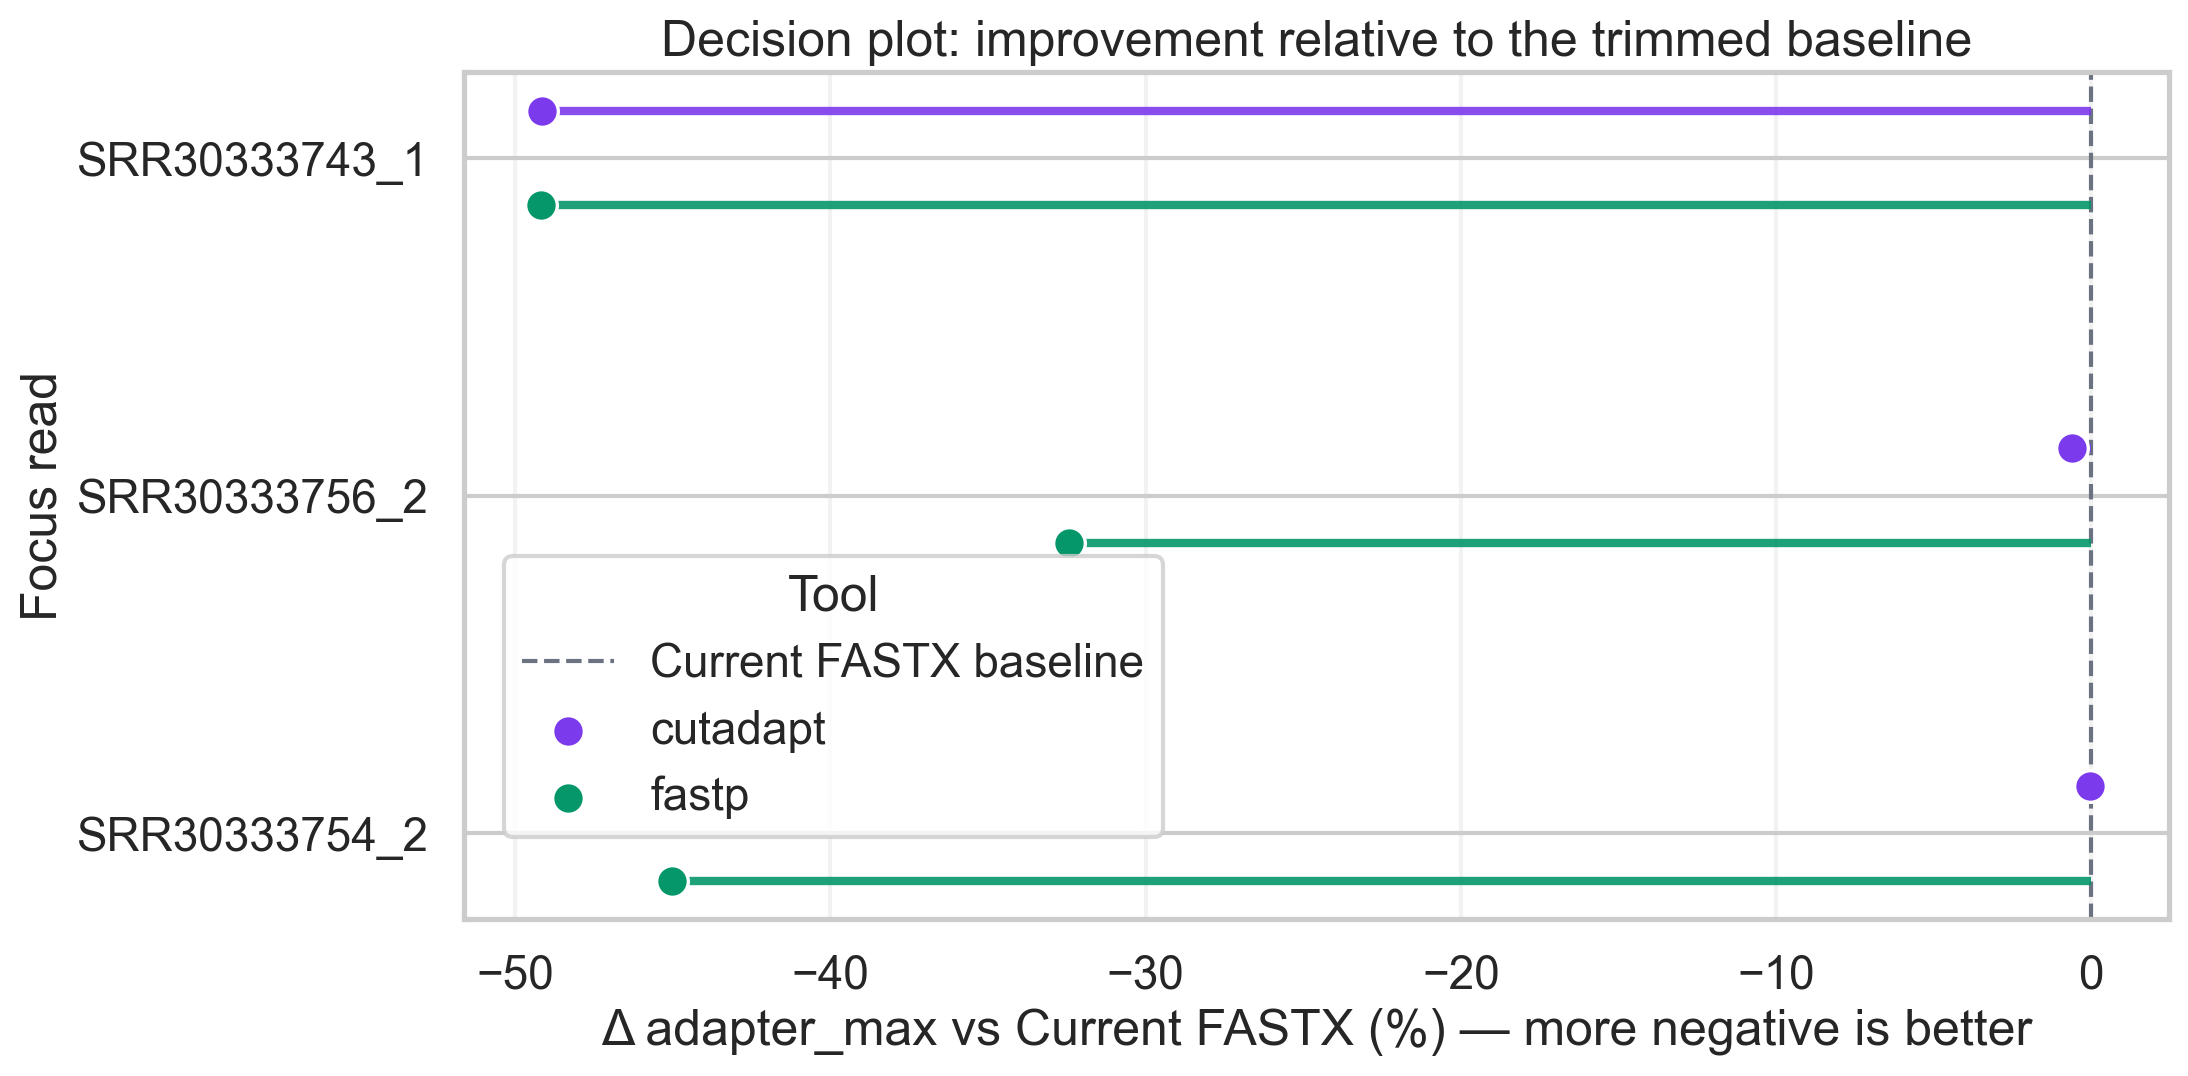

In [18]:
delta_plot_path = save_adapter_delta_plot(
    ANALYSIS_DIR / "final_adapter_delta_vs_fastx.png"
)
display(Image(filename=str(delta_plot_path)))


### Why this delta plot exists

- The vertical zero line is the `Current FASTX` baseline.
- Every point shows the change **relative to that baseline**.
- More negative is better because it means `adapter_max` dropped below the trimmed baseline.
- This is the clearest ranking plot for the main remediation metric.
- In this pilot, `fastp` sits much farther left than `cutadapt` for all three focus reads, so it is the stronger cleanup tool.


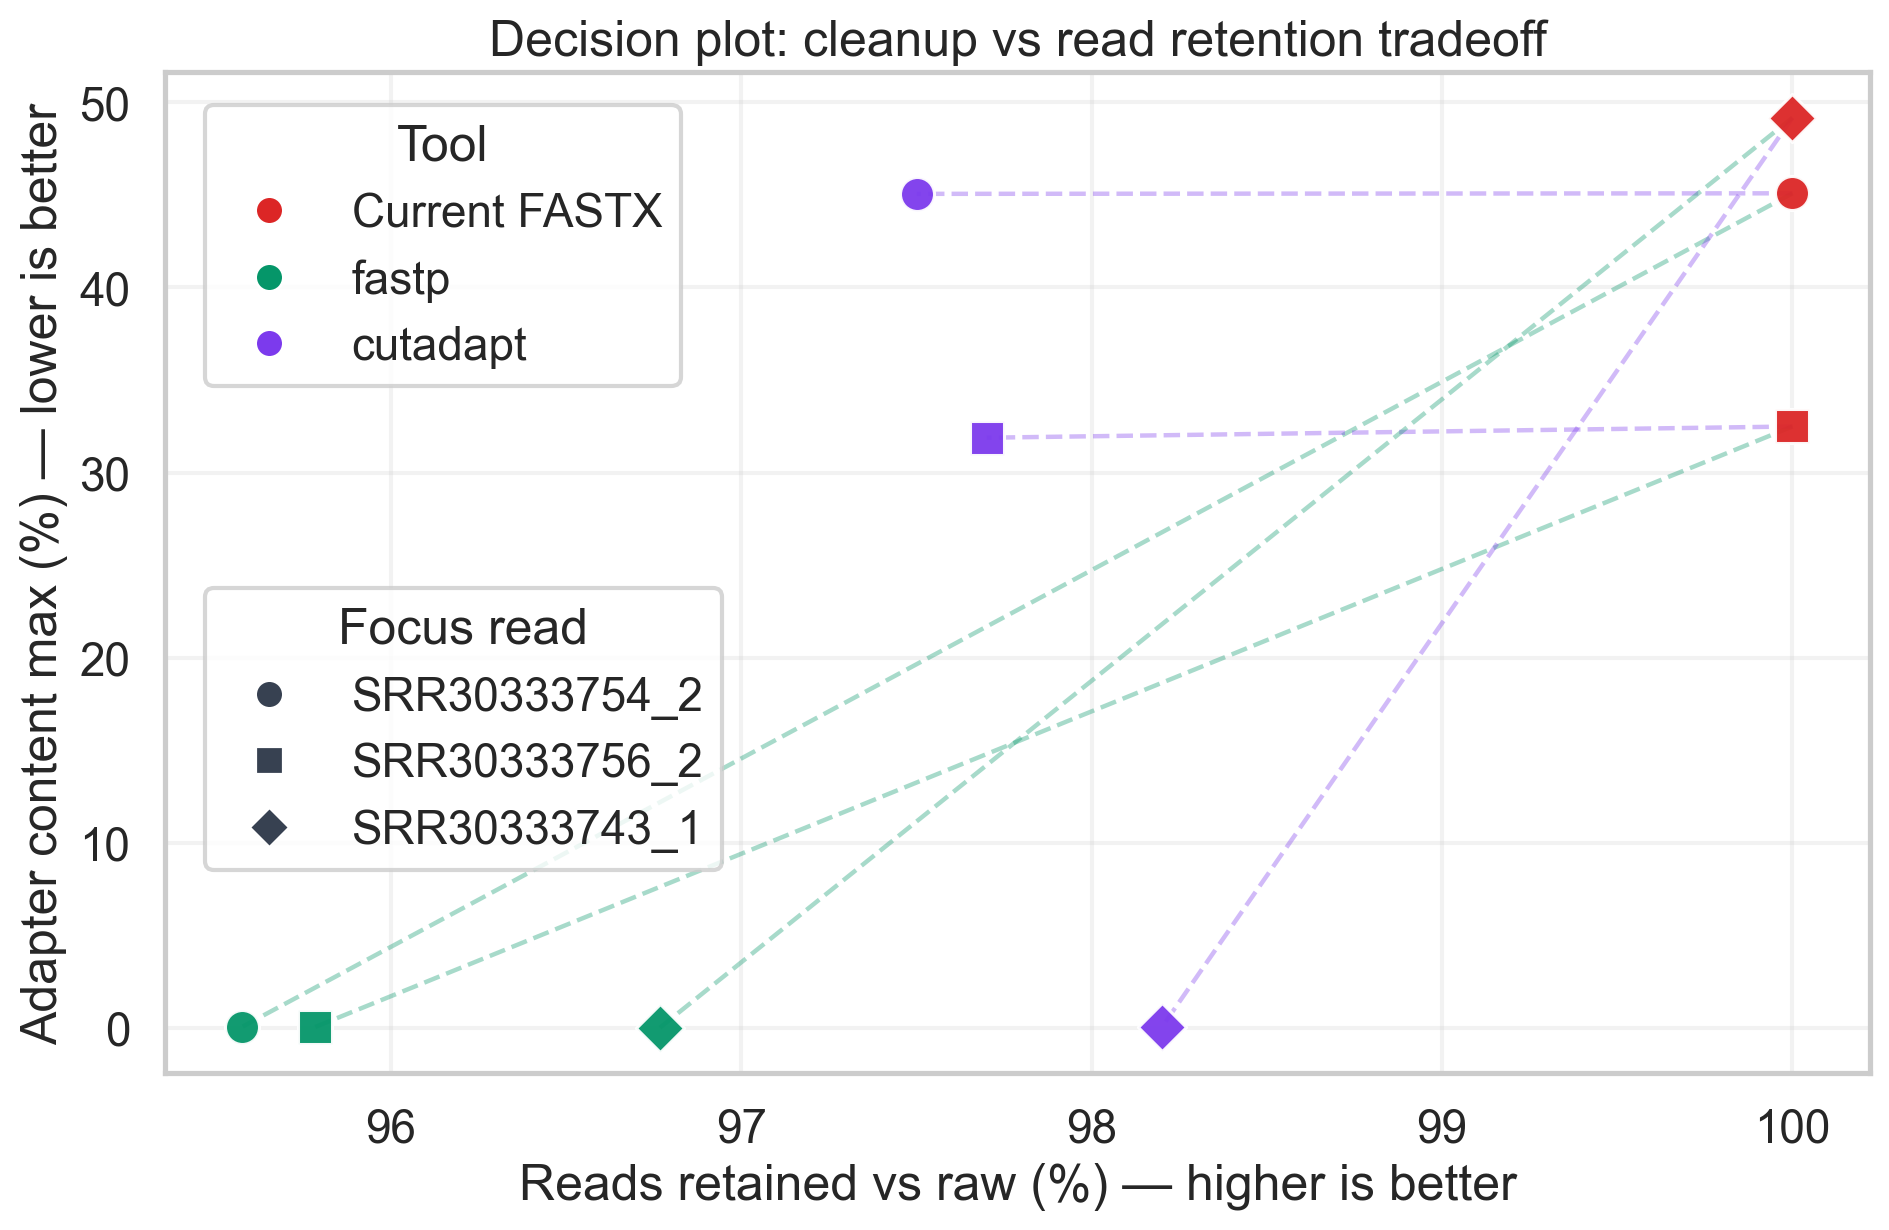

In [19]:
tradeoff_plot_path = save_retention_tradeoff_plot(
    ANALYSIS_DIR / "final_retention_vs_adapter_tradeoff.png"
)
display(Image(filename=str(tradeoff_plot_path)))


### Why this tradeoff plot exists

- This figure combines the two things we care about most: **keep reads** and **remove the technical signal**.
- Better points move **right** (more reads retained) and **down** (lower `adapter_max`).
- `cutadapt` stays slightly farther right, which means it keeps more reads.
- But `fastp` moves much farther down on the two poly-G reads, which is the larger scientific win here.
- This is why `fastp` still wins overall even though `cutadapt` has a small retention advantage.


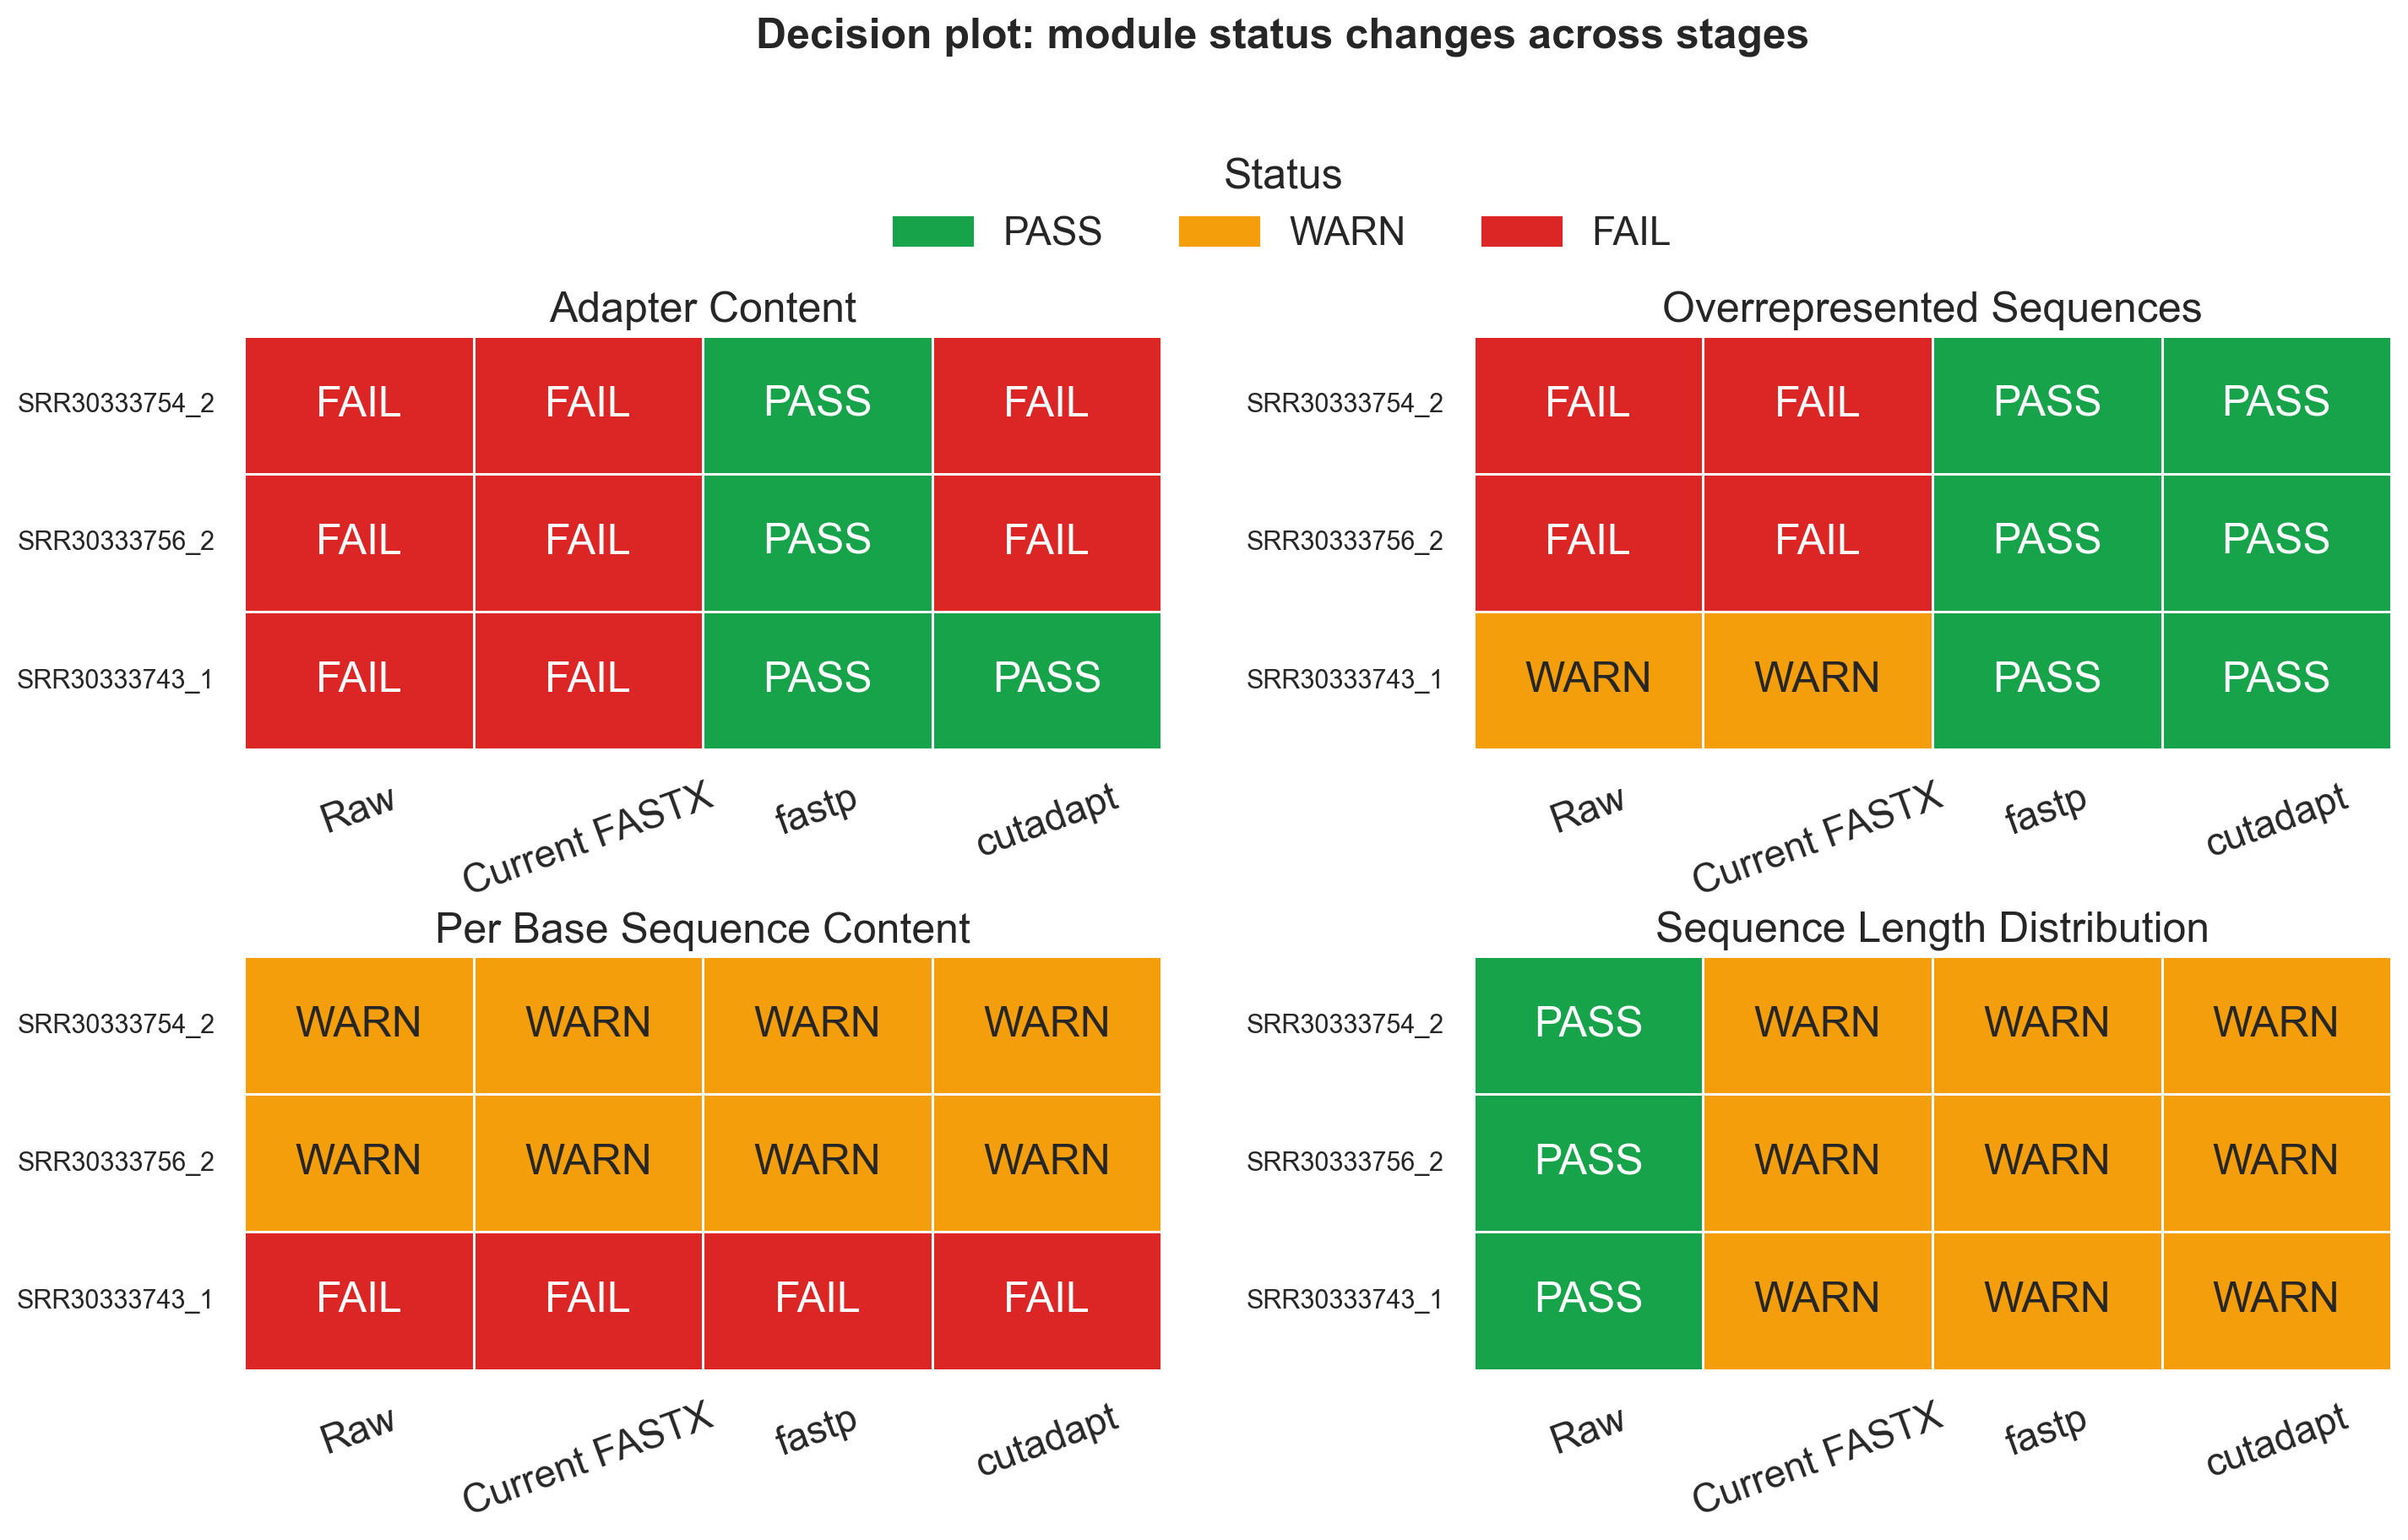

In [20]:
status_heatmap_path = save_status_heatmap(
    ANALYSIS_DIR / "final_status_heatmap_focus_reads.png"
)
display(Image(filename=str(status_heatmap_path)))


### Why this status heatmap exists

- A status table is correct, but it is slow to scan.
- The heatmap makes the `pass` / `warn` / `fail` transitions visible at a glance across reads, stages, and modules.
- `fastp` turns the `Adapter Content` module to `PASS` for all three focus reads.
- `cutadapt` fixes the explicit adapter case, but it leaves `Adapter Content` in `FAIL` for the two poly-G reads.
- This gives the categorical FastQC view that matches the numeric `adapter_max` comparison above.


### Step 5B. Use the bell plots as the final sanity check

Now that the decision plots are on the page, the bell plots play a simpler role:
they confirm that the dataset-level GC shape still looks reasonable after each remediation choice.

They are still useful, but they are **validation plots**, not ranking plots.


/var/folders/7y/f7_vwbw16slft31cvcc6xkk40000gn/T/ipykernel_71575/1435894605.py:1087: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


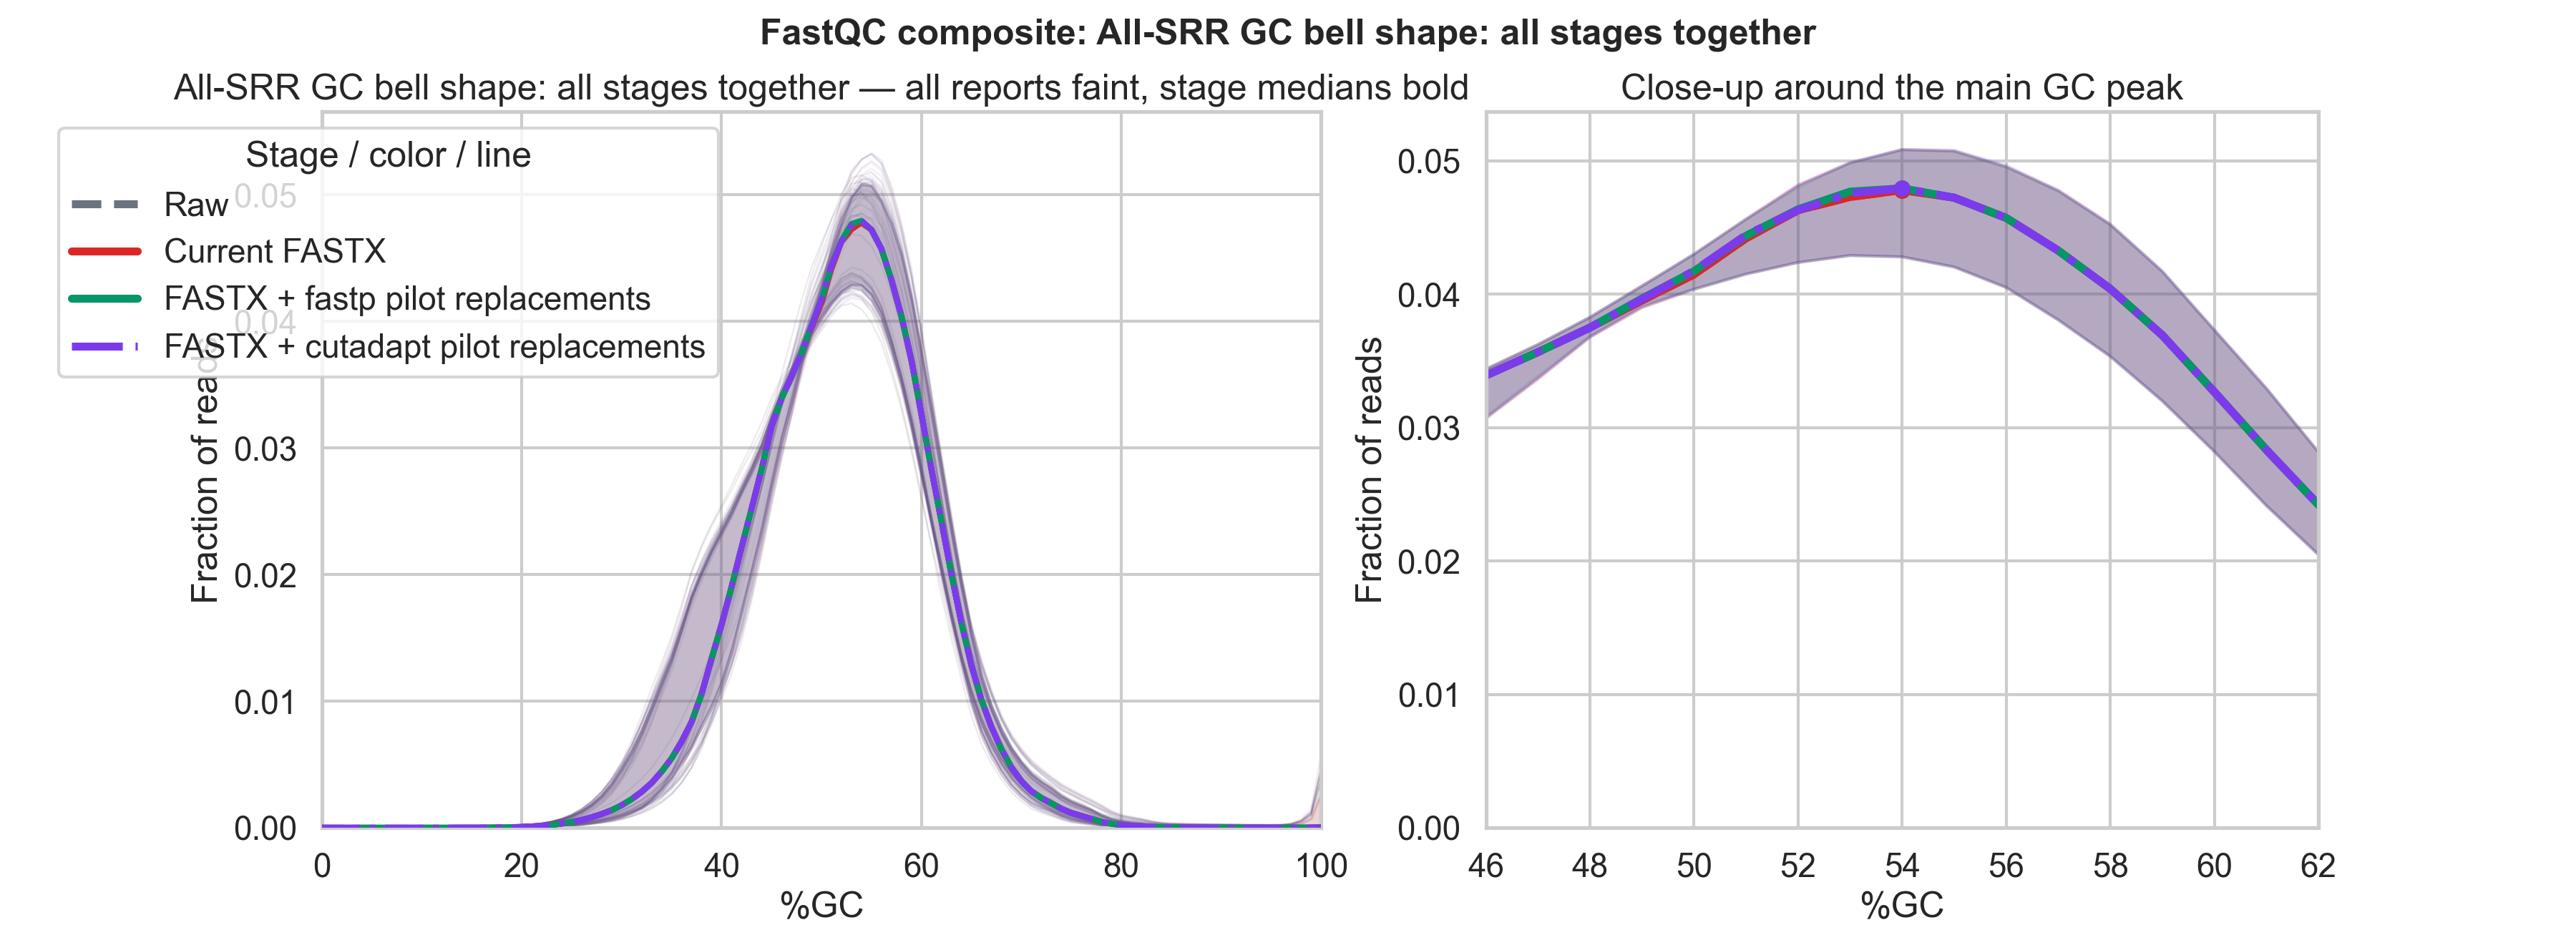

### Composite plot notes
- Left panel: all report-level GC curves are shown faintly, with each stage median overlaid in bold.
- Right panel: close-up of the same stage medians around the main GC peak for easier comparison.
- `Raw` (gray, dashed) peaks near `54%GC` with median height `0.0478`.
- `Current FASTX` (red, solid) peaks near `54%GC` with median height `0.0478`.
- `FASTX + fastp pilot replacements` (green, solid) peaks near `54%GC` with median height `0.0479`.
- `FASTX + cutadapt pilot replacements` (purple, dash-dot) peaks near `54%GC` with median height `0.0479`.

In [21]:
bell_path, bell_lines = save_composite_signal(
    stage_keys=["raw", "fastx", "fastp_mix", "cutadapt_mix"],
    title="All-SRR GC bell shape: all stages together",
    out_path=ANALYSIS_DIR / "final_all_tools_gc_bellshape_all_srrs.png",
)
display(Image(filename=str(bell_path)))
display_findings(bell_lines)


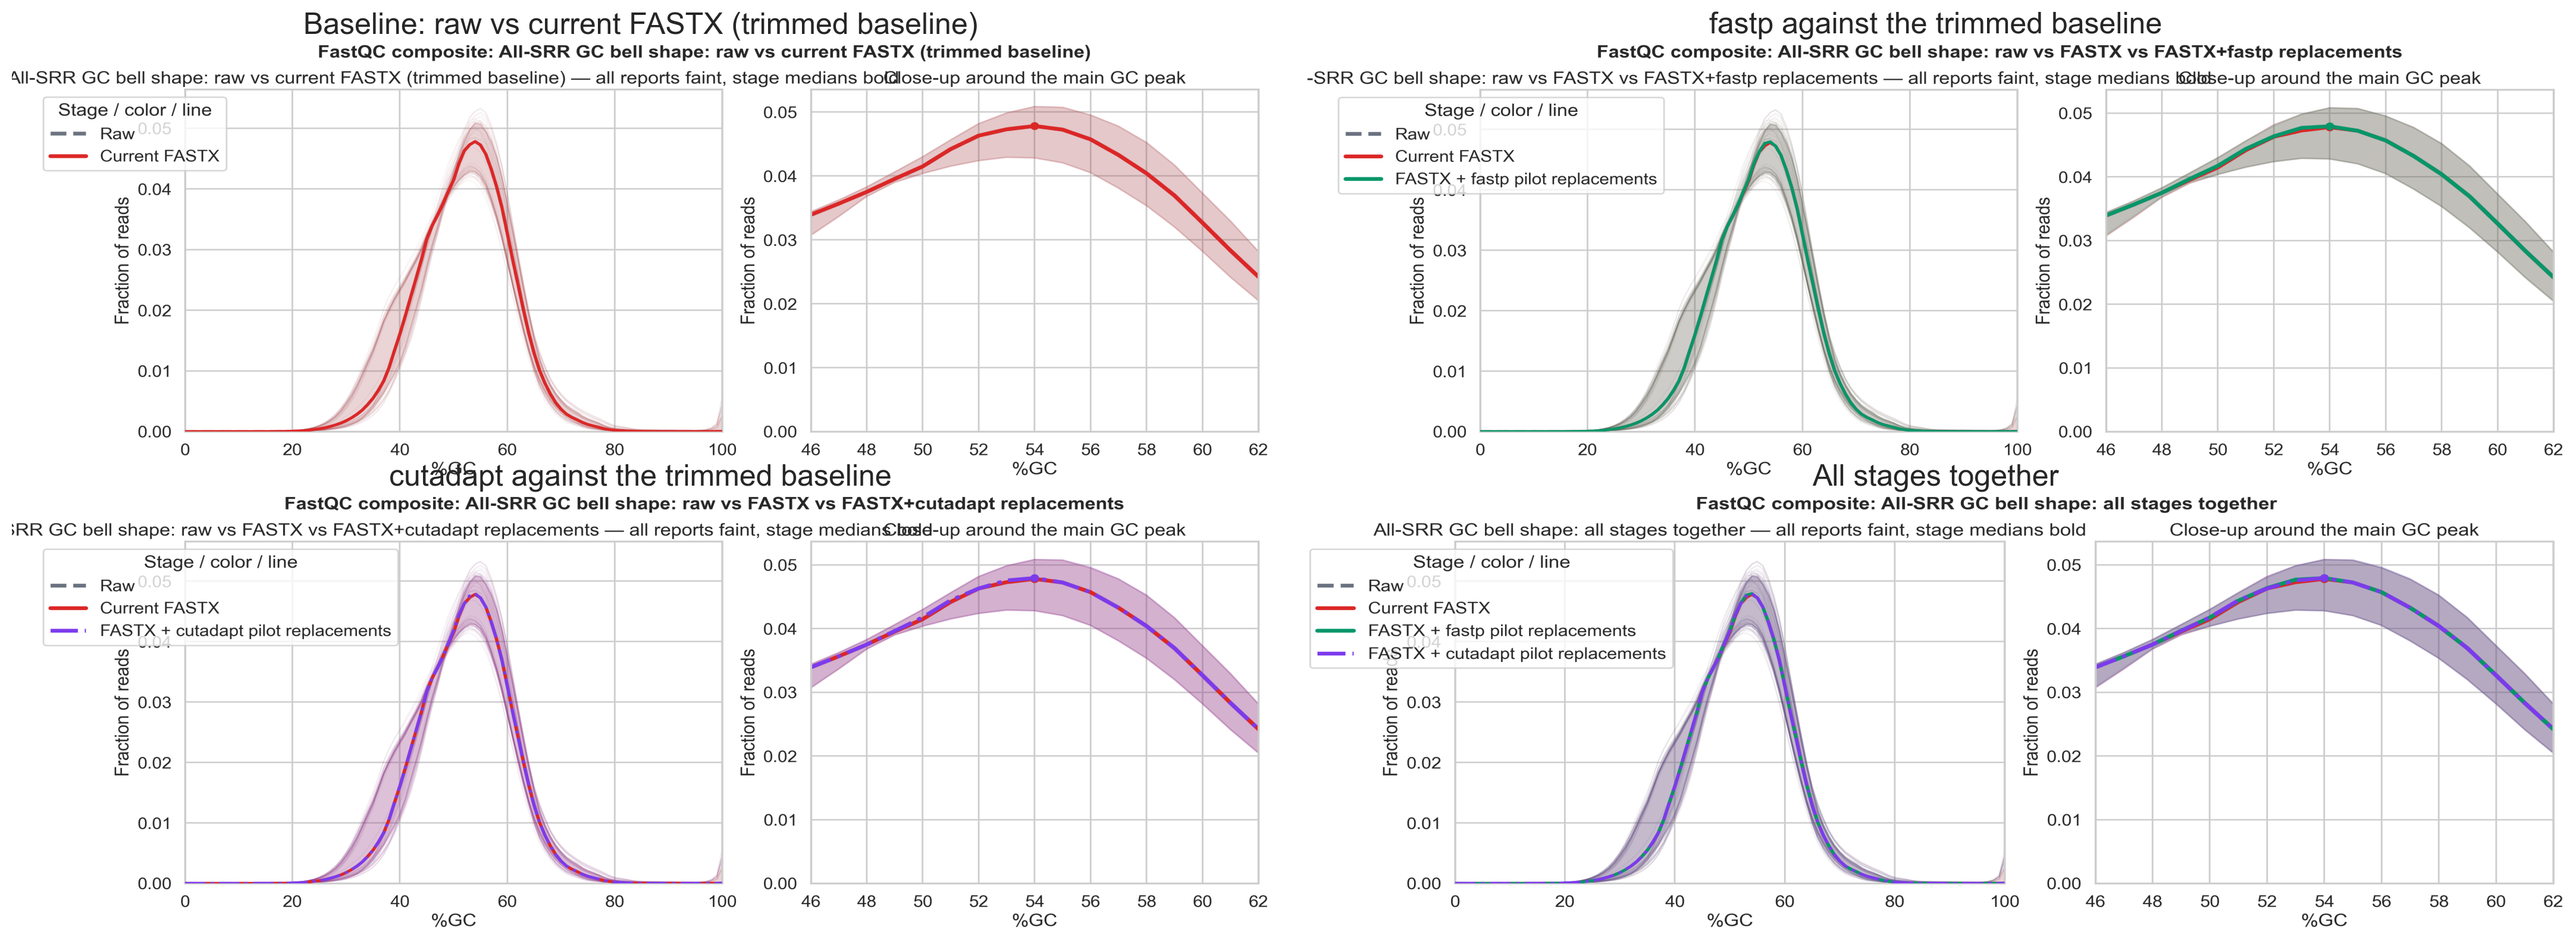

In [22]:
gallery_path = build_bell_gallery(
    image_specs=[
        ("Baseline: raw vs current FASTX (trimmed baseline)", ANALYSIS_DIR / "final_baseline_raw_vs_fastx_gc_bellshape.png"),
        ("fastp against the trimmed baseline", ANALYSIS_DIR / "final_fastp_gc_bellshape_all_srrs.png"),
        ("cutadapt against the trimmed baseline", ANALYSIS_DIR / "final_cutadapt_gc_bellshape_all_srrs.png"),
        ("All stages together", ANALYSIS_DIR / "final_all_tools_gc_bellshape_all_srrs.png"),
    ],
    out_path=ANALYSIS_DIR / "final_bell_gallery_2x2.png",
)
display(Image(filename=str(gallery_path)))


In [23]:
lines = [
    "### Bell-plot gallery: what is better and why",
    "- Read the gallery in this order: baseline first, then `fastp`, then `cutadapt`, then all stages together.",
    "- `Current FASTX` is the trimmed baseline in every comparison figure.",
    "- The bell plots tell us that the overall GC-shape stays reasonable after either remediation strategy.",
    "- That means the GC-shape check does **not** disqualify either tool.",
    "- If the bell plots feel too similar, that is expected: they are **sanity-check plots**, not the main ranking plot.",
    "- To decide the winner, use `final_adapter_delta_vs_fastx.png`, `final_retention_vs_adapter_tradeoff.png`, `final_status_heatmap_focus_reads.png`, and the remediation summary table, not the bell gallery alone.",
    "- The reason `fastp` still wins is the per-read remediation data: it removes the residual adapter/poly-G signal much more strongly than `cutadapt` in the two poly-G pilot reads while still keeping high read retention.",
    "- So the combined interpretation is: both tools preserve an acceptable dataset-level GC shape, but `fastp` solves the actual technical problem better.",
]

display_findings(lines)


### Bell-plot gallery: what is better and why
- Read the gallery in this order: baseline first, then `fastp`, then `cutadapt`, then all stages together.
- `Current FASTX` is the trimmed baseline in every comparison figure.
- The bell plots tell us that the overall GC-shape stays reasonable after either remediation strategy.
- That means the GC-shape check does **not** disqualify either tool.
- If the bell plots feel too similar, that is expected: they are **sanity-check plots**, not the main ranking plot.
- To decide the winner, use `final_adapter_delta_vs_fastx.png`, `final_retention_vs_adapter_tradeoff.png`, `final_status_heatmap_focus_reads.png`, and the remediation summary table, not the bell gallery alone.
- The reason `fastp` still wins is the per-read remediation data: it removes the residual adapter/poly-G signal much more strongly than `cutadapt` in the two poly-G pilot reads while still keeping high read retention.
- So the combined interpretation is: both tools preserve an acceptable dataset-level GC shape, but `fastp` solves the actual technical problem better.

### Step 5C. Bring in the full-dataset validation pass

The pilot is what we used to choose the tool.

But now that the full `fastp` rerun is done, we also have a **full-dataset**
`Current FASTX` vs `fastp` comparison.

This section does two things:
1. points to the full-dataset artifacts directly
2. shows a compact version of the full-dataset findings inside the notebook

That way, this notebook remains the complete QC story rather than only the pilot story.


In [24]:
full_compare_artifacts = pd.DataFrame(
    [
        {
            "Artifact": "Full FASTX vs fastp summary",
            "Path": str(FULL_COMPARE_DIR / "full_fastx_vs_fastp_summary.md"),
            "Why it matters": "Report-ready file-level findings for all 52 FastQC reports.",
        },
        {
            "Artifact": "Full FASTX vs fastp read metrics",
            "Path": str(FULL_COMPARE_DIR / "full_fastx_vs_fastp_read_metrics.csv"),
            "Why it matters": "Per-read metrics and status changes across the full dataset.",
        },
        {
            "Artifact": "Full FASTX vs fastp status counts",
            "Path": str(FULL_COMPARE_DIR / "full_fastx_vs_fastp_status_counts.csv"),
            "Why it matters": "Module-level pass/warn/fail counts before vs after full fastp cleanup.",
        },
        {
            "Artifact": "Supplementary FASTX MultiQC",
            "Path": str(ANALYSIS_DIR / "multiqc_fastx_baseline_server" / "report" / "mouse_fastx_baseline_all_srrs_multiqc.html"),
            "Why it matters": "Integrated baseline QC dashboard for the FASTX-trimmed stage.",
        },
        {
            "Artifact": "Supplementary FASTX vs fastp MultiQC",
            "Path": str(ANALYSIS_DIR / "multiqc_fastx_vs_fastp_server" / "report" / "mouse_fastx_vs_fastp_all_srrs_multiqc.html"),
            "Why it matters": "Integrated side-by-side QC dashboard for the full FASTX vs fastp comparison.",
        },
    ]
)

display(full_compare_artifacts)


,Artifact,Path,Why it matters
0,Full FASTX vs fastp summary,/Users/pitergarcia/DataScience/Semester5/BIOL5...,Report-ready file-level findings for all 52 Fa...
1,Full FASTX vs fastp read metrics,/Users/pitergarcia/DataScience/Semester5/BIOL5...,Per-read metrics and status changes across the...
2,Full FASTX vs fastp status counts,/Users/pitergarcia/DataScience/Semester5/BIOL5...,Module-level pass/warn/fail counts before vs a...
3,Supplementary FASTX MultiQC,/Users/pitergarcia/DataScience/Semester5/BIOL5...,Integrated baseline QC dashboard for the FASTX...
4,Supplementary FASTX vs fastp MultiQC,/Users/pitergarcia/DataScience/Semester5/BIOL5...,Integrated side-by-side QC dashboard for the f...


/var/folders/7y/f7_vwbw16slft31cvcc6xkk40000gn/T/ipykernel_71575/1435894605.py:410: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


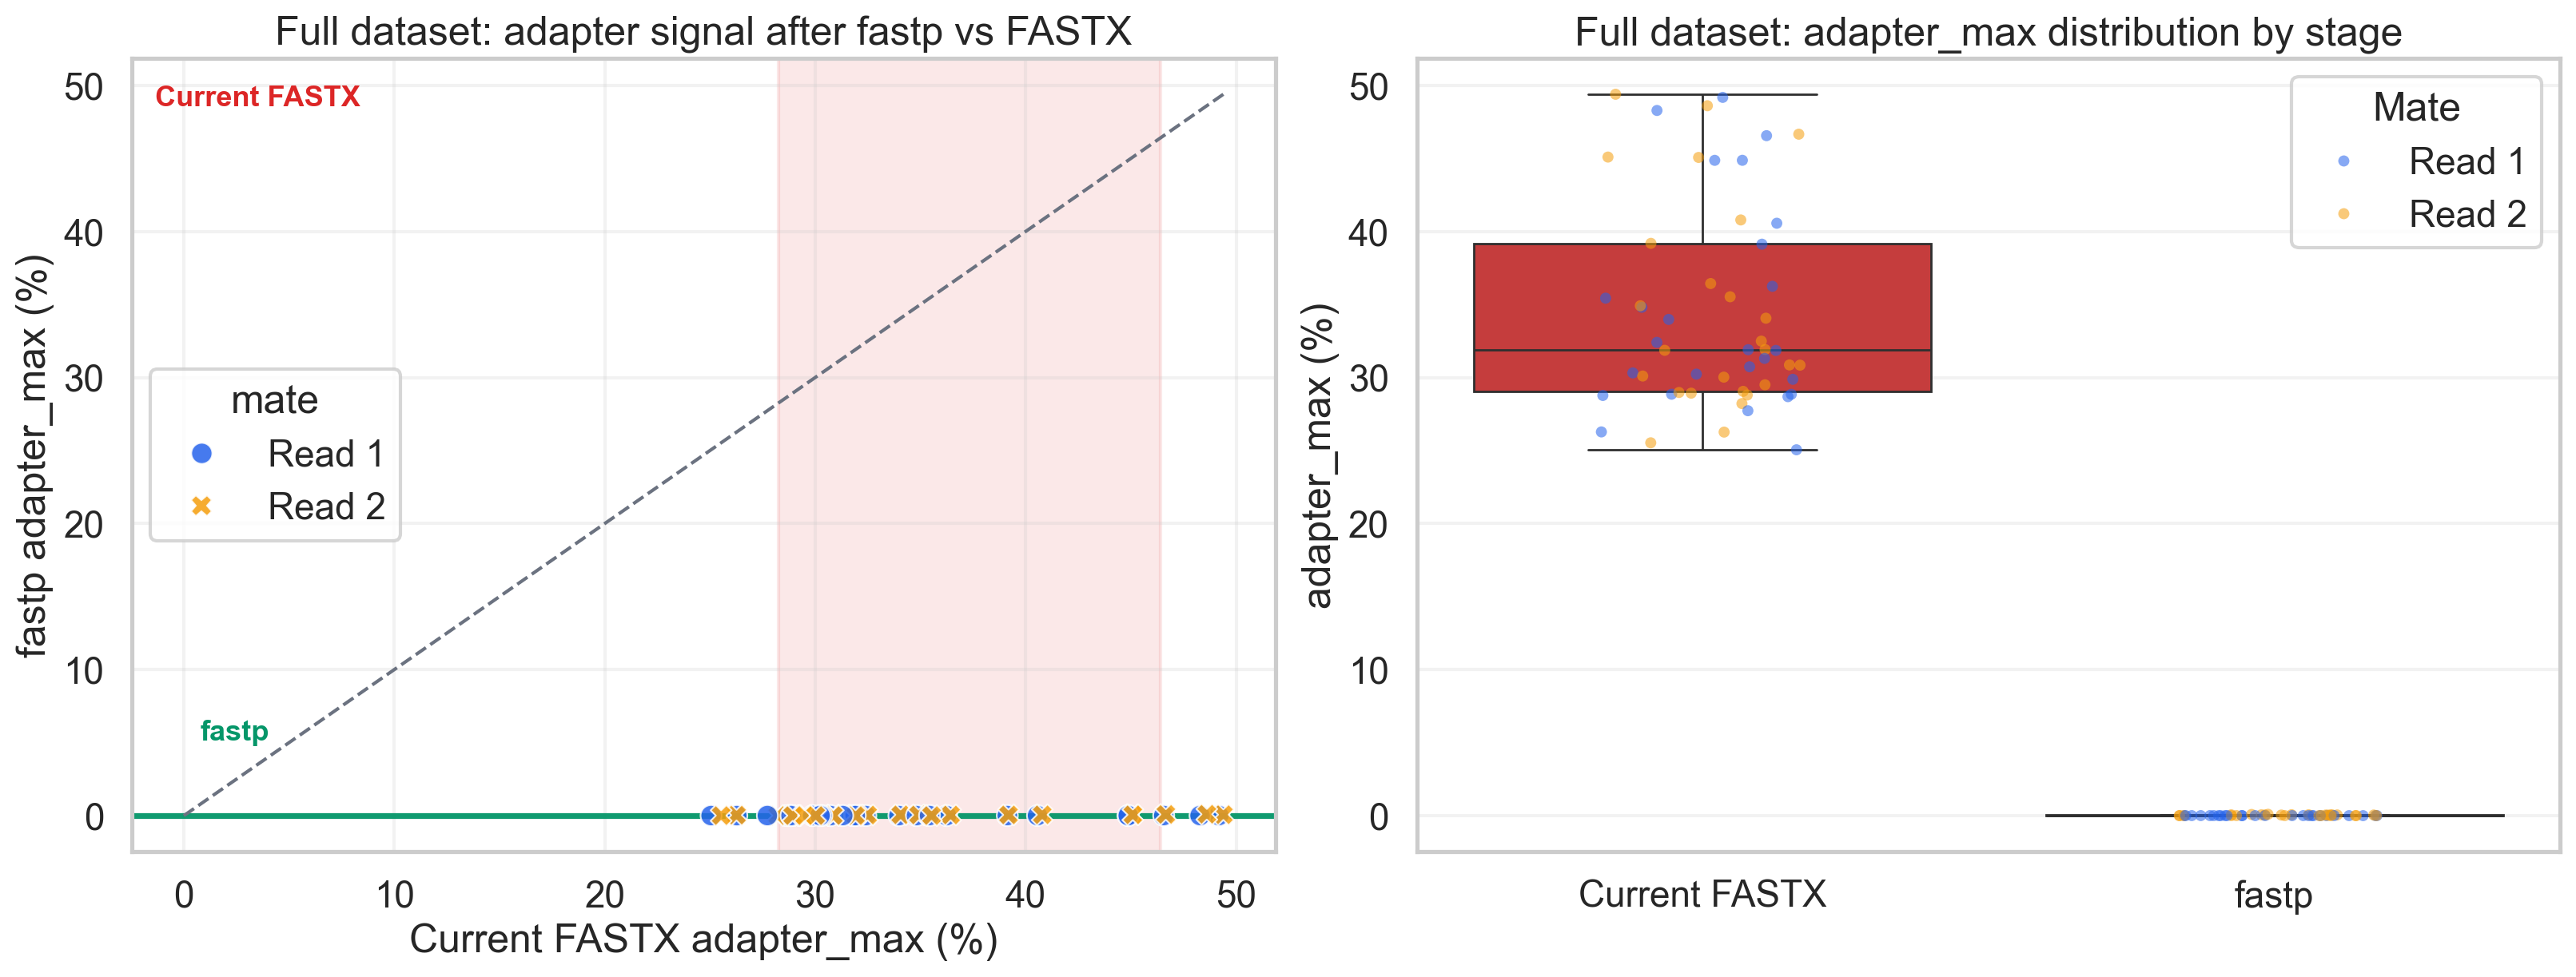

In [25]:
full_adapter_plot_path = save_full_adapter_comparison_plot(
    FULL_COMPARE_DIR / "full_fastx_vs_fastp_adapter_comparison.png"
)
display(Image(filename=str(full_adapter_plot_path)))


### Why this full-dataset adapter plot exists

- The left panel compares every read report directly: each point is one read, with `FASTX` on the x-axis and `fastp` on the y-axis.
- Points below the diagonal mean `fastp` reduced the residual signal relative to the trimmed baseline.
- The right panel shows the full distribution of `adapter_max` values for the two stages.
- This is the full-dataset version of the pilot decision question: did `fastp` actually beat `Current FASTX` across the whole dataset?


In [26]:
adapter_improved_count = int((full_read_metrics["fastp_adapter_max"] < full_read_metrics["fastx_adapter_max"]).sum())
near_zero_count = int((full_read_metrics["fastp_adapter_max"] < 0.1).sum())
worst_remaining = full_read_metrics.sort_values("fastp_adapter_max", ascending=False).iloc[0]
p90_fastx = float(full_read_metrics["fastx_adapter_max"].quantile(0.9))
p90_fastp = float(full_read_metrics["fastp_adapter_max"].quantile(0.9))

lines = [
    "### What this full-dataset adapter plot says",
    f"- All `{adapter_improved_count}` of `{len(full_read_metrics)}` read reports sit below the diagonal, so `fastp` reduces the residual adapter signal in every read report relative to `Current FASTX`.",
    f"- The shift is not being driven by only a few extreme reads: the median `adapter_max` drops from `{full_read_metrics['fastx_adapter_max'].median():.4f}` under `FASTX` to `{full_read_metrics['fastp_adapter_max'].median():.4f}` after `fastp`.",
    f"- The upper tail collapses as well: the `90th` percentile falls from `{p90_fastx:.4f}` to `{p90_fastp:.4f}`.",
    f"- `{near_zero_count}` of `{len(full_read_metrics)}` read reports end below `0.1%` adapter content after `fastp`, which is why the right-hand distribution looks compressed near zero.",
    f"- The highest remaining post-fastp `adapter_max` is still only `{worst_remaining['fastp_adapter_max']:.4f}` in `{worst_remaining['read_id']}`, so even the worst remaining case is small compared with the old FASTX baseline.",
]
display_findings(lines)


### What this full-dataset adapter plot says
- All `52` of `52` read reports sit below the diagonal, so `fastp` reduces the residual adapter signal in every read report relative to `Current FASTX`.
- The shift is not being driven by only a few extreme reads: the median `adapter_max` drops from `31.8806` under `FASTX` to `0.0051` after `fastp`.
- The upper tail collapses as well: the `90th` percentile falls from `46.4089` to `0.0589`.
- `52` of `52` read reports end below `0.1%` adapter content after `fastp`, which is why the right-hand distribution looks compressed near zero.
- The highest remaining post-fastp `adapter_max` is still only `0.0950` in `SRR30333755_2`, so even the worst remaining case is small compared with the old FASTX baseline.

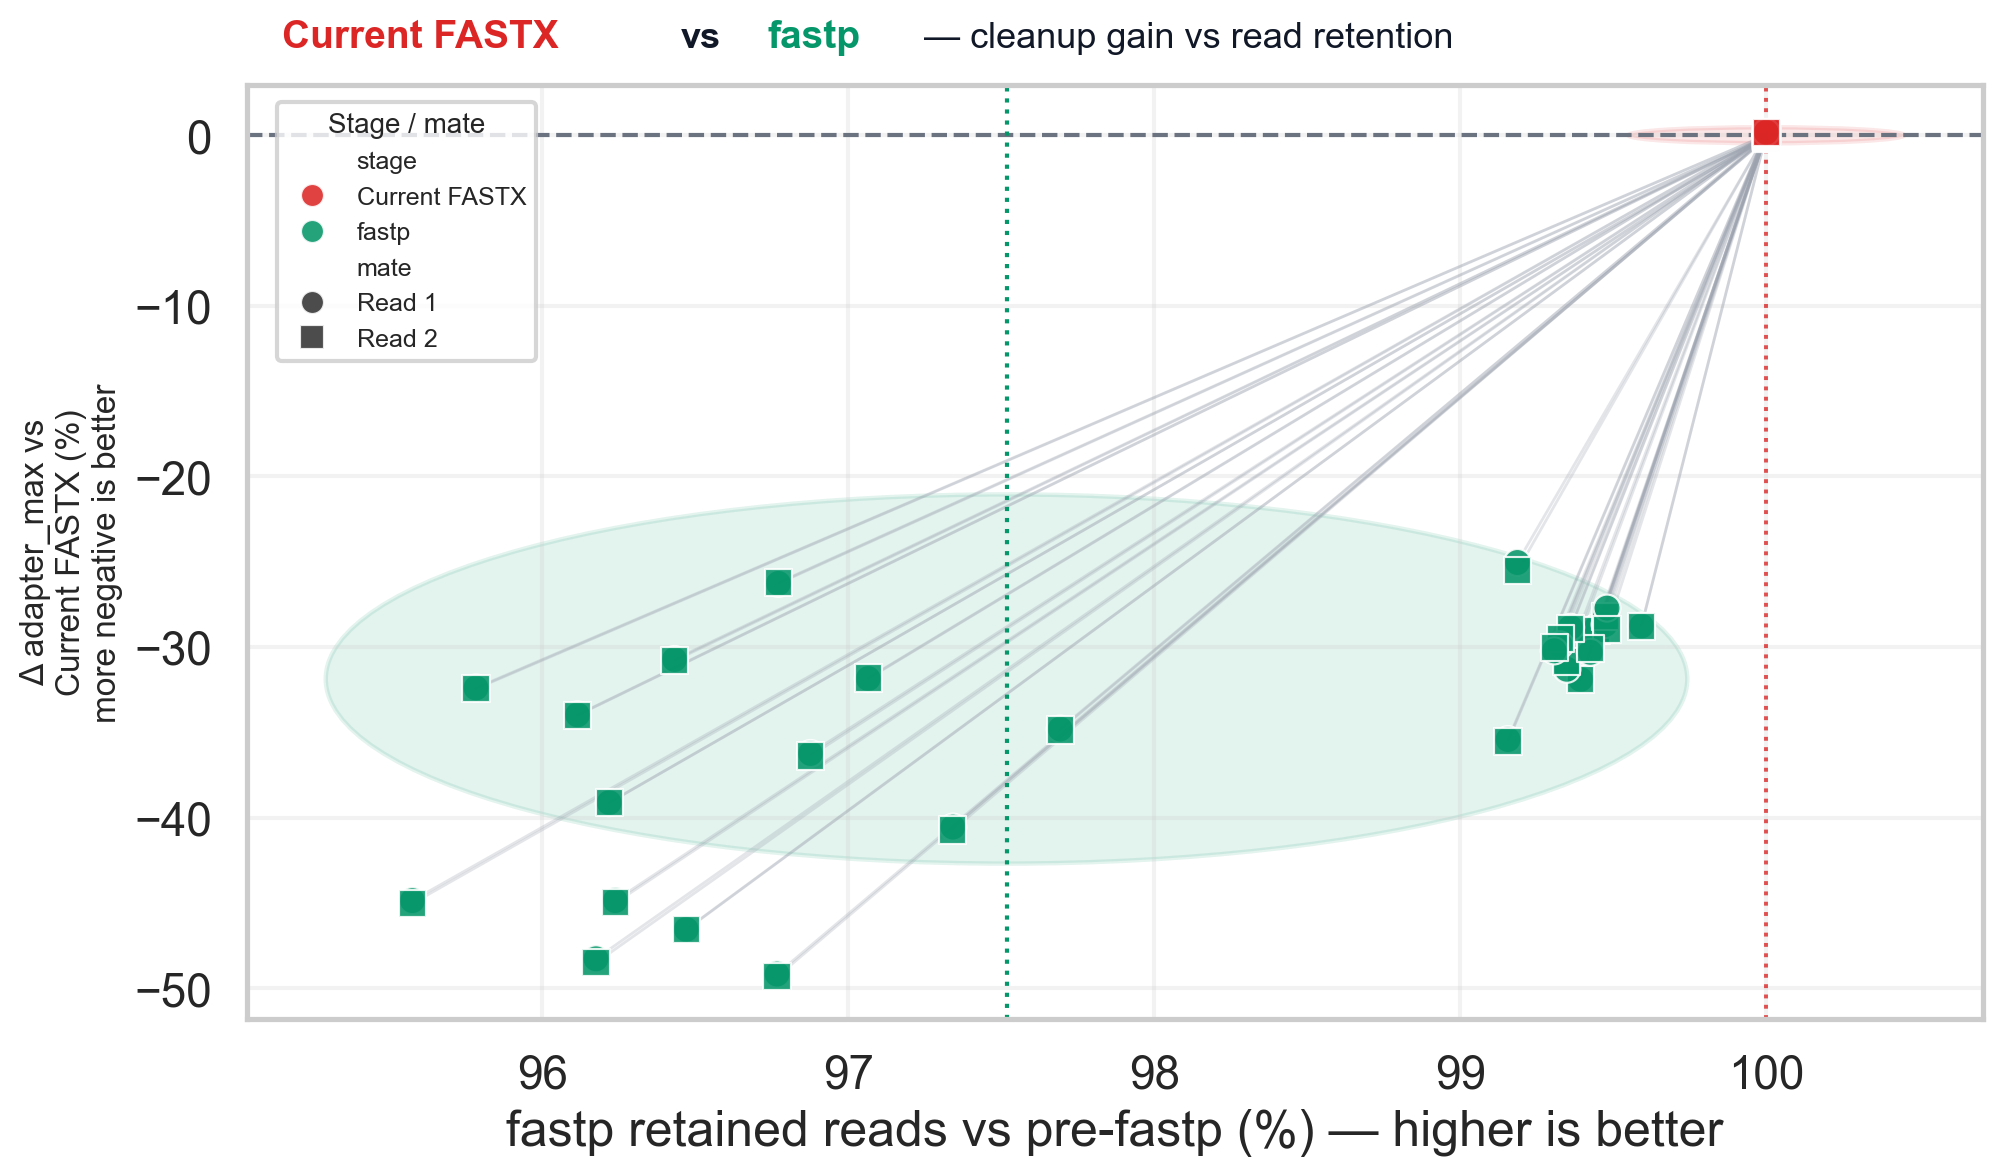

In [27]:
full_tradeoff_plot_path = save_full_retention_tradeoff_plot(
    FULL_COMPARE_DIR / "full_fastx_vs_fastp_retention_tradeoff.png"
)
display(Image(filename=str(full_tradeoff_plot_path)))


### Why this full-dataset tradeoff plot exists

- Every point shows one read report after the full `fastp` rerun.
- Farther right means more reads were kept.
- Farther down means the residual adapter signal dropped more strongly relative to `Current FASTX`.
- This is the full-dataset version of the cleanup-vs-retention plot above, so we can see whether the pilot tradeoff still holds at scale.


In [28]:
min_retained_row = full_fastp_run_metrics.sort_values("retained_pct").iloc[0]
max_retained_row = full_fastp_run_metrics.sort_values("retained_pct", ascending=False).iloc[0]
high_retention_count = int((full_fastp_run_metrics["retained_pct"] >= 96).sum())
strong_cleanup_count = int((full_read_metrics["adapter_max_delta_fastp_minus_fastx"] <= -10).sum())

lines = [
    "### What this full-dataset tradeoff plot says",
    f"- The points cluster in the lower-right part of the plot, which is exactly where we want them: strong cleanup with high retention.",
    f"- `{high_retention_count}` of `{len(full_fastp_run_metrics)}` SRRs retain at least `96%` of reads after `fastp`.",
    f"- The median retention is `{full_fastp_run_metrics['retained_pct'].median():.2f}%`, so the cleanup benefit is not coming from aggressive read loss.",
    f"- `{strong_cleanup_count}` of `{len(full_read_metrics)}` read reports improve by at least `10` adapter-content percentage points relative to `FASTX`, which shows that the cleanup gain is substantial, not marginal.",
    f"- The lowest-retention SRR is `{min_retained_row['srr']}` at `{min_retained_row['retained_pct']:.2f}%`, while the highest-retention SRR is `{max_retained_row['srr']}` at `{max_retained_row['retained_pct']:.2f}%`; both still remain in a usable range for alignment input.",
]
display_findings(lines)


### What this full-dataset tradeoff plot says
- The points cluster in the lower-right part of the plot, which is exactly where we want them: strong cleanup with high retention.
- `24` of `26` SRRs retain at least `96%` of reads after `fastp`.
- The median retention is `97.52%`, so the cleanup benefit is not coming from aggressive read loss.
- `52` of `52` read reports improve by at least `10` adapter-content percentage points relative to `FASTX`, which shows that the cleanup gain is substantial, not marginal.
- The lowest-retention SRR is `SRR30333754` at `95.58%`, while the highest-retention SRR is `SRR30333759` at `99.59%`; both still remain in a usable range for alignment input.

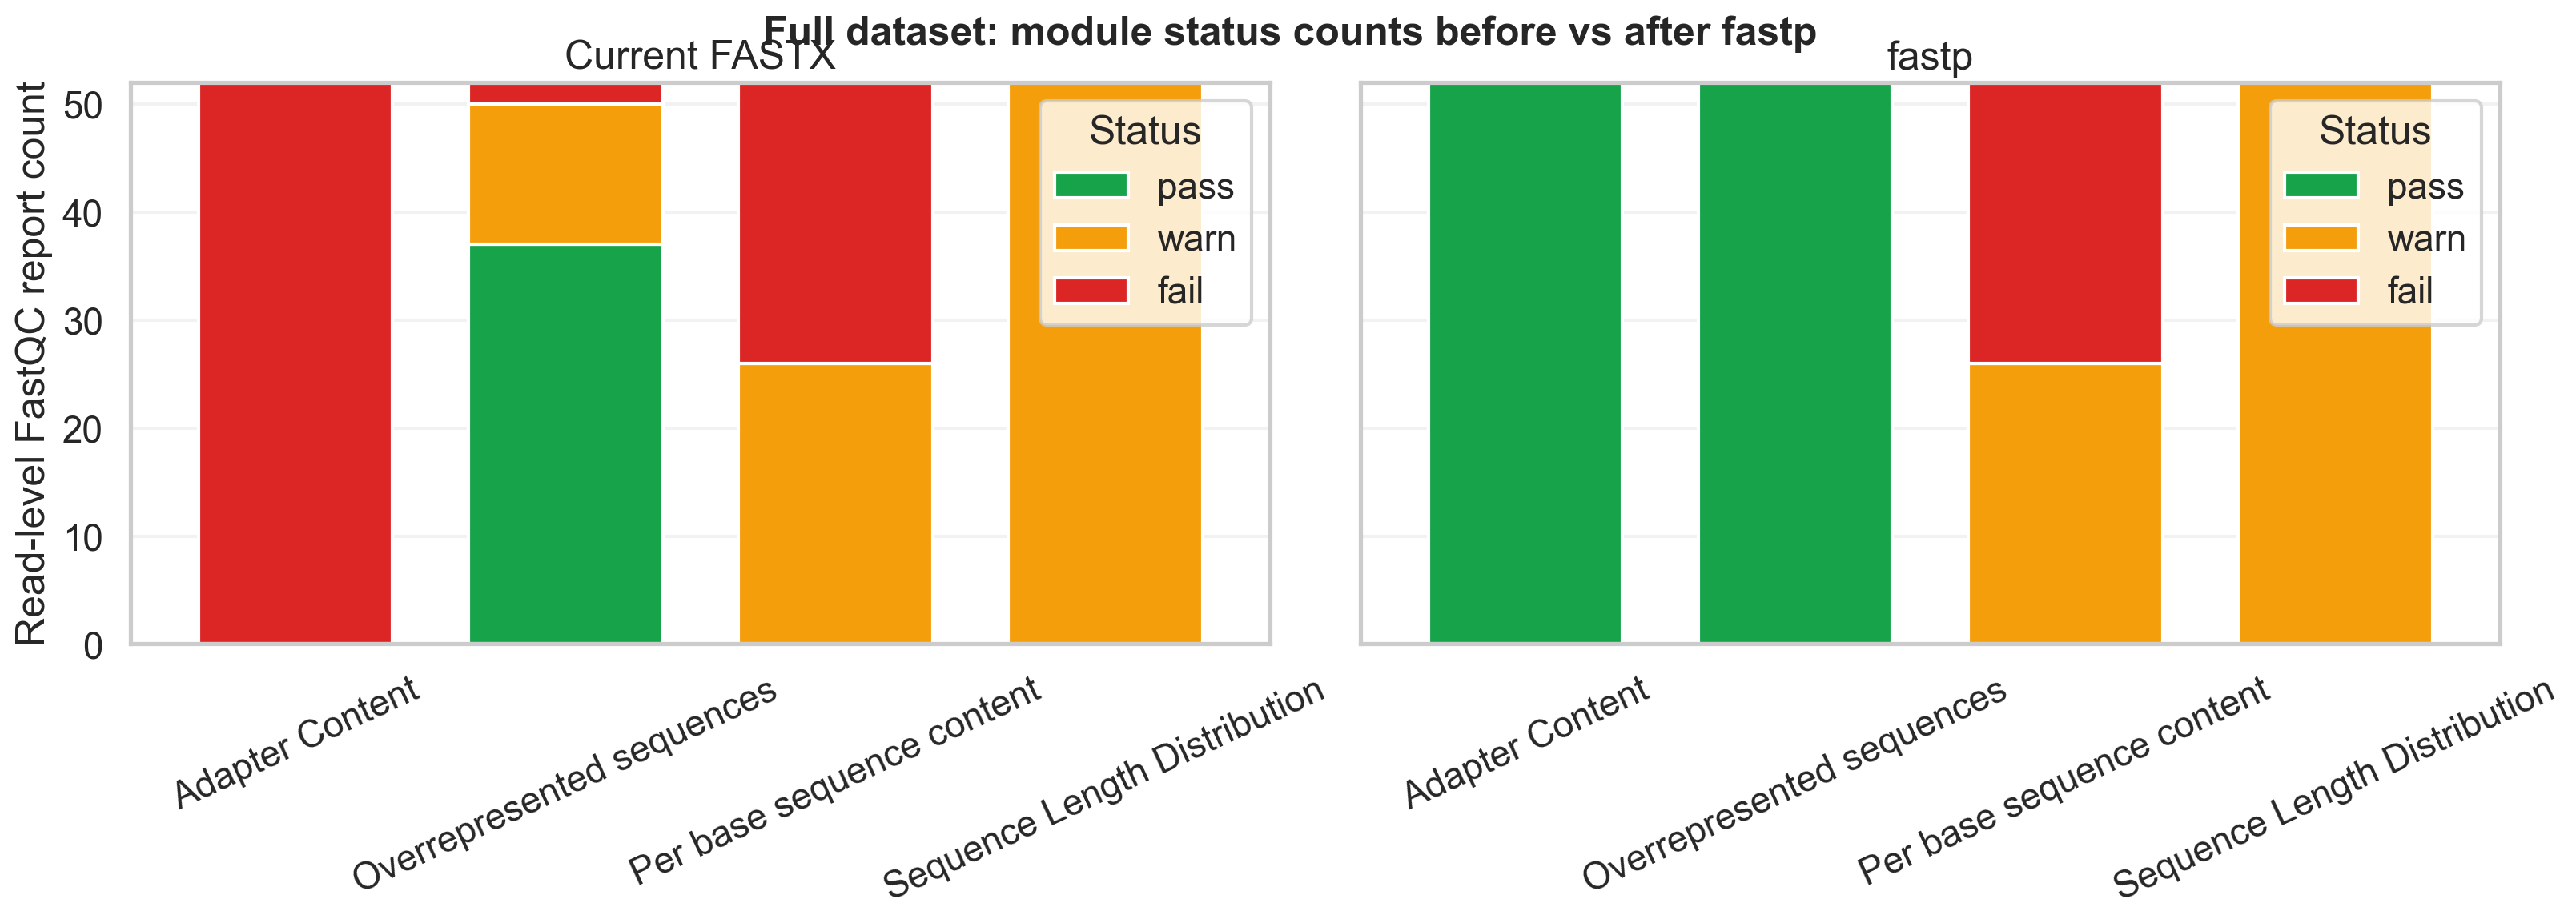

In [29]:
full_status_plot_path = save_full_status_counts_plot(
    FULL_COMPARE_DIR / "full_fastx_vs_fastp_status_counts.png"
)
display(Image(filename=str(full_status_plot_path)))


### Why this full-dataset status plot exists

- The pilot heatmap above is useful for the three focus reads.
- This bar figure is the dataset-wide version of that same idea: how many read reports are `PASS`, `WARN`, or `FAIL` before vs after the full `fastp` rerun.
- It makes the scale of the change visible immediately, especially for `Adapter Content` and `Overrepresented sequences`.


In [30]:
adapter_row = full_status_counts.loc[full_status_counts["module"] == "Adapter Content"].iloc[0]
overrep_row = full_status_counts.loc[full_status_counts["module"] == "Overrepresented sequences"].iloc[0]
pbsc_row = full_status_counts.loc[full_status_counts["module"] == "Per base sequence content"].iloc[0]
length_row = full_status_counts.loc[full_status_counts["module"] == "Sequence Length Distribution"].iloc[0]

lines = [
    "### What this full-dataset status plot says",
    f"- `Adapter Content` shows the clearest cleanup effect: `{adapter_row['fastx_fail']}` FAIL reports under `FASTX` become `{adapter_row['fastp_pass']}` PASS reports after `fastp`.",
    f"- `Overrepresented sequences` also clears completely: FASTX had `{overrep_row['fastx_pass']}` PASS / `{overrep_row['fastx_warn']}` WARN / `{overrep_row['fastx_fail']}` FAIL, while `fastp` ends with `{overrep_row['fastp_pass']}` PASS / `{overrep_row['fastp_warn']}` WARN / `{overrep_row['fastp_fail']}` FAIL.",
    f"- `Per base sequence content` does not change (`{pbsc_row['fastx_warn']}` WARN + `{pbsc_row['fastx_fail']}` FAIL before and after), which is expected because `fastp` was not meant to change biological composition patterns.",
    f"- `Sequence Length Distribution` also stays unchanged at `{length_row['fastx_warn']}` WARN reports before and `{length_row['fastp_warn']}` WARN reports after; variable read length is a normal trimming consequence, not a remediation failure.",
    "- This tells the full story of the cleanup: the targeted technical artifact modules improve dramatically, while the non-targeted RNA-seq modules remain stable.",
]
display_findings(lines)


### What this full-dataset status plot says
- `Adapter Content` shows the clearest cleanup effect: `52` FAIL reports under `FASTX` become `52` PASS reports after `fastp`.
- `Overrepresented sequences` also clears completely: FASTX had `37` PASS / `13` WARN / `2` FAIL, while `fastp` ends with `52` PASS / `0` WARN / `0` FAIL.
- `Per base sequence content` does not change (`26` WARN + `26` FAIL before and after), which is expected because `fastp` was not meant to change biological composition patterns.
- `Sequence Length Distribution` also stays unchanged at `52` WARN reports before and `52` WARN reports after; variable read length is a normal trimming consequence, not a remediation failure.
- This tells the full story of the cleanup: the targeted technical artifact modules improve dramatically, while the non-targeted RNA-seq modules remain stable.

In [31]:
display(
    full_status_counts.rename(
        columns={
            "module": "Module",
            "fastx_pass": "FASTX PASS",
            "fastx_warn": "FASTX WARN",
            "fastx_fail": "FASTX FAIL",
            "fastp_pass": "fastp PASS",
            "fastp_warn": "fastp WARN",
            "fastp_fail": "fastp FAIL",
            "improved": "Improved",
            "unchanged": "Unchanged",
            "worse": "Worse",
        }
    )
)


,Module,FASTX PASS,FASTX WARN,FASTX FAIL,fastp PASS,fastp WARN,fastp FAIL,Improved,Unchanged,Worse
0,Adapter Content,0,0,52,52,0,0,52,0,0
1,Overrepresented sequences,37,13,2,52,0,0,15,37,0
2,Per base sequence content,0,26,26,0,26,26,0,52,0
3,Sequence Length Distribution,0,52,0,0,52,0,0,52,0


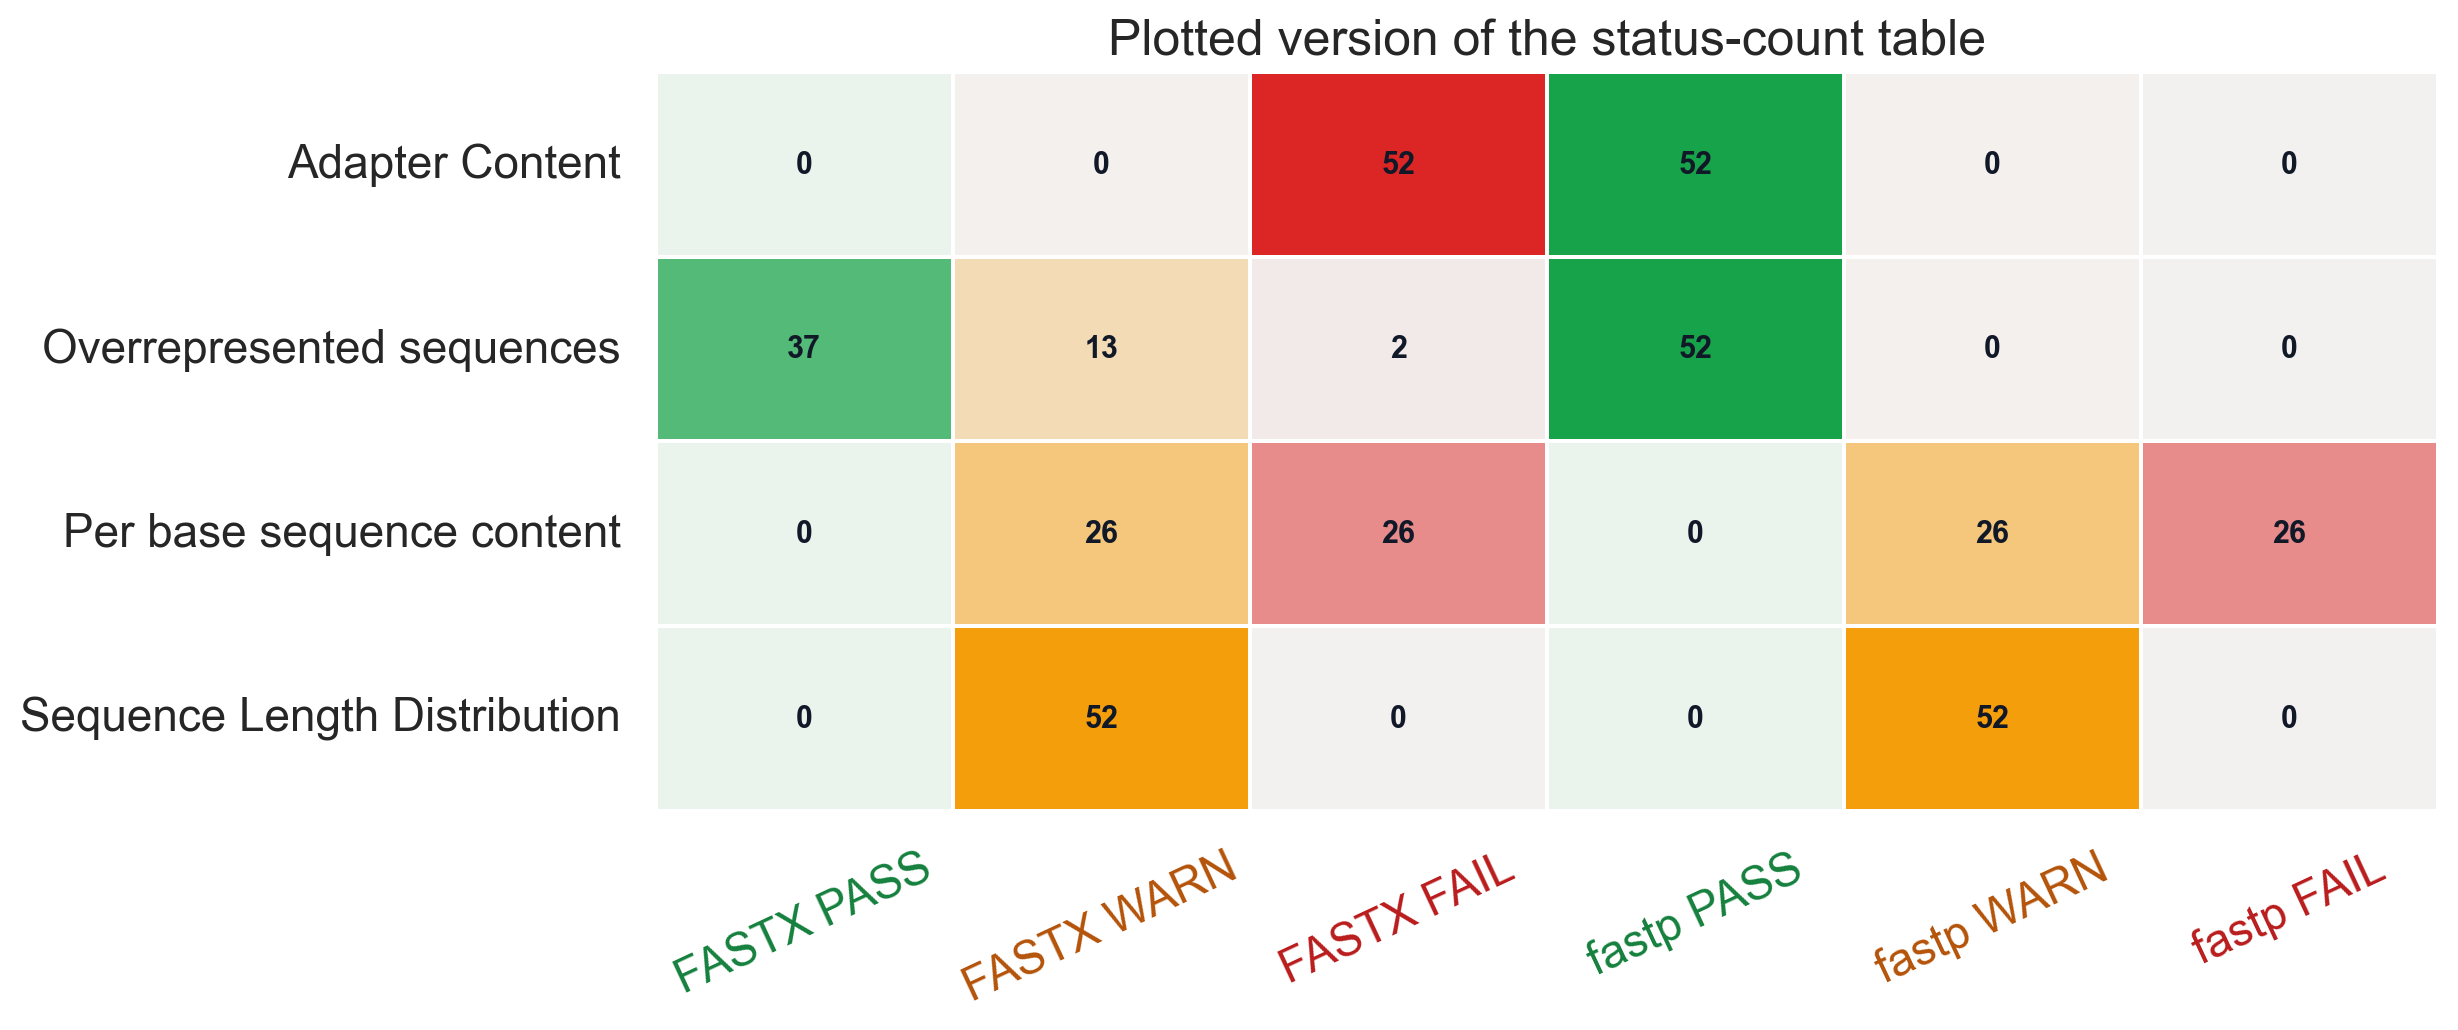

In [32]:
full_status_table_plot_path = save_full_status_table_heatmap(
    FULL_COMPARE_DIR / "full_fastx_vs_fastp_status_table_heatmap.png"
)
display(Image(filename=str(full_status_table_plot_path)))


### Why this plotted status table helps

- The table gives the exact counts.
- This heatmap gives the same numbers as a visual pattern.
- It makes the contrast between `FASTX FAIL` and `fastp PASS` columns easier to see immediately, especially for the two targeted remediation modules.


/var/folders/7y/f7_vwbw16slft31cvcc6xkk40000gn/T/ipykernel_71575/1435894605.py:617: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


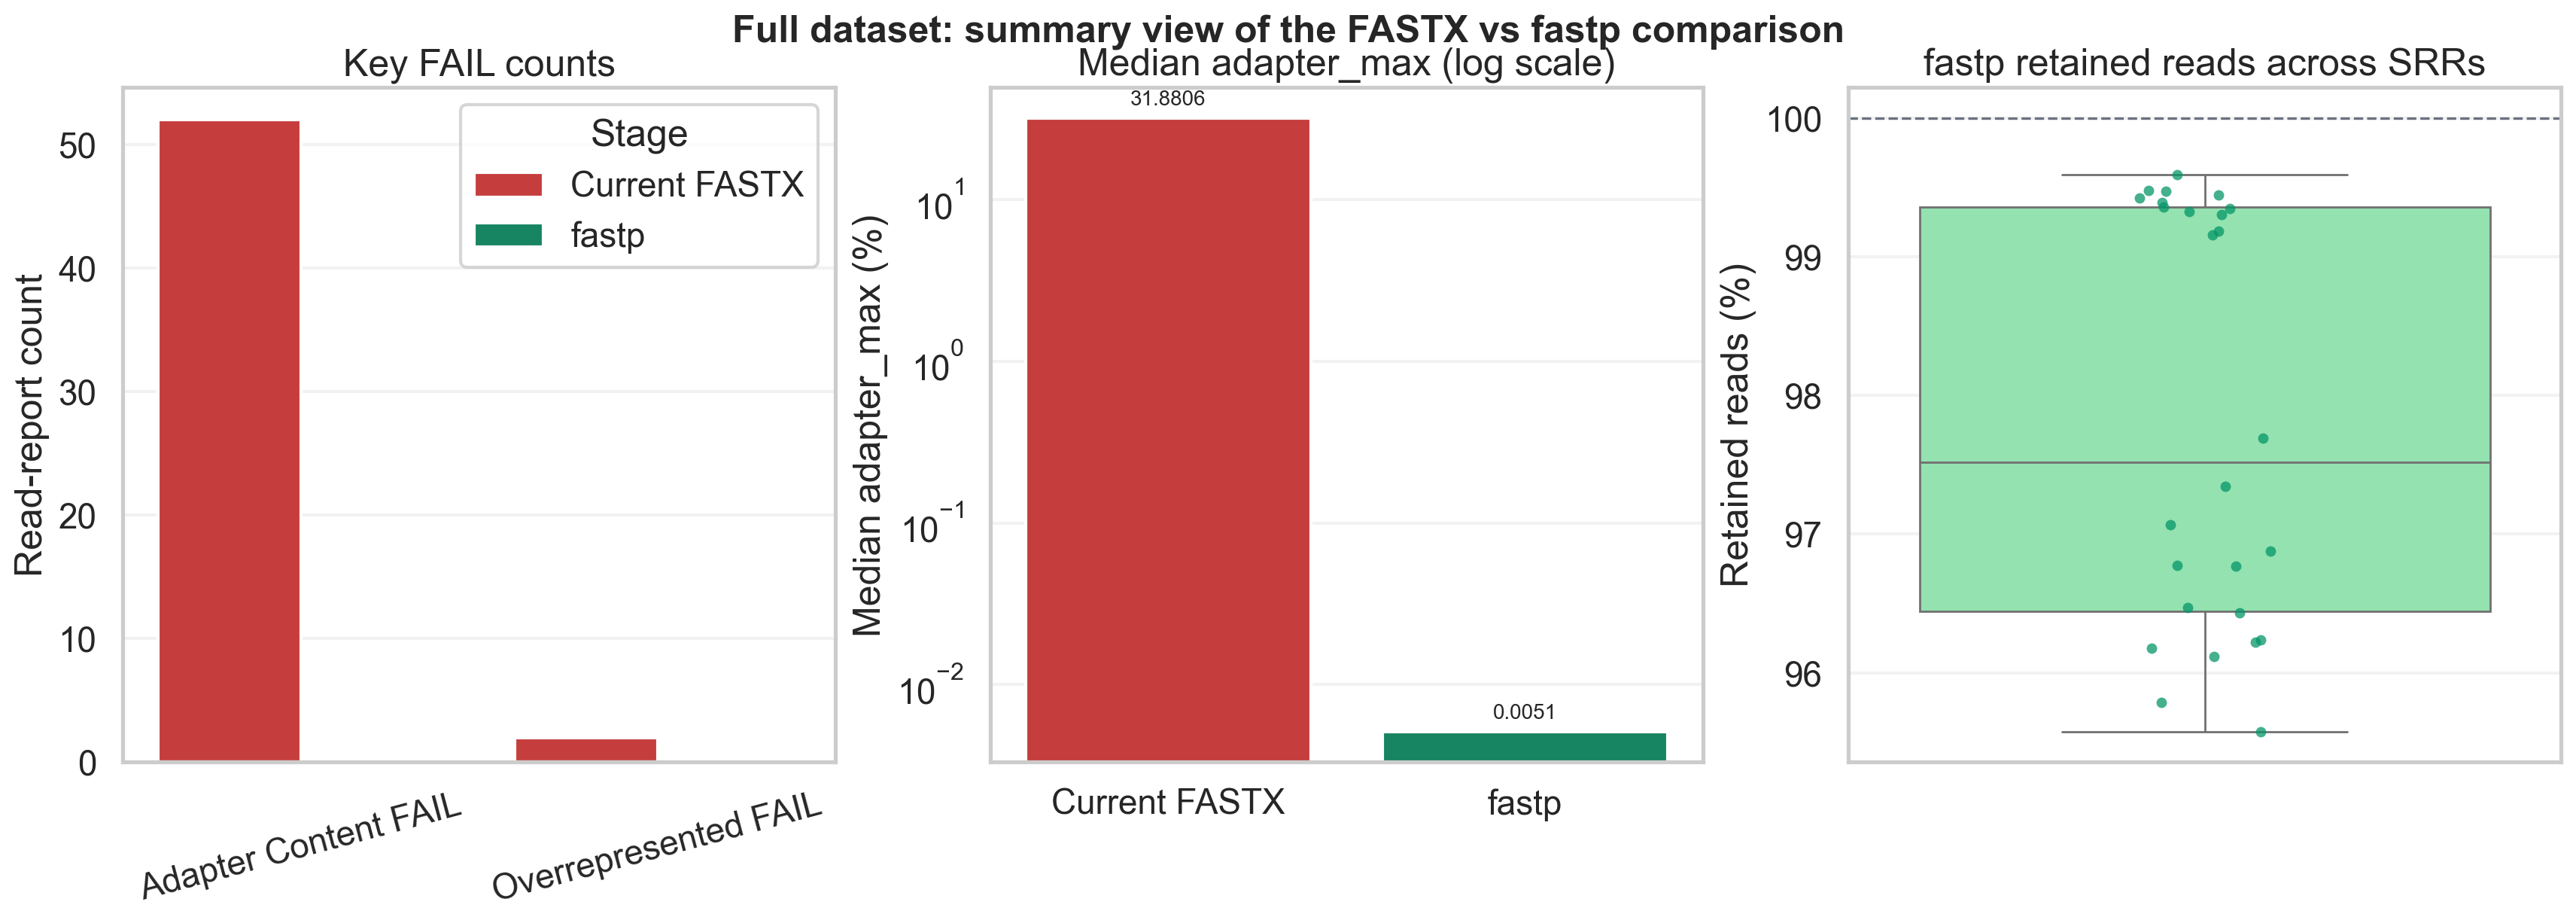

In [33]:
full_summary_plot_path = save_full_summary_dashboard_plot(
    FULL_COMPARE_DIR / "full_fastx_vs_fastp_summary_dashboard.png"
)
display(Image(filename=str(full_summary_plot_path)))


### Why this full-dataset summary plot exists

- The summary table below mixes counts, percentages, and medians.
- A single dashboard plot makes those three summary groups easier to read:
  1. key FAIL counts
  2. median adapter signal
  3. retained-read distribution across SRRs
- This is the quickest visual summary of what changed globally after the full `fastp` rerun.


In [34]:
lines = [
    "### What this full-dataset summary plot says",
    f"- The left panel shows the categorical cleanup result directly: `Adapter Content` FAIL counts fall from `{int(full_status_counts.loc[full_status_counts['module'] == 'Adapter Content', 'fastx_fail'].iloc[0])}` to `{int(full_status_counts.loc[full_status_counts['module'] == 'Adapter Content', 'fastp_fail'].iloc[0])}`, and `Overrepresented sequences` FAIL counts fall from `{int(full_status_counts.loc[full_status_counts['module'] == 'Overrepresented sequences', 'fastx_fail'].iloc[0])}` to `{int(full_status_counts.loc[full_status_counts['module'] == 'Overrepresented sequences', 'fastp_fail'].iloc[0])}`.",
    f"- The middle panel shows why this matters numerically: median `adapter_max` drops from `{full_read_metrics['fastx_adapter_max'].median():.4f}` under `FASTX` to `{full_read_metrics['fastp_adapter_max'].median():.4f}` after `fastp`.",
    f"- The right panel shows that this cleanup does not come from extreme data loss: the median retained-read percentage stays at `{full_fastp_run_metrics['retained_pct'].median():.2f}%`, with the SRRs remaining tightly clustered.",
    "- Put together, the dashboard says the same thing as the detailed plots above, but in a single glance: the technical artifact is largely removed and read retention remains high.",
]
display_findings(lines)


### What this full-dataset summary plot says
- The left panel shows the categorical cleanup result directly: `Adapter Content` FAIL counts fall from `52` to `0`, and `Overrepresented sequences` FAIL counts fall from `2` to `0`.
- The middle panel shows why this matters numerically: median `adapter_max` drops from `31.8806` under `FASTX` to `0.0051` after `fastp`.
- The right panel shows that this cleanup does not come from extreme data loss: the median retained-read percentage stays at `97.52%`, with the SRRs remaining tightly clustered.
- Put together, the dashboard says the same thing as the detailed plots above, but in a single glance: the technical artifact is largely removed and read retention remains high.

In [35]:
full_summary_table = pd.DataFrame(
    [
        {
            "Metric": "Reports compared",
            "Value": int(len(full_read_metrics)),
        },
        {
            "Metric": "FASTX Adapter Content FAIL",
            "Value": int(full_status_counts.loc[full_status_counts["module"] == "Adapter Content", "fastx_fail"].iloc[0]),
        },
        {
            "Metric": "fastp Adapter Content FAIL",
            "Value": int(full_status_counts.loc[full_status_counts["module"] == "Adapter Content", "fastp_fail"].iloc[0]),
        },
        {
            "Metric": "FASTX Overrepresented FAIL",
            "Value": int(full_status_counts.loc[full_status_counts["module"] == "Overrepresented sequences", "fastx_fail"].iloc[0]),
        },
        {
            "Metric": "fastp Overrepresented FAIL",
            "Value": int(full_status_counts.loc[full_status_counts["module"] == "Overrepresented sequences", "fastp_fail"].iloc[0]),
        },
        {
            "Metric": "Median FASTX adapter_max",
            "Value": round(float(full_read_metrics["fastx_adapter_max"].median()), 4),
        },
        {
            "Metric": "Median fastp adapter_max",
            "Value": round(float(full_read_metrics["fastp_adapter_max"].median()), 4),
        },
        {
            "Metric": "Median fastp retained %",
            "Value": round(float(full_fastp_run_metrics["retained_pct"].median()), 2),
        },
    ]
)

display(full_summary_table)


,Metric,Value
0,Reports compared,52.0000
1,FASTX Adapter Content FAIL,52.0000
2,fastp Adapter Content FAIL,0.0000
3,FASTX Overrepresented FAIL,2.0000
4,fastp Overrepresented FAIL,0.0000
5,Median FASTX adapter_max,31.8806
6,Median fastp adapter_max,0.0051
7,Median fastp retained %,97.5200


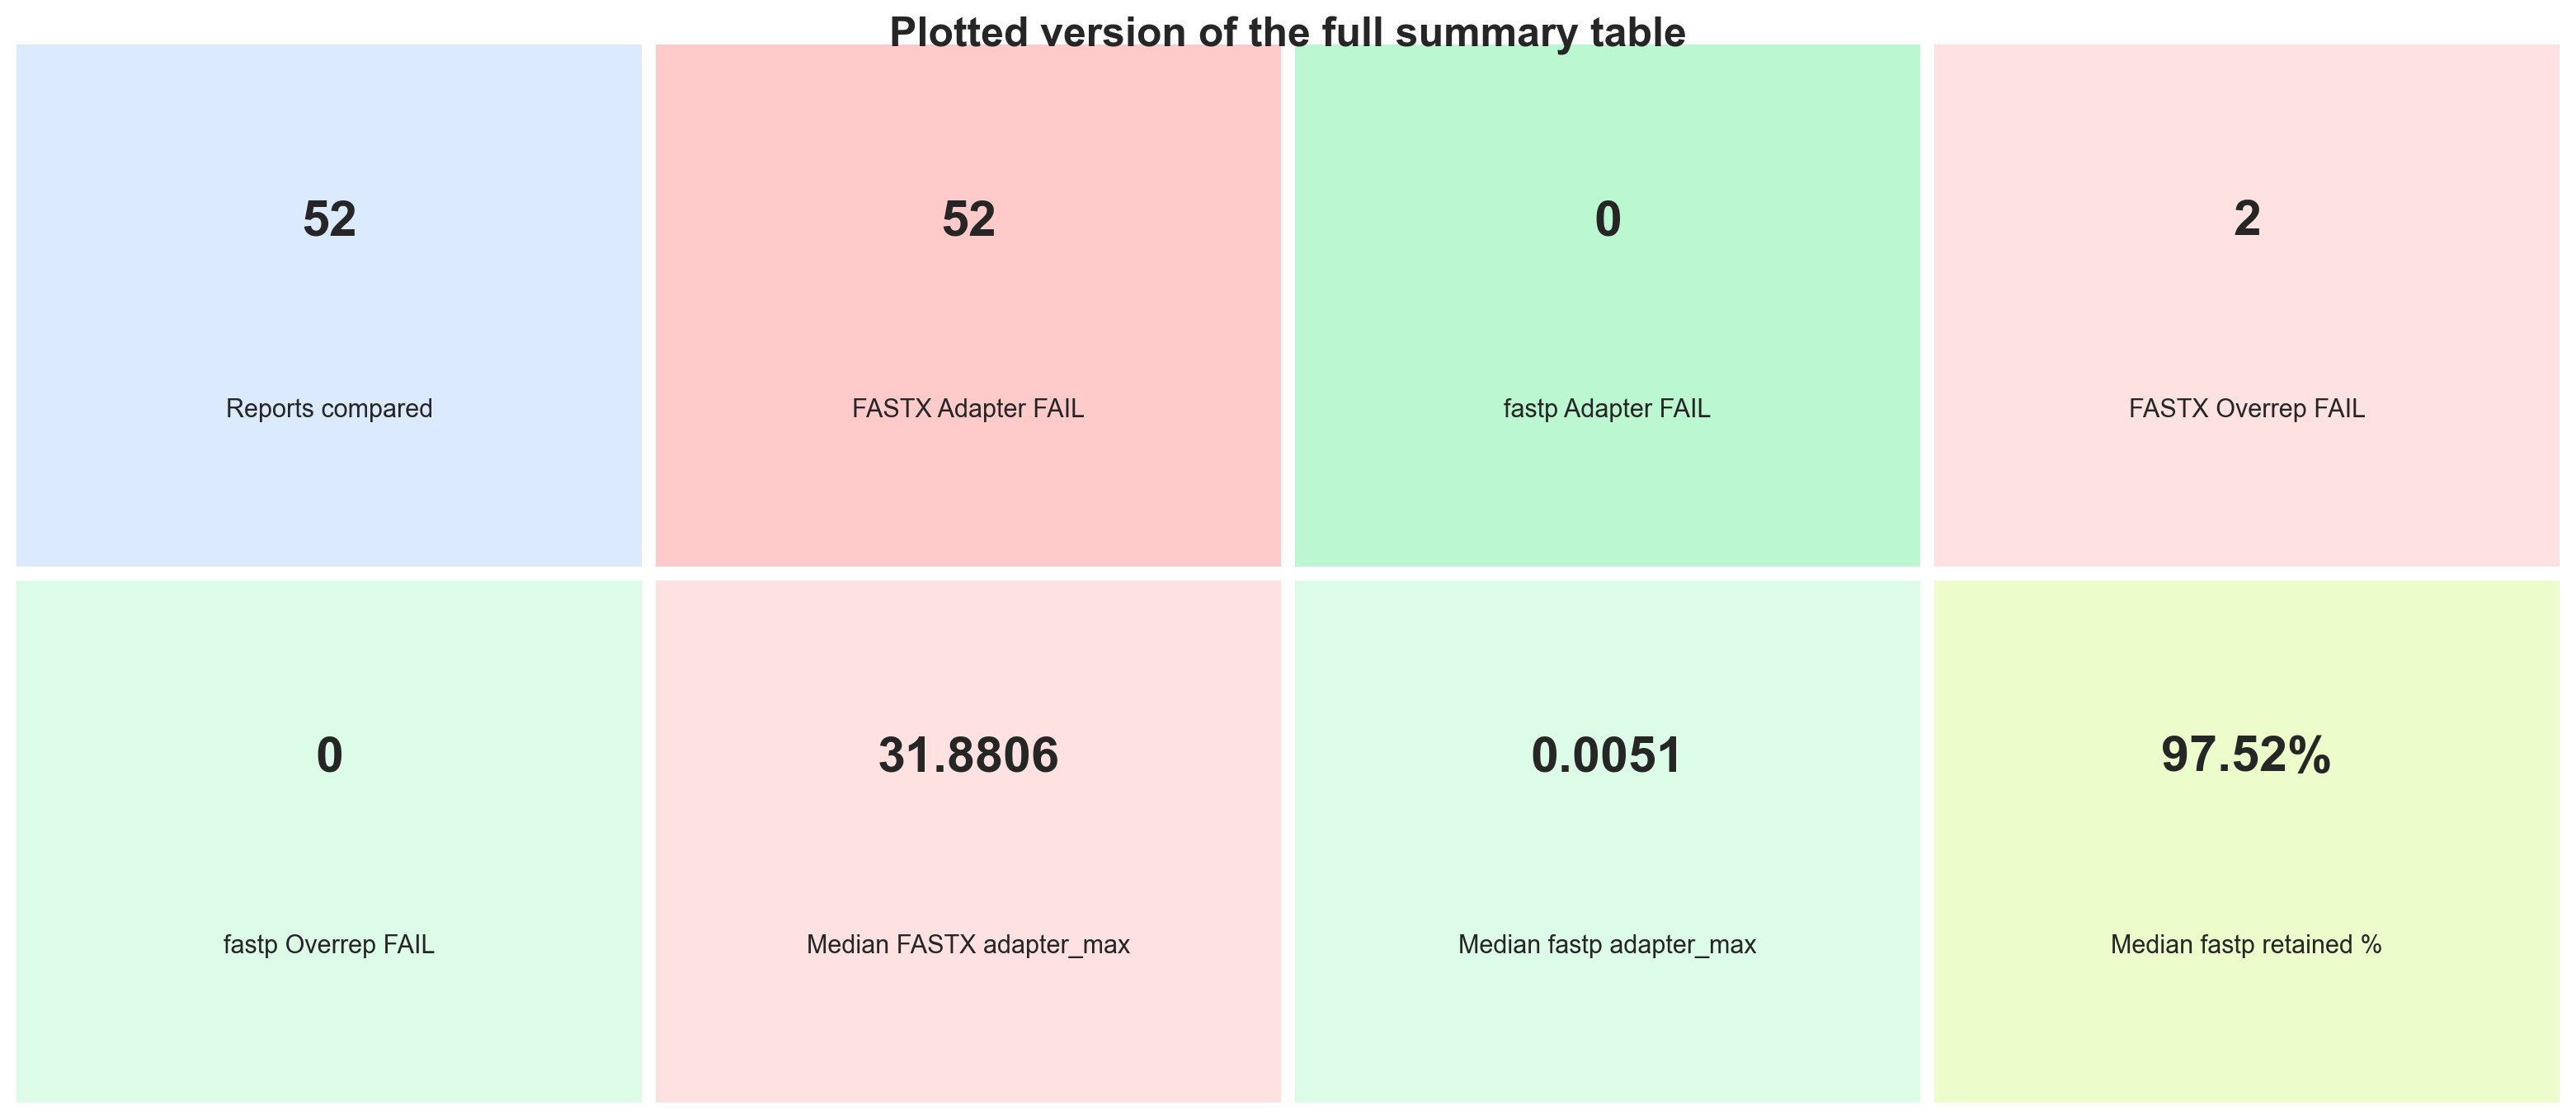

In [36]:
full_summary_cards_path = save_full_summary_cards_plot(
    FULL_COMPARE_DIR / "full_fastx_vs_fastp_summary_cards.png"
)
display(Image(filename=str(full_summary_cards_path)))


### Why this plotted summary table helps

- The summary table is the exact reference.
- These cards make the same metrics easier to scan quickly when presenting the QC story to other people.
- In practice, the cards make the headline numbers pop, while the table remains the exact record underneath.


### Why this full-dataset section exists

- The pilot made the tool choice.
- The full-dataset comparison confirms that the same pattern still holds across **all 52 read reports**.
- This is the notebook version of the report-ready validation layer:
  - `Adapter Content` goes from `52/52 FAIL` under the FASTX baseline to `52/52 PASS` after `fastp`
  - `Overrepresented sequences` also clears to `52/52 PASS`
  - read retention stays high after `fastp`
- So the notebook now contains both:
  - the pilot decision logic
  - the full-dataset confirmation that the chosen cleanup strategy scales beyond the pilot


In [37]:
lines = [
    "### Full-dataset interpretation",
    "- The pilot told us which tool to prefer; the full-dataset section tells us whether that choice still holds when every SRR is processed.",
    f"- It does: median `adapter_max` falls from `{full_read_metrics['fastx_adapter_max'].median():.4f}` to `{full_read_metrics['fastp_adapter_max'].median():.4f}`, while median retention stays at `{full_fastp_run_metrics['retained_pct'].median():.2f}%`.",
    "- The strongest changes occur exactly where we wanted them: `Adapter Content` and `Overrepresented sequences`.",
    "- The modules that stay unchanged are the ones we expected to stay unchanged, which means the cleanup is focused rather than disruptive.",
    "- This is why the full-dataset validation supports using `fastp` as the alignment input stage rather than keeping the older `FASTX`-trimmed baseline.",
]
display_findings(lines)


### Full-dataset interpretation
- The pilot told us which tool to prefer; the full-dataset section tells us whether that choice still holds when every SRR is processed.
- It does: median `adapter_max` falls from `31.8806` to `0.0051`, while median retention stays at `97.52%`.
- The strongest changes occur exactly where we wanted them: `Adapter Content` and `Overrepresented sequences`.
- The modules that stay unchanged are the ones we expected to stay unchanged, which means the cleanup is focused rather than disruptive.
- This is why the full-dataset validation supports using `fastp` as the alignment input stage rather than keeping the older `FASTX`-trimmed baseline.

In [38]:
status_table = stage_metrics[
    [
        "focus_read",
        "stage_label",
        "status_adapter_content",
        "status_overrepresented_sequences",
    ]
].copy()
status_table = status_table.rename(
    columns={
        "focus_read": "Focus read",
        "stage_label": "Stage",
        "status_adapter_content": "Adapter Content status",
        "status_overrepresented_sequences": "Overrepresented Sequences status",
    }
)

display(status_table.sort_values(["Focus read", "Stage"]))


,Focus read,Stage,Adapter Content status,Overrepresented Sequences status
0,SRR30333754_2,Raw,fail,fail
1,SRR30333754_2,Current FASTX,fail,fail
2,SRR30333754_2,fastp,pass,pass
3,SRR30333754_2,cutadapt,fail,pass
4,SRR30333756_2,Raw,fail,fail
5,SRR30333756_2,Current FASTX,fail,fail
6,SRR30333756_2,fastp,pass,pass
7,SRR30333756_2,cutadapt,fail,pass
8,SRR30333743_1,Raw,fail,warn
9,SRR30333743_1,Current FASTX,fail,warn


In [39]:
wins_fastp = int((wide["fastp_adapter_max"] < wide["cutadapt_adapter_max"]).sum())
wins_cutadapt = int((wide["cutadapt_adapter_max"] < wide["fastp_adapter_max"]).sum())

lines = [
    "### What Step 5 shows",
    f"- `fastp` wins `{wins_fastp}` of `{len(wide)}` focus reads on the main metric (`adapter_max`).",
    f"- `cutadapt` wins `{wins_cutadapt}` of `{len(wide)}` focus reads on the main metric (`adapter_max`).",
    "- `cutadapt` retains slightly more reads, but that advantage is small compared with the signal-removal gap.",
    "- The decision plots above answer the real question directly: how much each tool improves the trimmed baseline, what retention tradeoff it costs, and which FastQC statuses actually change.",
    "- The bell-plot gallery above is the dataset-level check: it shows that the trimmed baseline, `fastp`, and `cutadapt` all stay broadly similar in GC-shape, so the final choice should come from the remediation metrics rather than from tiny bell-shape differences alone.",
]

for row in wide.itertuples():
    lines.append(
        f"- `{row.focus_read}`: `FASTX` `{row.fastx_adapter_max:.4f}` → "
        f"`fastp` `{row.fastp_adapter_max:.4f}` vs `cutadapt` `{row.cutadapt_adapter_max:.4f}`."
    )

lines.extend(
    [
        "- Decision: `fastp` is the default cleanup tool for this mouse dataset.",
        "- `cutadapt` stays in the workflow as the targeted fallback when we need explicit sequence control.",
    ]
)

display_findings(lines)


### What Step 5 shows
- `fastp` wins `3` of `3` focus reads on the main metric (`adapter_max`).
- `cutadapt` wins `0` of `3` focus reads on the main metric (`adapter_max`).
- `cutadapt` retains slightly more reads, but that advantage is small compared with the signal-removal gap.
- The decision plots above answer the real question directly: how much each tool improves the trimmed baseline, what retention tradeoff it costs, and which FastQC statuses actually change.
- The bell-plot gallery above is the dataset-level check: it shows that the trimmed baseline, `fastp`, and `cutadapt` all stay broadly similar in GC-shape, so the final choice should come from the remediation metrics rather than from tiny bell-shape differences alone.
- `SRR30333754_2`: `FASTX` `45.0897` → `fastp` `0.0589` vs `cutadapt` `45.0601`.
- `SRR30333756_2`: `FASTX` `32.4893` → `fastp` `0.0434` vs `cutadapt` `31.8831`.
- `SRR30333743_1`: `FASTX` `49.1768` → `fastp` `0.0054` vs `cutadapt` `0.0338`.
- Decision: `fastp` is the default cleanup tool for this mouse dataset.
- `cutadapt` stays in the workflow as the targeted fallback when we need explicit sequence control.

## Step 6. Alignment-prep discussion draft

The QC question is now settled.

What remains before alignment is mostly an **operational freeze / team-decision layer**.
So this section does not try to complete those items automatically. Instead, it creates
a notebook-ready discussion package we can bring to the team:

1. proposed cleaned-input root + naming convention
2. evidence for whether any SRR still needs targeted `cutadapt`
3. a draft alignment-input manifest preview
4. non-blocking QC findings we should not keep “fixing”


In [40]:
proposed_fastp_root = "/home/pzg8794/mouse_qc_remediation/output/fastp/out"
unique_srrs = sorted(full_read_metrics["srr"].unique())
adapter_row = full_status_counts.loc[full_status_counts["module"] == "Adapter Content"].iloc[0]
overrep_row = full_status_counts.loc[full_status_counts["module"] == "Overrepresented sequences"].iloc[0]

alignment_discussion = pd.DataFrame(
    [
        {
            "Discussion item": "Freeze cleaned FASTQ root",
            "Current evidence": "Full fastp rerun completed; 52 cleaned FASTQ files exist under the fastp output root.",
            "Notebook-backed proposal": f"Use {proposed_fastp_root} with SRR*_1.fastp.fastq.gz and SRR*_2.fastp.fastq.gz.",
            "Status": "Ready for team confirmation",
        },
        {
            "Discussion item": "Targeted cutadapt fallback",
            "Current evidence": f"Adapter Content is {int(adapter_row['fastp_pass'])}/{int(adapter_row['fastp_pass'] + adapter_row['fastp_warn'] + adapter_row['fastp_fail'])} PASS after fastp; Overrepresented sequences is {int(overrep_row['fastp_pass'])}/{int(overrep_row['fastp_pass'] + overrep_row['fastp_warn'] + overrep_row['fastp_fail'])} PASS after fastp.",
            "Notebook-backed proposal": "Do not run cutadapt on any SRR right now; keep it only as a contingency.",
            "Status": "Ready for team confirmation",
        },
        {
            "Discussion item": "Non-blocking QC findings",
            "Current evidence": "Some RNA-seq style modules remain unchanged even after cleanup.",
            "Notebook-backed proposal": "Treat Sequence Length Distribution and Per base sequence content as monitored, not blocking, unless a later alignment result says otherwise.",
            "Status": "Ready for team confirmation",
        },
        {
            "Discussion item": "Sample/design sheet preview",
            "Current evidence": "The SRR list and cleaned mate-path pattern are already known.",
            "Notebook-backed proposal": "Use the preview below as the team-fill template for condition/group/replicate fields.",
            "Status": "Prepared for team completion",
        },
    ]
)

display(alignment_discussion)


,Discussion item,Current evidence,Notebook-backed proposal,Status
0,Freeze cleaned FASTQ root,Full fastp rerun completed; 52 cleaned FASTQ f...,Use /home/pzg8794/mouse_qc_remediation/output/...,Ready for team confirmation
1,Targeted cutadapt fallback,Adapter Content is 52/52 PASS after fastp; Ove...,Do not run cutadapt on any SRR right now; keep...,Ready for team confirmation
2,Non-blocking QC findings,Some RNA-seq style modules remain unchanged ev...,Treat Sequence Length Distribution and Per bas...,Ready for team confirmation
3,Sample/design sheet preview,The SRR list and cleaned mate-path pattern are...,Use the preview below as the team-fill templat...,Prepared for team completion


### Why this discussion table exists

- These are the highest-value remaining items that are already supported by QC evidence.
- They are also the easiest items to bring to the team without pretending they are fully frozen.
- This keeps the notebook useful for both reporting and team coordination.


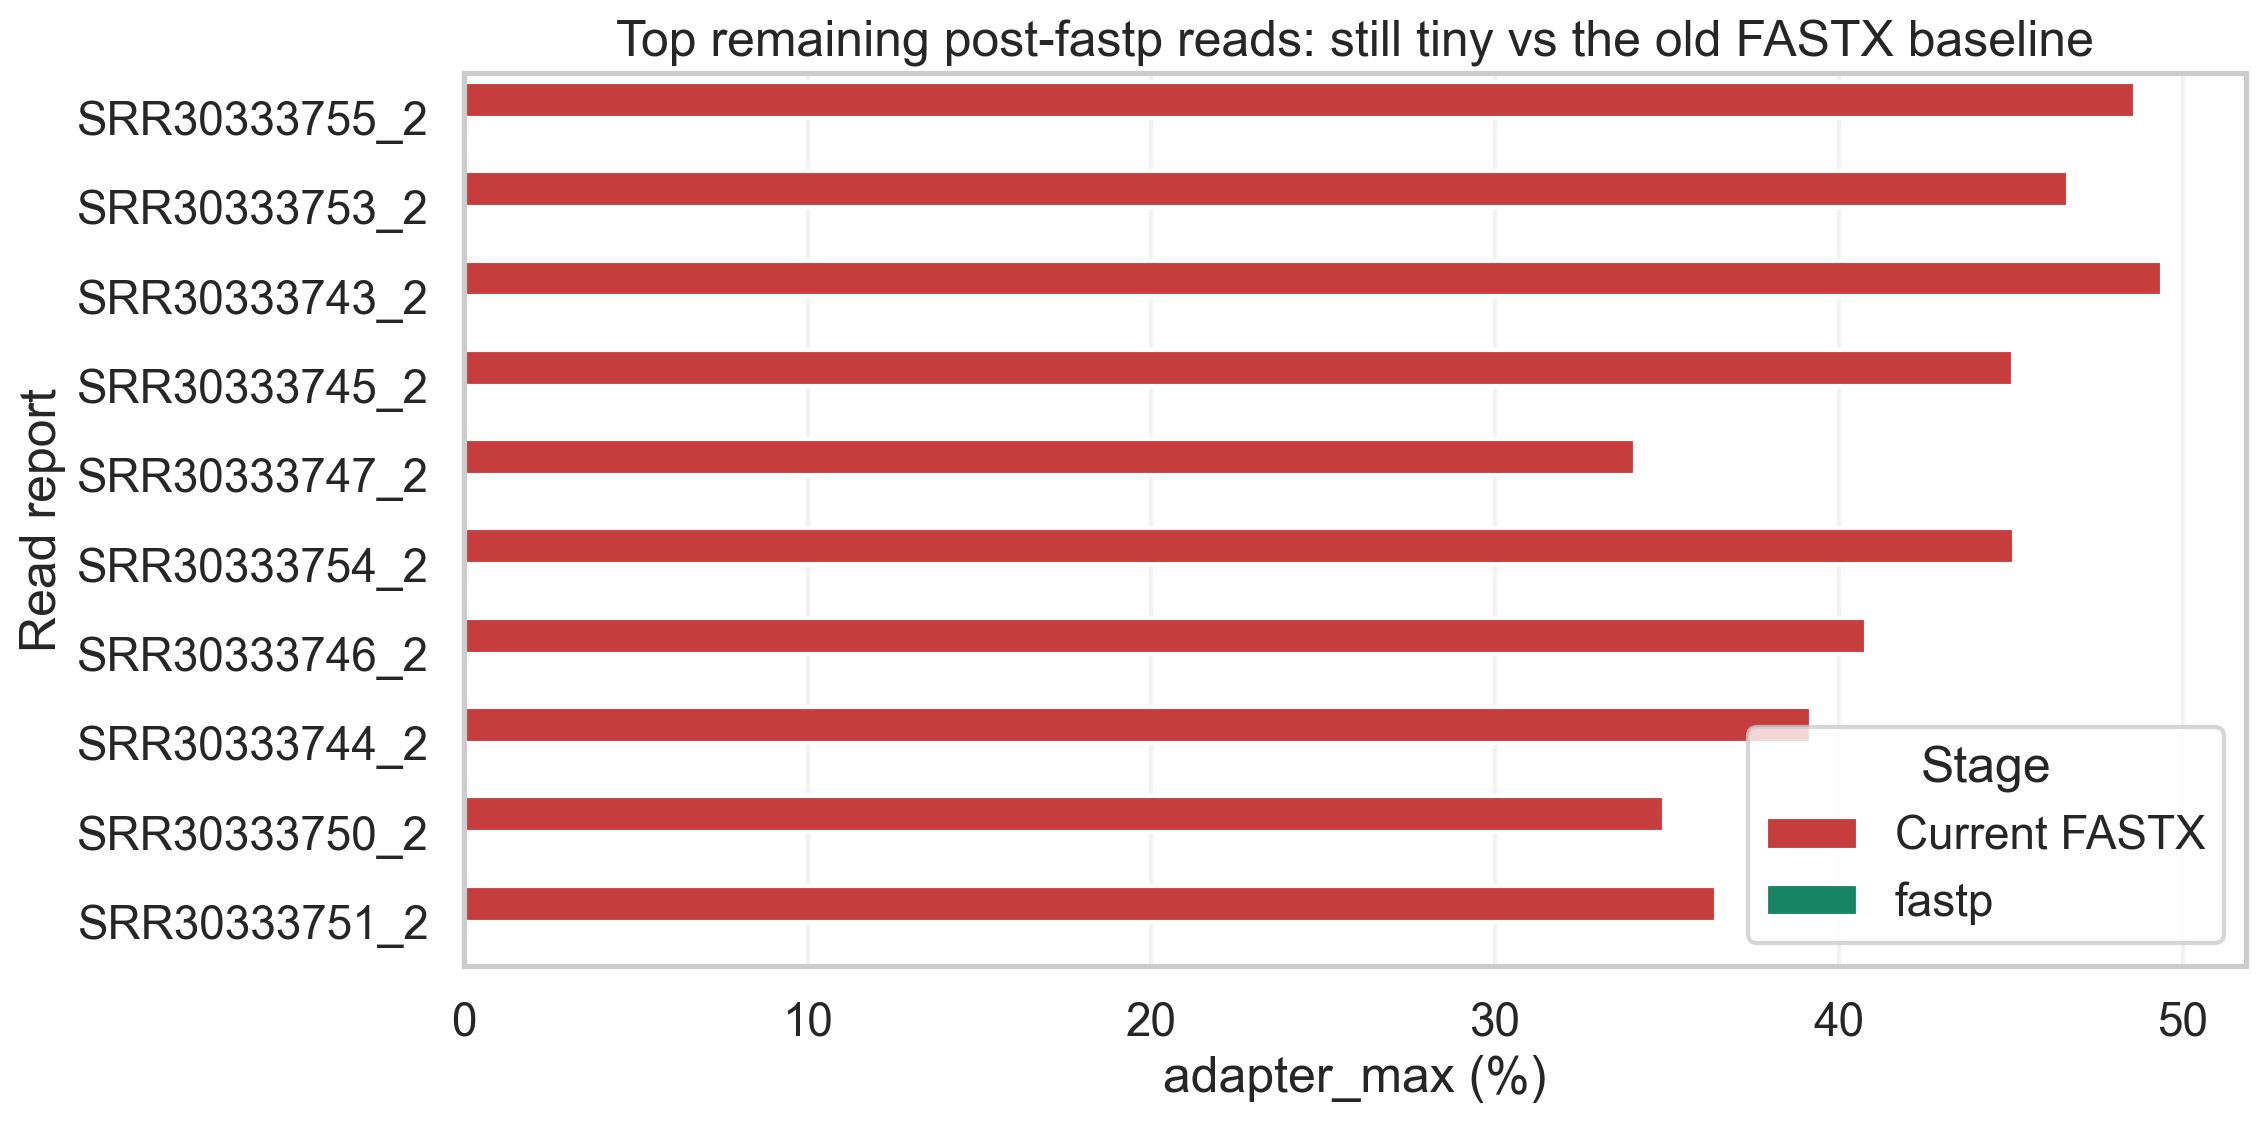

,read_id,srr,fastx_adapter_max,fastp_adapter_max,adapter_max_delta_fastp_minus_fastx
0,SRR30333755_2,SRR30333755,48.6043,0.0950,-48.5093
1,SRR30333753_2,SRR30333753,46.6565,0.0826,-46.5739
2,SRR30333743_2,SRR30333743,49.3904,0.0661,-49.3243
3,SRR30333745_2,SRR30333745,45.0649,0.0628,-45.0021
4,SRR30333747_2,SRR30333747,34.0593,0.0589,-34.0004
5,SRR30333754_2,SRR30333754,45.0897,0.0589,-45.0308
6,SRR30333746_2,SRR30333746,40.7851,0.0589,-40.7263
7,SRR30333744_2,SRR30333744,39.1827,0.0518,-39.1310
8,SRR30333750_2,SRR30333750,34.9107,0.0481,-34.8626
9,SRR30333751_2,SRR30333751,36.4320,0.0454,-36.3866


In [41]:
residual_review = (
    full_read_metrics[
        ["read_id", "srr", "fastx_adapter_max", "fastp_adapter_max", "adapter_max_delta_fastp_minus_fastx"]
    ]
    .sort_values("fastp_adapter_max", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

residual_plot_df = residual_review.melt(
    id_vars=["read_id"],
    value_vars=["fastx_adapter_max", "fastp_adapter_max"],
    var_name="stage",
    value_name="adapter_max",
)
residual_plot_df["stage"] = residual_plot_df["stage"].map(
    {"fastx_adapter_max": "Current FASTX", "fastp_adapter_max": "fastp"}
)

residual_plot_path = FULL_COMPARE_DIR / "full_fastx_vs_fastp_top_residual_reads.png"
fig, ax = plt.subplots(figsize=(11.5, 5.8))
sns.barplot(
    data=residual_plot_df,
    x="adapter_max",
    y="read_id",
    hue="stage",
    palette={"Current FASTX": "#dc2626", "fastp": "#059669"},
    ax=ax,
)
ax.set_title("Top remaining post-fastp reads: still tiny vs the old FASTX baseline")
ax.set_xlabel("adapter_max (%)")
ax.set_ylabel("Read report")
ax.legend(title="Stage", loc="lower right")
ax.grid(axis="x", alpha=0.25)
fig.savefig(residual_plot_path, dpi=200, bbox_inches="tight")
plt.close(fig)

display(Image(filename=str(residual_plot_path)))
display(residual_review.round(4))


### Why this residual-review plot exists

- This is the quickest notebook view for the `cutadapt` fallback question.
- It does **not** ask whether the worst reads are zero.
- It asks whether the worst remaining `fastp` reads are still large enough to justify a second targeted cleanup pass.
- If the green bars remain tiny relative to the old red baseline, then there is no strong current case for `cutadapt`.


In [42]:
residual_lines = [
    "### What this residual-review plot says",
    f"- These are the 10 highest remaining `fastp` read reports, so this is the hardest case for `fastp` after the full rerun.",
    f"- Even the worst remaining post-fastp read is only `{residual_review['fastp_adapter_max'].max():.4f}` adapter content.",
    f"- For the same reads, the old FASTX baseline sits much higher, with the matched values ranging from `{residual_review['fastx_adapter_max'].min():.4f}` to `{residual_review['fastx_adapter_max'].max():.4f}`.",
    "- Interpretation: the remaining residuals are small enough that `cutadapt` is not currently justified as a dataset-wide or SRR-specific second pass.",
    "- This is why the current team-share draft says to keep `cutadapt` as a contingency rather than an active next step.",
]
display_findings(residual_lines)


### What this residual-review plot says
- These are the 10 highest remaining `fastp` read reports, so this is the hardest case for `fastp` after the full rerun.
- Even the worst remaining post-fastp read is only `0.0950` adapter content.
- For the same reads, the old FASTX baseline sits much higher, with the matched values ranging from `34.0593` to `49.3904`.
- Interpretation: the remaining residuals are small enough that `cutadapt` is not currently justified as a dataset-wide or SRR-specific second pass.
- This is why the current team-share draft says to keep `cutadapt` as a contingency rather than an active next step.

In [43]:
alignment_manifest_preview = pd.DataFrame(
    {
        "SRR": unique_srrs,
        "Condition (team fill)": "TBD",
        "Group (team fill)": "TBD",
        "Replicate (team fill)": "TBD",
        "Mate 1 path": [f"{proposed_fastp_root}/{srr}_1.fastp.fastq.gz" for srr in unique_srrs],
        "Mate 2 path": [f"{proposed_fastp_root}/{srr}_2.fastp.fastq.gz" for srr in unique_srrs],
    }
)

display(alignment_manifest_preview)


,SRR,Condition (team fill),Group (team fill),Replicate (team fill),Mate 1 path,Mate 2 path
0,SRR30333743,TBD,TBD,TBD,/home/pzg8794/mouse_qc_remediation/output/fast...,/home/pzg8794/mouse_qc_remediation/output/fast...
1,SRR30333744,TBD,TBD,TBD,/home/pzg8794/mouse_qc_remediation/output/fast...,/home/pzg8794/mouse_qc_remediation/output/fast...
2,SRR30333745,TBD,TBD,TBD,/home/pzg8794/mouse_qc_remediation/output/fast...,/home/pzg8794/mouse_qc_remediation/output/fast...
3,SRR30333746,TBD,TBD,TBD,/home/pzg8794/mouse_qc_remediation/output/fast...,/home/pzg8794/mouse_qc_remediation/output/fast...
4,SRR30333747,TBD,TBD,TBD,/home/pzg8794/mouse_qc_remediation/output/fast...,/home/pzg8794/mouse_qc_remediation/output/fast...
5,SRR30333748,TBD,TBD,TBD,/home/pzg8794/mouse_qc_remediation/output/fast...,/home/pzg8794/mouse_qc_remediation/output/fast...
6,SRR30333749,TBD,TBD,TBD,/home/pzg8794/mouse_qc_remediation/output/fast...,/home/pzg8794/mouse_qc_remediation/output/fast...
7,SRR30333750,TBD,TBD,TBD,/home/pzg8794/mouse_qc_remediation/output/fast...,/home/pzg8794/mouse_qc_remediation/output/fast...
8,SRR30333751,TBD,TBD,TBD,/home/pzg8794/mouse_qc_remediation/output/fast...,/home/pzg8794/mouse_qc_remediation/output/fast...
9,SRR30333752,TBD,TBD,TBD,/home/pzg8794/mouse_qc_remediation/output/fast...,/home/pzg8794/mouse_qc_remediation/output/fast...


### Why this manifest preview exists

- We do not yet have the final condition/group/replicate mapping signed off by the team.
- But we **do** already know the canonical cleaned-input path pattern.
- So this preview lets us bring a nearly-ready alignment manifest to the discussion instead of starting from scratch.


In [44]:
def fmt_status(row, prefix):
    return f"{int(row[f'{prefix}_pass'])} PASS / {int(row[f'{prefix}_warn'])} WARN / {int(row[f'{prefix}_fail'])} FAIL"

pbsc_row = full_status_counts.loc[full_status_counts["module"] == "Per base sequence content"].iloc[0]
length_row = full_status_counts.loc[full_status_counts["module"] == "Sequence Length Distribution"].iloc[0]
non_blocking_qc = pd.DataFrame(
    [
        {
            "Module": "Per base sequence content",
            "FASTX status": fmt_status(pbsc_row, "fastx"),
            "fastp status": fmt_status(pbsc_row, "fastp"),
            "Treat as blocker?": "No",
            "Why": "This reflects composition patterns that trimming was not supposed to erase.",
        },
        {
            "Module": "Sequence Length Distribution",
            "FASTX status": fmt_status(length_row, "fastx"),
            "fastp status": fmt_status(length_row, "fastp"),
            "Treat as blocker?": "No",
            "Why": "Variable read length is expected after trimming and should be monitored, not treated as an automatic stop.",
        },
    ]
)

display(non_blocking_qc)


,Module,FASTX status,fastp status,Treat as blocker?,Why
0,Per base sequence content,0 PASS / 26 WARN / 26 FAIL,0 PASS / 26 WARN / 26 FAIL,No,This reflects composition patterns that trimmi...
1,Sequence Length Distribution,0 PASS / 52 WARN / 0 FAIL,0 PASS / 52 WARN / 0 FAIL,No,Variable read length is expected after trimmin...


### Why this non-blocking QC table exists

- It prevents us from wasting time trying to “fix” RNA-seq behaviors that are not actually blocking alignment.
- It also gives the team a concrete starting point for what to monitor later in STAR / mapping QC instead of trying to solve everything inside FastQC.


In [45]:
open_alignment_items = pd.DataFrame(
    [
        {
            "Still open": "Reference + annotation freeze",
            "Why still open": "This needs an explicit team decision about replication-vs-modern reference strategy.",
            "Notebook status": "Not completed here; better handled as a separate alignment-setup decision.",
        },
        {
            "Still open": "STAR manifest + QC template",
            "Why still open": "This depends on the final reference choice and the team-approved sample sheet.",
            "Notebook status": "Not completed here; the manifest preview above is the prerequisite.",
        },
    ]
)

display(open_alignment_items)


,Still open,Why still open,Notebook status
0,Reference + annotation freeze,This needs an explicit team decision about rep...,Not completed here; better handled as a separa...
1,STAR manifest + QC template,This depends on the final reference choice and...,Not completed here; the manifest preview above...


### What Step 6 gives us right now

- We can already bring the team an evidence-backed proposal for the cleaned-input root.
- We can already show why no SRR currently appears to need targeted `cutadapt`.
- We can already bring a nearly-ready alignment manifest skeleton.
- We can already separate non-blocking QC findings from real blockers.
- The remaining truly open items are the reference/annotation freeze and the STAR setup details that depend on it.


## Final decision

**Chosen default tool:** `fastp`

**Why:**
- It is the only tool in this pilot that consistently collapses the residual adapter/poly-G signal to near zero.
- It wins on the metric that matters most for this dataset: removing the dominant technical artifact.
- Its retention is slightly lower than `cutadapt`, but still high enough to keep the tradeoff favorable.

**Keep `cutadapt` for:**
- explicit adapter/primer-driven cleanup
- situations where sequence-level control matters more than batch default behavior

**What this means operationally:**
- the notebook now has the evidence needed to justify the tool choice
- the next deliverables are the updated weekly report and any scaled-up `fastp` remediation run
